Antes de rodar crie um ambiente virtal e ative.  
Instalar o Poetry  
Executar o comando poetry lock  
Executar o comando poetry install  

# Imports

In [1]:
import math
import warnings
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (import necessário para proj. 3-D)
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import phik
from unidecode import unidecode
from scipy.optimize import curve_fit, differential_evolution, minimize
from scipy.stats import zscore
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")



pds = pandas series  
df = DataFrame

In [2]:
warnings.filterwarnings("ignore", message="Covariance matrix calculated using the outer product")


# Preparando o Data Frame

In [3]:
abas  = pd.ExcelFile('WDI_EXCEL/WDIEXCEL.xlsx').sheet_names
abas

['Data', 'Country', 'Series', 'country-series', 'series-time', 'footnote']

In [4]:
metadata = pd.read_excel('WDI_EXCEL/WDIEXCEL.xlsx', sheet_name=abas[2])
metadata.head()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type
0,AG.CON.FERT.PT.ZS,Environment: Agricultural production,Fertilizer consumption (% of fertilizer produc...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
1,AG.CON.FERT.ZS,Environment: Agricultural production,Fertilizer consumption (kilograms per hectare ...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
2,AG.LND.AGRI.K2,Environment: Land use,Agricultural land (sq. km),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,Areas of former states are included in the suc...,Sum,The data are collected by the Food and Agricul...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agricultural land constitutes only a part of a...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
3,AG.LND.AGRI.ZS,Environment: Land use,Agricultural land (% of land area),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,Areas of former states are included in the suc...,Weighted average,The data are collected by the Food and Agricul...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agriculture is still a major sector in many ec...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
4,AG.LND.ARBL.HA,Environment: Land use,Arable land (hectares),NaN,Arable land (in hectares) includes land define...,NaN,Annual,NaN,NaN,NaN,The Food and Agriculture Organization (FAO) tr...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Temporary fallow land refers to land left fall...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0


In [5]:
metadata.columns = [col.strip().replace("_", " ") for col in metadata.columns]

In [6]:
metadata["Topic"].nunique()

88

In [7]:
lista_metadata = list(metadata["Topic"].unique())

In [8]:
metadata["Indicator Name"].nunique()

1496

In [9]:
dados = pd.read_excel('WDI_EXCEL/WDIEXCEL.xlsx', sheet_name=abas[0])
dados.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.488497,18.001597,18.558234,19.043572,19.586457,20.192064,20.828814,21.372164,22.100884,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.811504,7.096003,7.406706,7.666648,8.020952,8.403358,8.718306,9.097176,9.473374,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.152090,38.488233,38.779953,39.068462,39.445526,39.818645,40.276374,40.687817,41.211606,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,31.871956,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.672943,16.527554,24.627753,25.432092,27.061929,29.154282,31.022083,32.809138,33.760782,NaN


In [10]:
dados.columns = [col.strip().replace("_", " ") for col in dados.columns]

In [11]:
print(dados.columns)


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')


In [12]:
dados["Indicator Name"].nunique()

1496

In [13]:
dados_long = dados.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Value"
)

In [14]:
dados_long["Year"] = dados_long["Year"].astype(int)

In [15]:
dados_long.dtypes

Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
Year                int64
Value             float64
dtype: object

## Separando por paises e comaçando a olhar o data frame do Brasil

Separação feita desta maneira para uma posssivel extrapolação para demais paises futuramente

In [16]:
paises_unicos = dados_long["Country Name"].unique()

sub_dfs_por_pais = {
    pais: grupo.drop(columns=["Country Code", "Country Name"]).reset_index(drop=True)
    for pais, grupo in dados_long.groupby("Country Name")
}

brasil = sub_dfs_por_pais["Brazil"]
print("\nDados do Brasil:")
brasil.head()


Dados do Brasil:


,Indicator Name,Indicator Code,Year,Value
0,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1960,NaN
1,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1960,NaN
2,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1960,NaN
3,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
4,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1960,NaN


# Analise do Brasil

## Explorando e preparando o data frame para analise

In [17]:
# 1. Filtrar apenas as colunas importantes para a pivotagem
df_brasil = brasil[["Year", "Indicator Name", "Value"]].copy()

# 2. Pivotar para ficar no formato "wide" (uma coluna por indicador)
df_brasil_wide = df_brasil.pivot(
    index="Year",
    columns="Indicator Name",
    values="Value"
)

# 3. Ordenar pelas datas (anos) e exibir as primeiras linhas
df_brasil_wide.sort_index(inplace=True)
df_brasil_wide.head()

Indicator Name,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)",...,Women who believe a husband is justified in beating his wife (any of five reasons) (%),Women who believe a husband is justified in beating his wife when she argues with him (%),Women who believe a husband is justified in beating his wife when she burns the food (%),Women who believe a husband is justified in beating his wife when she goes out without telling him (%),Women who believe a husband is justified in beating his wife when she neglects the children (%),Women who believe a husband is justified in beating his wife when she refuses sex with him (%),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
pds_br_tps = df_brasil_wide.dtypes
for i ,formato in pds_br_tps.items():
    if formato != 'float64' and formato != 'int64':
        print(i, formato)

In [19]:
# Informações gerais sobre nulos e dimensões
linhas, colunas = df_brasil_wide.shape
total_celulas = linhas * colunas
total_nulos = df_brasil_wide.isnull().sum().sum()
porcentagem_nulos = (total_nulos / total_celulas) * 100

print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")
print(f"Total de valores nulos: {total_nulos}")


Linhas: 64
Colunas: 1496
Total de valores nulos: 49579


### Verificando quantidade de nulos por indicador

In [20]:
# Contar valores nulos por linha
pds_nulos_por_indicador = df_brasil_wide.isna().sum(axis=0)

# Exibir o resultado
print("Quantidade de valores nulos por linha (ano):")
print(pds_nulos_por_indicador.sort_values(ascending=False))

Quantidade de valores nulos por linha (ano):
Indicator Name
Young people (ages 15-24) newly infected with HIV                                                                                              64
Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)    64
Domestic credit provided by financial sector (% of GDP)                                                                                        64
Proportion of women subjected to physical and/or sexual violence in the last 12 months (% of ever-partnered women ages 15-49)                  64
Educational attainment, at least completed post-secondary, population 25+, female (%) (cumulative)                                             64
                                                                                                                                               ..
Imports of goods and services (current US$)                     

In [21]:
pds_nulos_por_indicador = pds_nulos_por_indicador.sort_values(ascending=False)
indicadroes_sem_dados = []
for indicador, valor in pds_nulos_por_indicador.items():
    if valor == 64:
        indicadroes_sem_dados.append(indicador)
print(len(indicadroes_sem_dados))

102


In [22]:
new_df_brasil_wide = df_brasil_wide.drop(columns=indicadroes_sem_dados)
new_df_brasil_wide.head()

Indicator Name,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)",...,"Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)",Wanted fertility rate (births per woman),"Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%)
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.768224e-13,NaN,NaN,NaN,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.446007e-13,NaN,NaN,NaN,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.748121e-13,NaN,NaN,NaN,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.508432e-13,NaN,NaN,NaN,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.247164e-12,NaN,NaN,NaN,NaN


In [23]:
# Substituir zeros por NaN (sem alterar o original ainda)
df_temp = new_df_brasil_wide.replace(0, np.nan)

# Contar valores nulos (incluindo os zeros que viraram NaN) por coluna
pds_nulos_por_indicador = df_temp.isna().sum(axis=0)

# Ordenar indicadores com mais "dados faltantes"
pds_nulos_por_indicador = pds_nulos_por_indicador.sort_values(ascending=False)

# Selecionar indicadores com >= 30% de valores faltantes
limite = new_df_brasil_wide.shape[0] * 0.3  # 30% do total de anos (ex: 64)
indicadores_remover = [
    indicador for indicador, nulos in pds_nulos_por_indicador.items()
    if nulos >= limite
]

print(f"{len(indicadores_remover)} indicadores com >= 30% de NaNs ou Zeros")


911 indicadores com >= 30% de NaNs ou Zeros


In [24]:
new_df_brasil_wide = new_df_brasil_wide.drop(columns=indicadores_remover)
new_df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,Travel services (% of commercial service exports),Travel services (% of commercial service imports),"Travel services (% of service exports, BoP)","Travel services (% of service imports, BoP)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,33399157.0,46.139,NaN,1.768224e-13,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,35155579.0,47.122,5.125267,2.446007e-13,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,36971452.0,48.099,5.036272,3.748121e-13,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,38852223.0,49.078,4.961925,6.508432e-13,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,40792376.0,50.059,4.872991,1.247164e-12,NaN


### Verificando quantidade de nulos por ano

In [25]:
# Contar valores nulos por linha
pds_nulos_por_ano = new_df_brasil_wide.isna().sum(axis=1)

# Exibir o resultado
print("Quantidade de valores nulos por linha (ano):")
print(pds_nulos_por_ano)

Quantidade de valores nulos por linha (ano):
Year
1960    257
1961    219
1962    205
1963    203
1964    202
       ... 
2019      6
2020      6
2021     31
2022     65
2023    133
Length: 64, dtype: int64


In [26]:
pds_nulos_por_ano = pds_nulos_por_ano.sort_values(ascending=False)
anos_remover = []
for indicador, valor in pds_nulos_por_ano.items():
    if valor >= (497*0.3):
        anos_remover.append(indicador)
print(len(anos_remover))

10


In [27]:
anos_remover.sort()
anos_remover

[1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969]

In [28]:
new_df_brasil_wide = new_df_brasil_wide.drop(labels=anos_remover, axis=0)
new_df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,Travel services (% of commercial service exports),Travel services (% of commercial service imports),"Travel services (% of service exports, BoP)","Travel services (% of service imports, BoP)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
Year,,,,,,,,,,,,,,,,,,,,,
1970,NaN,3.291109e+11,3.782767e+10,NaN,3450.680697,396.617704,9.121553,3.806293e+09,3.599282,1.501929e+09,...,NaN,NaN,NaN,NaN,NaN,53323573.0,55.909,4.221541,5.881536e-12,31.250
1971,11.844305,3.680918e+11,4.418975e+10,9.139582,3766.058479,452.118667,9.018367,4.390516e+09,3.599282,1.752280e+09,...,NaN,NaN,NaN,NaN,NaN,55607782.0,56.894,4.194465,7.057843e-12,31.250
1972,12.509426,4.141380e+11,5.269725e+10,9.804705,4135.309393,526.200059,9.028985,5.243614e+09,3.599282,2.090295e+09,...,NaN,NaN,NaN,NaN,3.06,57963965.0,57.879,4.149837,8.369877e-12,31.250
1973,14.291462,4.733244e+11,7.074687e+10,11.557651,4613.254011,689.534076,9.501022,7.446978e+09,3.000000,2.351424e+09,...,NaN,NaN,NaN,NaN,2.78,60385804.0,58.855,4.093252,9.772397e-12,31.250
1974,6.152843,5.024473e+11,9.352216e+10,3.638966,4781.128777,889.927177,9.749445,1.017117e+10,3.599282,3.754972e+09,...,NaN,NaN,NaN,NaN,NaN,62870949.0,59.826,4.033015,1.262268e-11,28.125


In [29]:
colunas_preservadas = new_df_brasil_wide[['Population growth (annual %)', 'Population, total']].copy()

In [30]:
new_df_brasil_wide = new_df_brasil_wide.drop(colunas_preservadas, axis=1)

In [31]:
new_df_brasil_wide.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 1970 to 2023
Columns: 481 entries, Adjusted net national income (annual % growth) to Women Business and the Law Index Score (scale 1-100)
dtypes: float64(481)
memory usage: 203.3 KB


In [32]:
new_df_brasil_wide.describe()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,Travel services (% of commercial service exports),Travel services (% of commercial service imports),"Travel services (% of service exports, BoP)","Travel services (% of service imports, BoP)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
count,51.000000,5.200000e+01,5.200000e+01,51.000000,52.000000,52.000000,52.000000,5.200000e+01,52.000000,5.200000e+01,...,49.000000,49.000000,49.000000,49.000000,45.000000,5.400000e+01,54.000000,54.000000,5.200000e+01,54.000000
mean,3.010929,9.162268e+11,6.681062e+11,1.425942,5590.578090,3682.081997,14.456639,1.461168e+11,4.417439,4.287812e+10,...,17.097469,19.294171,16.320850,18.161931,7.394556,1.256833e+08,75.951296,2.385401,5.155756e+01,57.060185
std,6.368678,3.304046e+11,5.915988e+11,6.130710,916.290481,2801.135806,3.945016,1.645337e+11,0.982101,4.571928e+10,...,9.433232,7.152482,9.000527,7.024541,3.469044,4.176731e+07,9.722235,1.177507,6.612087e+01,22.270061
min,-14.620223,3.291109e+11,3.782767e+10,-16.131683,3450.680697,396.617704,9.018367,3.806293e+09,2.800000,1.501929e+09,...,2.366505,6.648368,2.262181,5.898268,1.920000,5.332357e+07,55.909000,0.632380,5.881536e-12,28.125000
25%,-0.211241,6.445987e+11,1.925976e+11,-1.653632,4987.951719,1490.704292,11.792705,2.432008e+10,3.599282,7.718184e+09,...,7.535885,14.728987,7.253886,13.296869,4.040000,8.921814e+07,68.359000,1.201713,1.327366e-09,33.125000
50%,3.097826,9.307267e+11,4.434869e+11,1.276949,5542.382954,2537.679504,13.756643,7.698704e+10,4.264303,2.063184e+10,...,17.807276,19.942503,17.324395,18.475186,7.578000,1.301583e+08,78.675000,2.422724,2.191907e+01,50.625000
75%,5.882612,1.271165e+12,1.160585e+12,4.064897,6433.397369,5848.704142,15.720799,2.527057e+11,5.217500,8.456528e+10,...,23.862175,24.342780,22.045219,22.862175,10.150000,1.628768e+08,84.262250,3.513118,9.463679e+01,81.875000
max,22.522958,1.435186e+12,2.003637e+12,20.438679,7230.947942,10260.080844,23.062757,5.187513e+11,6.281311,1.399386e+11,...,39.869707,35.950176,39.080460,34.497130,13.697000,1.853562e+08,87.788000,4.221541,2.752110e+02,85.000000


### Verificando indicadores redundantes

In [33]:

# Preencher NaNs (por exemplo com interpolação linear)
df = new_df_brasil_wide.interpolate(method='linear', limit_direction='both')

# Padronizar os dados
df_zscore = df.apply(zscore)

# Função para calcular a correlação cruzada entre duas séries
def max_cross_corr(series1, series2, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    corrs = [series1.corr(series2.shift(lag)) for lag in lags]
    max_corr = max(corrs, key=abs)
    return max_corr

# Parâmetros
threshold = 0.9  # Correlação cruzada acima desse valor será considerada redundância
max_lag = 5      # Número máximo de anos de defasagem

# Detectar pares altamente correlacionados com defasagem
to_remove = set()
columns = df_zscore.columns.tolist()

for i, col1 in enumerate(columns):
    for col2 in columns[i+1:]:
        corr = max_cross_corr(df_zscore[col1], df_zscore[col2], max_lag=max_lag)
        if abs(corr) > threshold:
            to_remove.add(col2)

# Remover colunas redundantes
new_df_brasil_wide = df.drop(columns=to_remove)

print(f"\n{len(to_remove)} variáveis removidas por correlação cruzada.")


345 variáveis removidas por correlação cruzada.


###  Verificando df

In [34]:
new_df_brasil_wide = pd.concat([new_df_brasil_wide, colunas_preservadas], axis=1)

In [35]:
new_df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: energy depletion (% of GNI),Adjusted savings: gross savings (% of GNI),Adjusted savings: mineral depletion (% of GNI),Adjusted savings: net national savings (% of GNI),Adjusted savings: net national savings (current US$),"Adolescent fertility rate (births per 1,000 women ages 15-19)",Agricultural land (% of land area),...,Short-term debt (% of total external debt),Short-term debt (% of total reserves),Surface area (sq. km),Terms of trade adjustment (constant LCU),Total debt service (% of GNI),"Total debt service (% of exports of goods, services and primary income)",Travel services (% of commercial service exports),Travel services (% of commercial service imports),Population growth (annual %),"Population, total"
Year,,,,,,,,,,,,,,,,,,,,,
1970,11.844305,3.291109e+11,3.599282,0.047728,21.837114,0.178979,11.209303,1.367722e+10,75.066,22.771574,...,11.9318,60.006561,8515770.0,1.385222e+10,1.838590,43.829105,7.259714,17.629816,2.473172,95375651.0
1971,11.844305,3.680918e+11,3.599282,0.070111,21.837114,0.143288,11.209303,1.367722e+10,76.733,23.191045,...,11.9465,52.627887,8515770.0,1.067689e+10,1.805230,43.829105,7.259714,17.629816,2.448014,97739273.0
1972,12.509426,4.141380e+11,3.599282,0.066085,21.837114,0.165481,11.209303,1.367722e+10,79.207,23.610516,...,11.9275,33.541404,8515770.0,1.393160e+10,2.072381,43.829105,7.259714,17.629816,2.433363,100146797.0
1973,14.291462,4.733244e+11,3.000000,0.088562,21.837114,0.149967,11.209303,1.367722e+10,80.863,24.029988,...,11.9544,27.670790,8515770.0,2.787188e+10,2.453171,43.829105,7.259714,17.629816,2.421037,102600976.0
1974,6.152843,5.024473e+11,3.599282,0.388249,21.837114,0.217802,11.209303,1.367722e+10,81.322,24.449459,...,12.0278,49.458973,8515770.0,8.881354e+09,3.282392,43.829105,7.259714,17.629816,2.396659,105089675.0


In [36]:
# 1) Ver a lista completa
new_df_brasil_wide.columns          # retorna um Index

# 2) Transformar em lista Python
indicadores = new_df_brasil_wide.columns.tolist()
print(indicadores)

# 3) Mostrar uma por linha (útil quando são muitas)
for col in new_df_brasil_wide.columns:
    print(col)

# 4) Resumo rápido
new_df_brasil_wide.info()           # mostra nº de colunas e tipos


['Adjusted net national income (annual % growth)', 'Adjusted net national income (constant 2015 US$)', 'Adjusted savings: education expenditure (% of GNI)', 'Adjusted savings: energy depletion (% of GNI)', 'Adjusted savings: gross savings (% of GNI)', 'Adjusted savings: mineral depletion (% of GNI)', 'Adjusted savings: net national savings (% of GNI)', 'Adjusted savings: net national savings (current US$)', 'Adolescent fertility rate (births per 1,000 women ages 15-19)', 'Agricultural land (% of land area)', 'Agricultural raw materials exports (% of merchandise exports)', 'Agricultural raw materials imports (% of merchandise imports)', 'Agriculture, forestry, and fishing, value added (annual % growth)', 'Arable land (hectares per person)', 'Arms exports (SIPRI trend indicator values)', 'Arms imports (SIPRI trend indicator values)', 'Average precipitation in depth (mm per year)', 'Broad money (% of GDP)', 'Broad money growth (annual %)', 'Broad money to total reserves ratio', 'Capture f

In [37]:
new_df_brasil_wide.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 1970 to 2023
Columns: 138 entries, Adjusted net national income (annual % growth) to Population, total
dtypes: float64(138)
memory usage: 58.6 KB


In [38]:
# Informações gerais sobre nulos e dimensões
linhas, colunas = new_df_brasil_wide.shape
total_celulas = linhas * colunas
total_nulos = new_df_brasil_wide.isnull().sum().sum()
porcentagem_nulos = (total_nulos / total_celulas) * 100

print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")
print(f"Total de valores nulos: {total_nulos}")


Linhas: 54
Colunas: 138
Total de valores nulos: 0


# Análise Exploratória

## Agrupamento de topicos

### Topico com subtopico

In [39]:
# Filtra indicadores da metadata que estão no df_brasil_wide
metadata_filtered = metadata[metadata["Indicator Name"].isin(new_df_brasil_wide.columns)]

# Agrupa por tópico
agrupamentos_por_topico = (
    metadata_filtered.groupby("Topic")["Indicator Name"]
    .apply(list)
    .to_dict()
)


In [40]:
x = []
for topico in agrupamentos_por_topico.keys():
    z = []
    for item in agrupamentos_por_topico[topico]:
      z.append(item)
    x.append(len(z))
print(x)

[5, 3, 1, 2, 1, 8, 1, 11, 8, 8, 1, 3, 9, 2, 18, 1, 1, 2, 1, 1, 1, 6, 2, 4, 1, 3, 1, 2, 1, 9, 8, 3, 1]


In [41]:
# 3. Cria um dicionário de DataFrames por tópico
dfs_por_topico = {}

for topico, indicadores in agrupamentos_por_topico.items():
    # Garante que os indicadores existem no DataFrame
    indicadores_validos = [ind for ind in indicadores if ind in new_df_brasil_wide.columns]

    if indicadores_validos:
        df_topico = new_df_brasil_wide[indicadores_validos].copy()
        dfs_por_topico[topico] = df_topico


In [42]:
diagnostico_topico = []

for topico, df in dfs_por_topico.items():
    df_clean = df.dropna(axis=1, how='all').dropna()  # remove colunas completamente nulas e linhas com NA

    if df_clean.empty:
        continue

    # Padroniza os dados
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

    # Contagem total de outliers (z-score > 3)
    outliers_mask = df_scaled.abs() > 3
    n_outliers_total = outliers_mask.sum().sum()

    # Quantas variáveis têm ao menos 1 outlier
    n_vars_outlier = (outliers_mask.sum() > 0).sum()
    pct_vars_outlier = round((n_vars_outlier / len(df_clean)), 2)

    # Correlações
    try:
        corr_matrix = df_scaled.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        n_corr_alta = (upper_tri > 0.9).sum().sum()
        n_vars = df_scaled.shape[1]
        if n_vars <= 1:
            per_cent_corr = 0.0
        else:
            total_possible = n_vars * (n_vars - 1) / 2
            per_cent_corr = round((n_corr_alta / total_possible) * 100, 2)
    except:
        per_cent_corr = None

    diagnostico_topico.append({
        'Topico': topico,
        'N_Variáveis': df.shape[1],
        'N_Observações': df.shape[0],
        '% Missing': round(df.isnull().mean().mean() * 100, 2),
        '% correlações > 0.9': per_cent_corr,
        'N_Outliers (z > 3)': int(n_outliers_total),
        '% Variáveis com Outliers': pct_vars_outlier
    })

df_diag = pd.DataFrame(diagnostico_topico).sort_values('Topico', ascending=True).reset_index(drop=True)
df_diag

,Topico,N_Variáveis,N_Observações,% Missing,% correlações > 0.9,N_Outliers (z > 3),% Variáveis com Outliers
0,Economic Policy & Debt: Balance of payments: C...,5,54,0.0,0.0,5,0.07
1,Economic Policy & Debt: Balance of payments: C...,3,54,0.0,0.0,2,0.04
2,Economic Policy & Debt: Balance of payments: C...,1,54,0.0,0.0,0,0.00
3,Economic Policy & Debt: Balance of payments: C...,2,54,0.0,0.0,0,0.00
4,Economic Policy & Debt: Balance of payments: R...,1,54,0.0,0.0,1,0.02
5,Economic Policy & Debt: External debt: Debt ra...,8,54,0.0,0.0,3,0.06
6,Economic Policy & Debt: External debt: Debt se...,1,54,0.0,0.0,1,0.02
7,Economic Policy & Debt: External debt: Net flows,11,54,0.0,0.0,18,0.20
8,Economic Policy & Debt: National accounts: Adj...,8,54,0.0,0.0,5,0.06
9,Economic Policy & Debt: National accounts: Gro...,8,54,0.0,0.0,5,0.09


### Topicos macros

In [43]:
dfs_por_macrotema = defaultdict(list)

for topico, df in dfs_por_topico.items():
    macrotema = topico.split(':')[0].strip()
    dfs_por_macrotema[macrotema].append(df)


In [44]:
dfs_macrotema_unificado = {}

for macrotema, lista_dfs in dfs_por_macrotema.items():
    df_merged = pd.concat(lista_dfs, axis=1)
    # Remove colunas duplicadas (caso haja) e mantém ordem
    df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]
    dfs_macrotema_unificado[macrotema] = df_merged

In [45]:
diagnostico_macrotema = []

for tema, df in dfs_macrotema_unificado.items():
    df_clean = df.dropna(axis=1, how='all').dropna()  # remove colunas completamente nulas e linhas com NA

    if df_clean.empty:
        continue

    # Padroniza os dados
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

    # Contagem total de outliers (z-score > 3)
    outliers_mask = df_scaled.abs() > 3
    n_outliers_total = outliers_mask.sum().sum()

    # Quantas variáveis têm ao menos 1 outlier
    n_vars_outlier = (outliers_mask.sum() > 0).sum()
    pct_vars_outlier = round((n_vars_outlier / len(df_clean)), 2)

    # Correlações
    try:
        corr_matrix = df_scaled.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        n_corr_alta = (upper_tri > 0.9).sum().sum()
        n_vars = df_scaled.shape[1]
        if n_vars <= 1:
            per_cent__corr = 0.0  # Ou np.nan, dependendo do que quiser representar
        else:
            total_possible = n_vars * (n_vars - 1) / 2
            per_cent__corr = round((n_corr_alta / total_possible) * 100, 2)

    except:
        per_cent__corr = None

    diagnostico_macrotema.append({
        'Macrotema': tema,
        'N_Variáveis': df.shape[1],
        'N_Observações': df.shape[0],
        '% Missing': round(df.isnull().mean().mean() * 100, 2),
        '% correlações > 0.9': per_cent__corr,
        'N_Outliers (z > 3)': int(n_outliers_total),
        '% Variáveis com Outliers': pct_vars_outlier
    })

df_diag_macro = pd.DataFrame(diagnostico_macrotema).sort_values('N_Variáveis', ascending=False)
df_diag_macro.reset_index(drop=True, inplace=True)
df_diag_macro


,Macrotema,N_Variáveis,N_Observações,% Missing,% correlações > 0.9,N_Outliers (z > 3),% Variáveis com Outliers
0,Economic Policy & Debt,81,54,0.0,0.00,65,0.91
1,Private Sector & Trade,17,54,0.0,0.00,9,0.13
2,Environment,13,54,0.0,0.00,7,0.07
3,Financial Sector,8,54,0.0,0.00,12,0.11
4,Health,4,54,0.0,16.67,0,0.00
5,Public Sector,3,54,0.0,0.00,3,0.06
6,Education,2,54,0.0,0.00,0,0.00
7,Social Protection & Labor,1,54,0.0,0.00,0,0.00


In [46]:
px.bar(df_diag_macro, x="Macrotema", y="N_Variáveis", title="Número de Variáveis por Macrotema")


## Analise de crescimento populacional

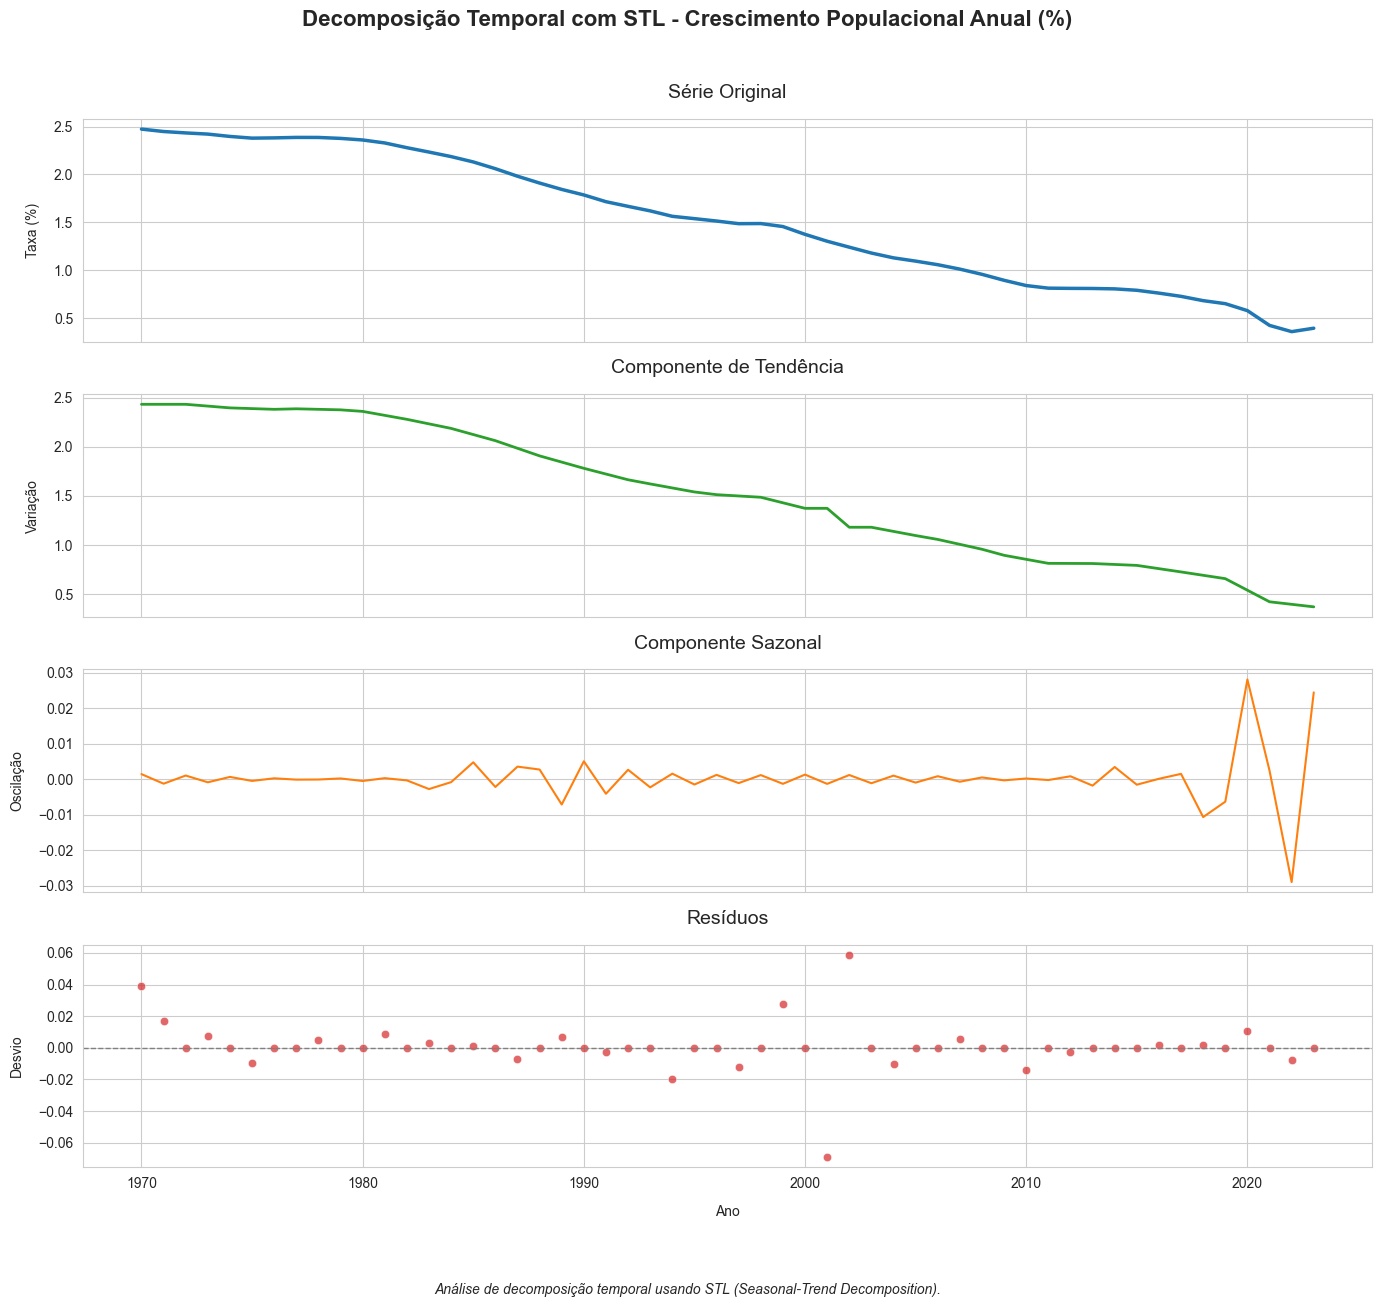

In [47]:

# Configuração de estilo mais robusta
plt.style.use('default')  # Usa o estilo padrão como base
sns.set_style("whitegrid")  # Estilo do seaborn
sns.set_palette("husl")  # Paleta de cores
plt.rcParams['figure.facecolor'] = 'white'  # Fundo branco

# Interpolação
pop_growth = new_df_brasil_wide['Population growth (annual %)'].interpolate()

# Verifica se há dados suficientes
if len(pop_growth) >= 4:
    # STL: usa o Loess para detectar tendência e sazonalidade
    stl = STL(pop_growth, period=2, robust=True)
    res = stl.fit()
    
    # Criar figura
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle('Decomposição Temporal com STL - Crescimento Populacional Anual (%)', 
                 y=1.02, fontsize=16, fontweight='bold')
    
    # Série original
    sns.lineplot(x=pop_growth.index, y=pop_growth, ax=axes[0], linewidth=2.5, color='#1f77b4')
    axes[0].set_title('Série Original', pad=15, fontsize=14)
    axes[0].set_ylabel('Taxa (%)', labelpad=10)
    
    # Tendência
    sns.lineplot(x=res.trend.index, y=res.trend, ax=axes[1], linewidth=2, color='#2ca02c')
    axes[1].set_title('Componente de Tendência', pad=15, fontsize=14)
    axes[1].set_ylabel('Variação', labelpad=10)
    
    # Sazonalidade
    sns.lineplot(x=res.seasonal.index, y=res.seasonal, ax=axes[2], linewidth=1.5, color='#ff7f0e')
    axes[2].set_title('Componente Sazonal', pad=15, fontsize=14)
    axes[2].set_ylabel('Oscilação', labelpad=10)
    
    # Resíduos
    sns.scatterplot(x=res.resid.index, y=res.resid, ax=axes[3], color='#d62728', alpha=0.7)
    axes[3].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[3].set_title('Resíduos', pad=15, fontsize=14)
    axes[3].set_ylabel('Desvio', labelpad=10)
    axes[3].set_xlabel('Ano', labelpad=10)
    
    # Ajuste layout
    plt.tight_layout()
    plt.figtext(0.5, -0.05, 
                "Análise de decomposição temporal usando STL (Seasonal-Trend Decomposition).",
                ha="center", fontsize=10, style='italic')
    
    plt.show()

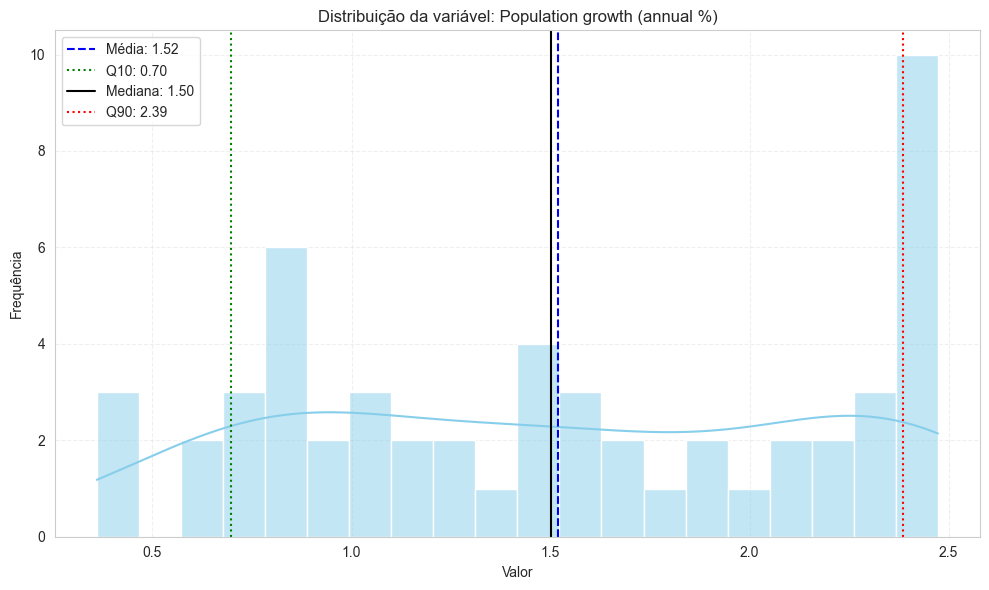

In [48]:
# Seleciona a variável
variavel = 'Population growth (annual %)'
serie = new_df_brasil_wide[variavel].dropna()

# Calcula estatísticas
media = serie.mean()
q10, mediana, q90 = np.percentile(serie, [10, 50, 90])
min_val, max_val = serie.min(), serie.max()

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(serie, kde=True, color='skyblue', bins=20)
plt.axvline(media, color='blue', linestyle='--', label=f'Média: {media:.2f}')
plt.axvline(q10, color='green', linestyle=':', label=f'Q10: {q10:.2f}')
plt.axvline(mediana, color='black', linestyle='-', label=f'Mediana: {mediana:.2f}')
plt.axvline(q90, color='red', linestyle=':', label=f'Q90: {q90:.2f}')
plt.title(f'Distribuição da variável: {variavel}')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


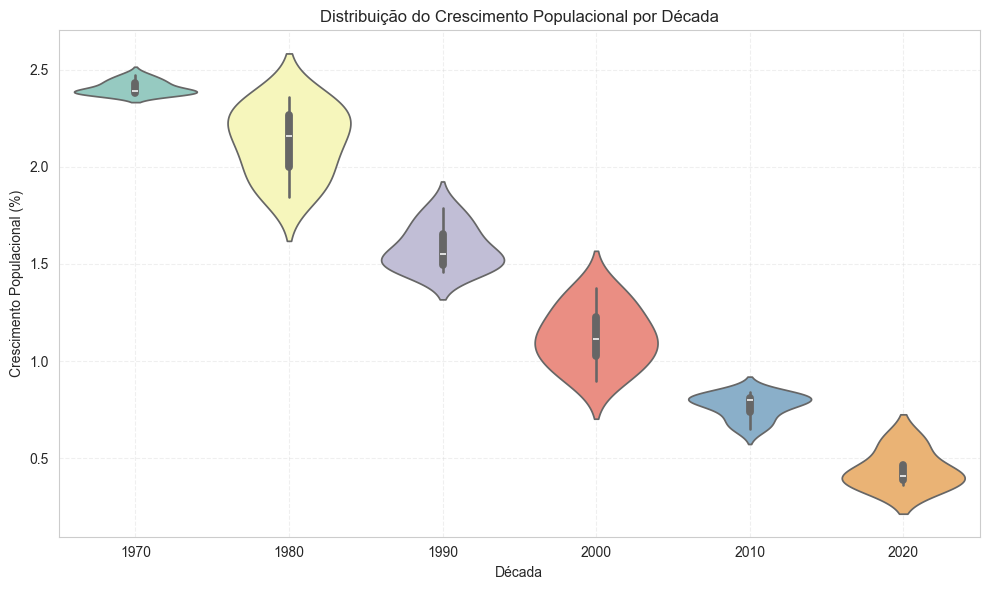

In [49]:
# Criar coluna de década
df_decada = new_df_brasil_wide.copy()
df_decada['Década'] = (df_decada.index // 10) * 10

# Plot para uma variável de interesse
plt.figure(figsize=(10, 6))
sns.violinplot(x='Década', y='Population growth (annual %)', data=df_decada.reset_index(), palette="Set3")
plt.title('Distribuição do Crescimento Populacional por Década')
plt.xlabel('Década')
plt.ylabel('Crescimento Populacional (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## Correlações

Phik por item

interval columns not set, guessing: ['Adjusted net national income (annual % growth)', 'Adjusted net national income (constant 2015 US$)', 'Adjusted savings: education expenditure (% of GNI)', 'Adjusted savings: energy depletion (% of GNI)', 'Adjusted savings: gross savings (% of GNI)', 'Adjusted savings: mineral depletion (% of GNI)', 'Adjusted savings: net national savings (% of GNI)', 'Adjusted savings: net national savings (current US$)', 'Adolescent fertility rate (births per 1,000 women ages 15-19)', 'Agricultural land (% of land area)', 'Agricultural raw materials exports (% of merchandise exports)', 'Agricultural raw materials imports (% of merchandise imports)', 'Agriculture, forestry, and fishing, value added (annual % growth)', 'Arable land (hectares per person)', 'Arms exports (SIPRI trend indicator values)', 'Arms imports (SIPRI trend indicator values)', 'Average precipitation in depth (mm per year)', 'Broad money (% of GDP)', 'Broad money growth (annual %)', 'Broad money 

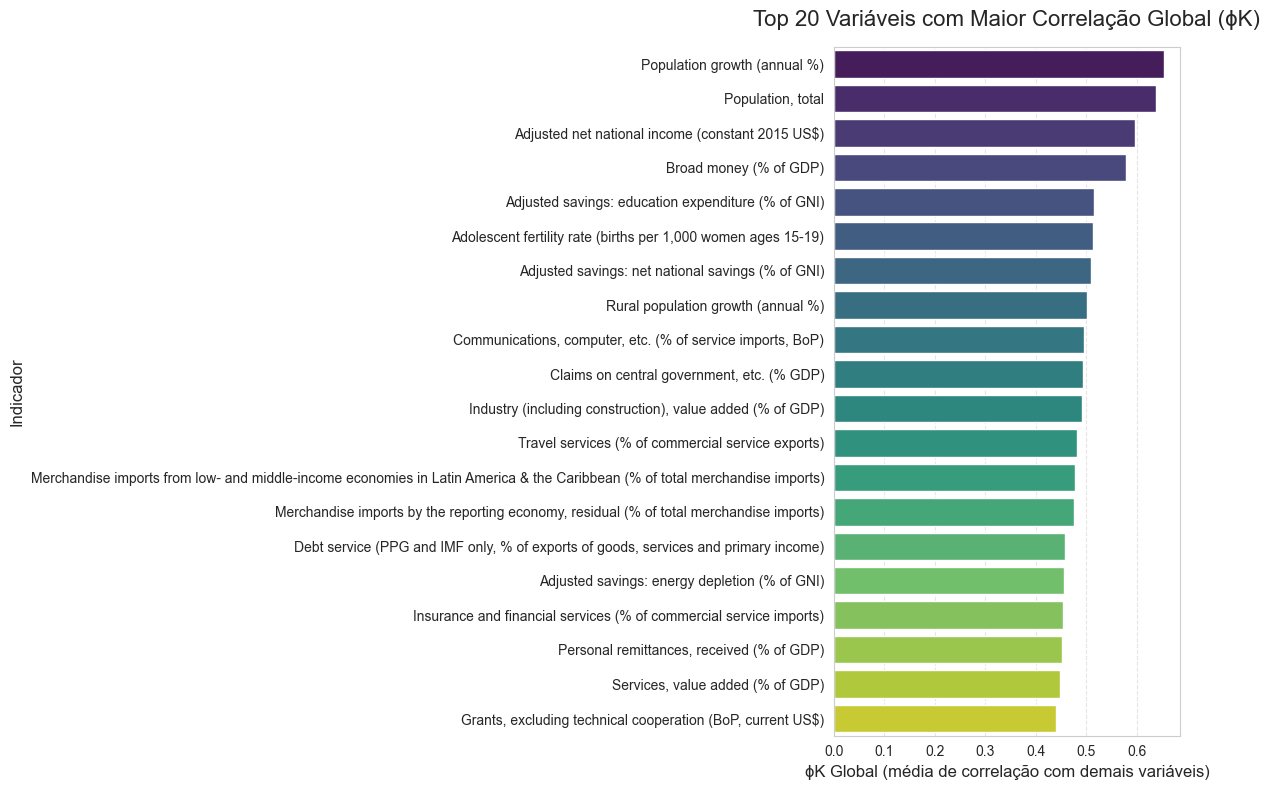

In [50]:
# Passo 1: interpolar valores faltantes
df_interp = new_df_brasil_wide.interpolate(method='linear', limit_direction='both')

# Passo 2: calcular matriz phik
phik_corr = df_interp.phik_matrix()

# Passo 3: calcular o vetor de correlação global (ϕK global)
phik_global = phik_corr.dropna(axis=0, how='all').mean(axis=1).sort_values(ascending=False)

# Passo 4: plotar o gráfico
plt.figure(figsize=(12, 8))
sns.barplot(y=phik_global.index[:20], x=phik_global.values[:20], palette='viridis')
plt.title('Top 20 Variáveis com Maior Correlação Global (ϕK)', fontsize=16, pad=15)
plt.xlabel('ϕK Global (média de correlação com demais variáveis)', fontsize=12)
plt.ylabel('Indicador', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

phik por macro tema

interval columns not set, guessing: ['Foreign direct investment, net outflows (% of GDP)', 'Net errors and omissions (BoP, current US$)', 'Reserves and related items (BoP, current US$)', 'Foreign direct investment, net inflows (% of GDP)', 'Portfolio equity, net inflows (BoP, current US$)', 'Current account balance (BoP, current US$)', 'Current account balance (% of GDP)', 'Net trade in goods (BoP, current US$)', 'Communications, computer, etc. (% of service imports, BoP)', 'Net secondary income (BoP, current US$)', 'Personal remittances, received (% of GDP)', 'Grants, excluding technical cooperation (BoP, current US$)', 'External debt stocks (% of GNI)', 'Short-term debt (% of total reserves)', 'Short-term debt (% of exports of goods, services and primary income)', 'Short-term debt (% of total external debt)', 'Total debt service (% of exports of goods, services and primary income)', 'Total debt service (% of GNI)', 'Public and publicly guaranteed debt service (% of GNI)', 'Multilater

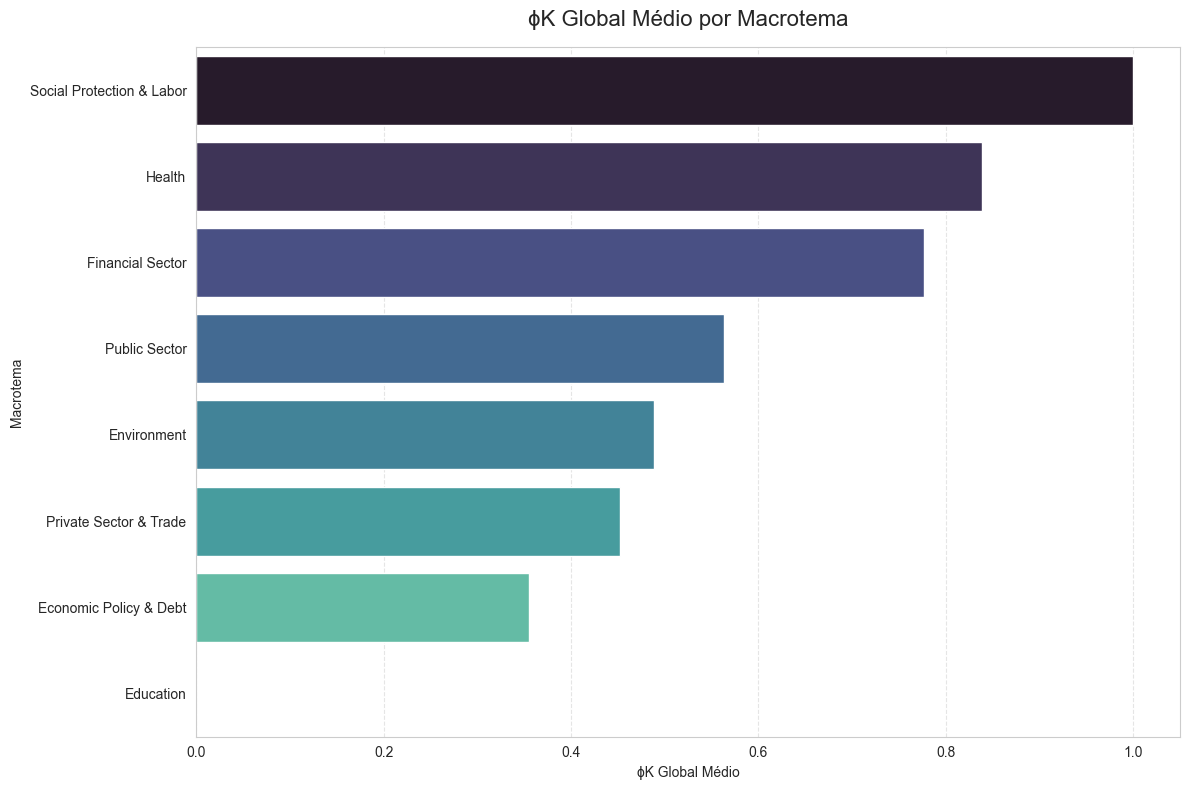

In [51]:
# Armazenar resultados
phik_macrotemas = {}

for tema, df in dfs_macrotema_unificado.items():
    # Interpola para preencher valores ausentes
    df_interp = df.interpolate(method='linear', limit_direction='both')

    try:
        # Calcula a matriz de correlação ϕK
        phik_corr = df_interp.phik_matrix()

        # Calcula o ϕK global (média das correlações de cada variável com as outras)
        phik_global_medio = phik_corr.dropna(axis=0, how='all').mean().mean()
        phik_macrotemas[tema] = phik_global_medio

    except Exception as e:
        print(f"Erro no macrotema '{tema}': {e}")

# Converter para DataFrame
phik_df = pd.DataFrame.from_dict(phik_macrotemas, orient='index', columns=['ϕK Global Médio'])
phik_df.sort_values('ϕK Global Médio', ascending=False, inplace=True)

# Plotar gráfico
plt.figure(figsize=(12, 8))
sns.barplot(x=phik_df['ϕK Global Médio'], y=phik_df.index, palette='mako')
plt.title('ϕK Global Médio por Macrotema', fontsize=16, pad=15)
plt.xlabel('ϕK Global Médio')
plt.ylabel('Macrotema')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Pear por itens

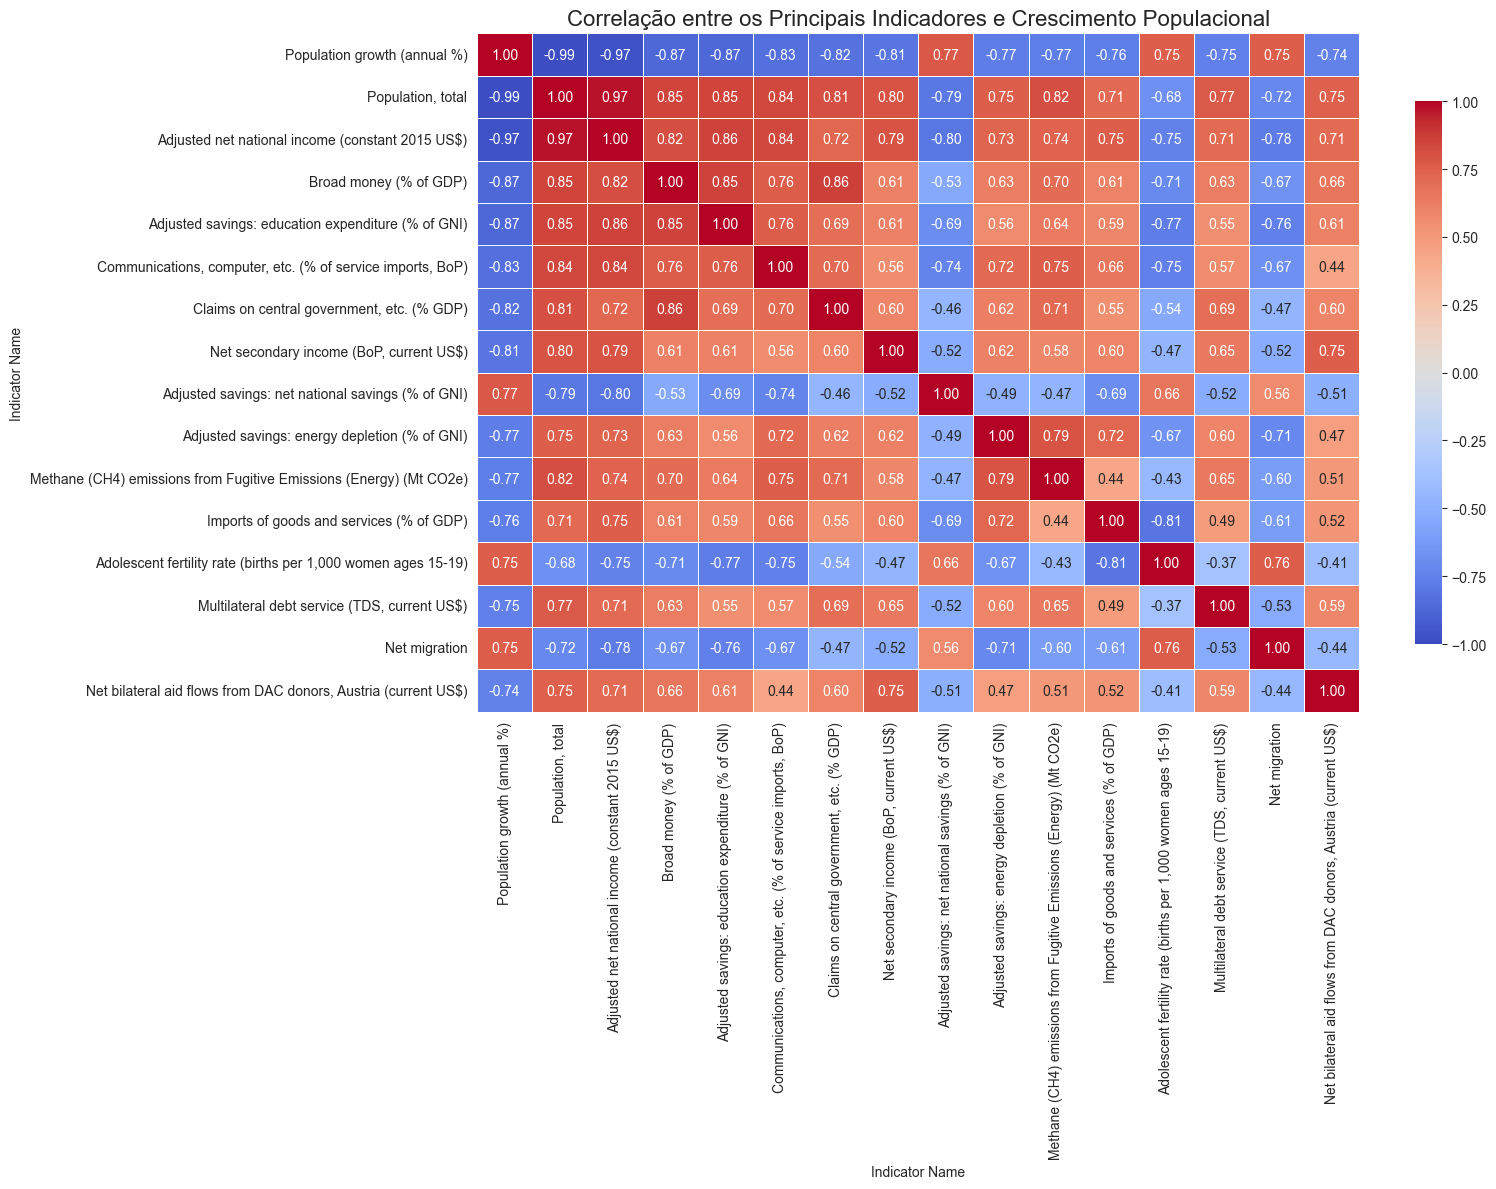

In [52]:
# 1. Análise de Correlação Avançada
plt.figure(figsize=(16, 12))
# Selecionando os 15 indicadores mais correlacionados com crescimento populacional
corr_pop = new_df_brasil_wide.corr()['Population growth (annual %)'].abs().sort_values(ascending=False)
top_15_vars = corr_pop.head(16).index
corr_matrix = new_df_brasil_wide[top_15_vars].corr()

# Máscara para triângulo superior
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlação entre os Principais Indicadores e Crescimento Populacional', fontsize=16)
plt.tight_layout()
plt.show()

pearson por macro

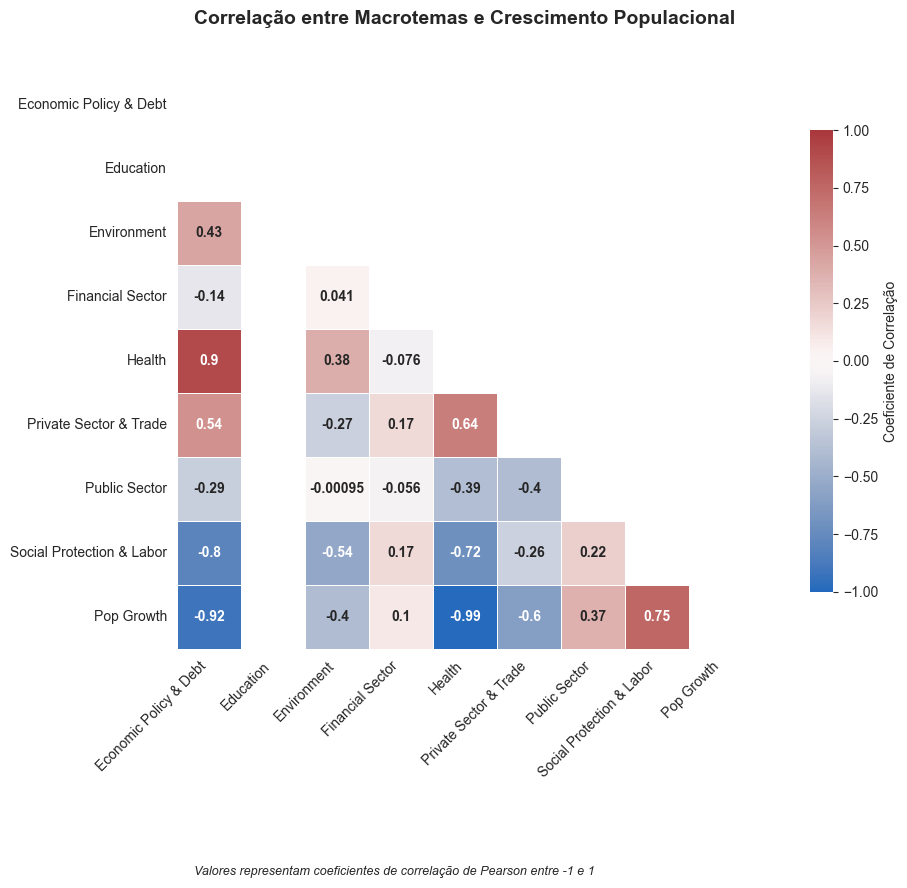

In [53]:
medias_macro = {}
for macrotema, df_macro in dfs_macrotema_unificado.items():
    df_macro_interp = df_macro.interpolate(method='linear', limit_direction='both')
    medias_macro[macrotema] = df_macro_interp.mean(axis=1)

df_macro_medias = pd.DataFrame(medias_macro)
df_macro_medias['Pop Growth'] = new_df_brasil_wide['Population growth (annual %)']
# Configurações de estilo
plt.style.use('default')
sns.set_style("white")
plt.rcParams['figure.facecolor'] = 'white'

# Criar a figura
plt.figure(figsize=(12, 8))

# Gerar a máscara para o triângulo superior (opcional)
mask = np.triu(np.ones_like(df_macro_medias.corr(), dtype=bool))

# Heatmap aprimorado
heatmap = sns.heatmap(
    df_macro_medias.corr(),
    mask=mask,  # Remover se quiser mostrar toda a matriz
    annot=True,
    annot_kws={'size': 10, 'weight': 'bold'},
    cmap='vlag',  # Alternativa: 'coolwarm', 'RdBu_r', 'icefire'
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Correlação'}
)

# Melhorar título
plt.title(
    "Correlação entre Macrotemas e Crescimento Populacional\n",
    fontsize=14,
    pad=20,
    fontweight='bold'
)

# Rotacionar os rótulos do eixo x
heatmap.set_xticklabels(
    heatmap.get_xticklabels(),
    rotation=45,
    horizontalalignment='right',
    fontsize=10
)

# Ajustar rótulos do eixo y
heatmap.set_yticklabels(
    heatmap.get_yticklabels(),
    rotation=0,
    fontsize=10
)

# Adicionar grade de referência (opcional)
heatmap.grid(False)

# Ajustar layout
plt.tight_layout()

# Adicionar nota de rodapé
plt.figtext(
    0.5, -0.1,
    "Valores representam coeficientes de correlação de Pearson entre -1 e 1",
    ha="center",
    fontsize=9,
    style='italic'
)

plt.show()



## Principais correlações com o crescimento populacional

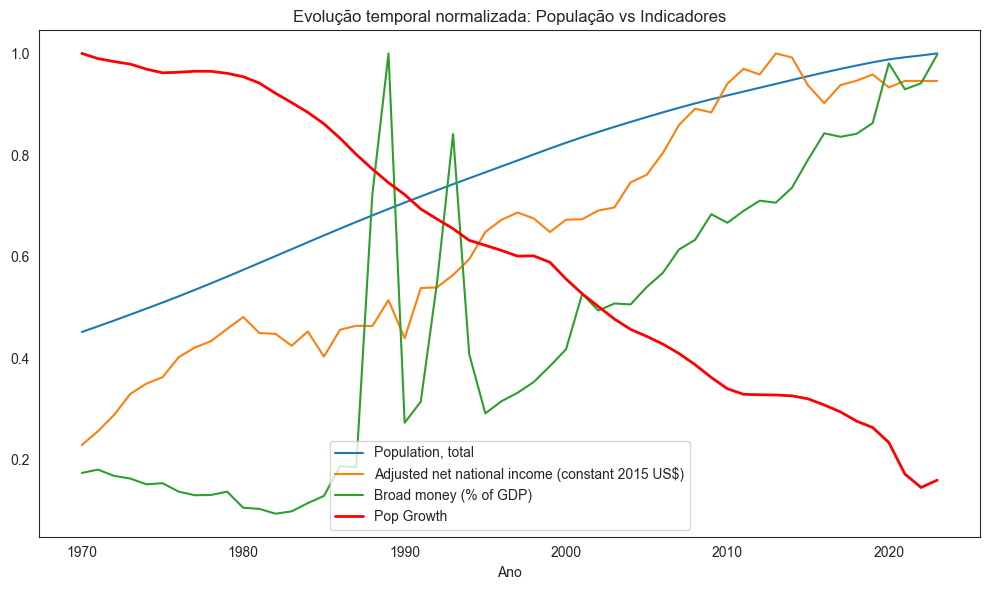

In [54]:
plt.figure(figsize=(10, 6))

# Seleciona as 3 variáveis mais correlacionadas com o crescimento populacional
top_k = new_df_brasil_wide.corr()['Population growth (annual %)'].abs().sort_values(ascending=False)[1:4]

# Normaliza os indicadores pela escala máxima
for var in top_k.index:
    plt.plot(new_df_brasil_wide.index, new_df_brasil_wide[var] / new_df_brasil_wide[var].max(), label=var)

plt.plot(new_df_brasil_wide.index, new_df_brasil_wide['Population growth (annual %)'] / new_df_brasil_wide['Population growth (annual %)'].max(),
         label='Pop Growth', linewidth=2, color='red')

plt.legend()
plt.title("Evolução temporal normalizada: População vs Indicadores")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()



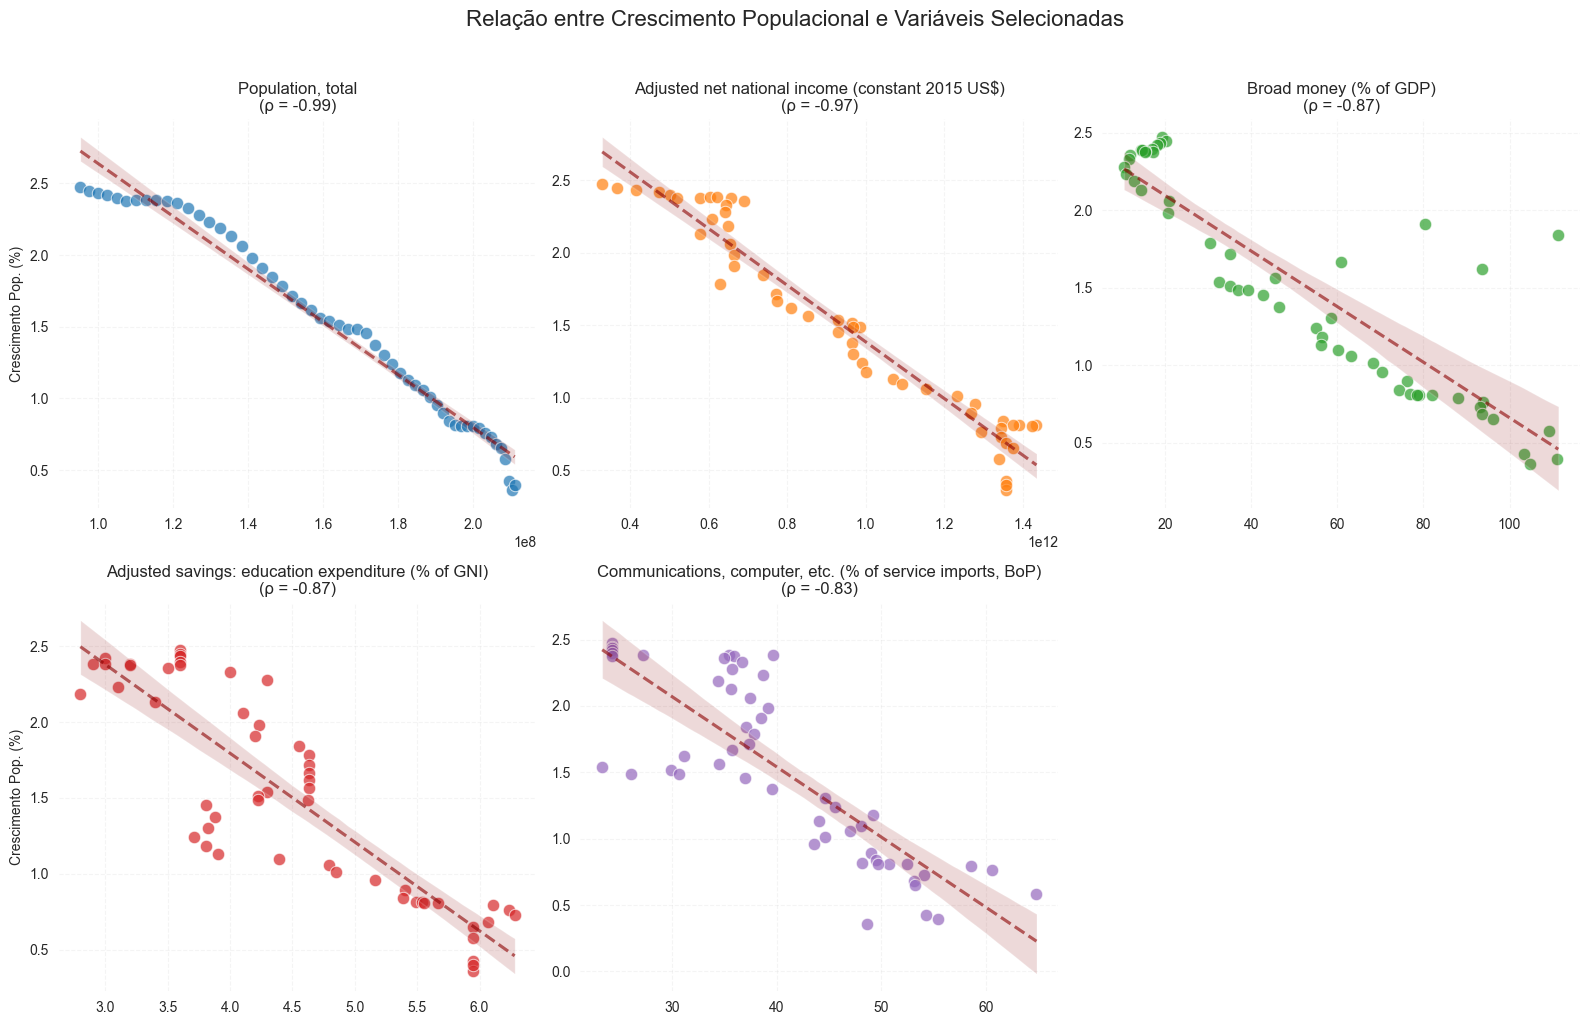

In [55]:
top_k = new_df_brasil_wide.corr()['Population growth (annual %)'].abs().sort_values(ascending=False)[1:6]

# Configurar a figura com subplots
plt.figure(figsize=(16, 10), facecolor='white')
plt.suptitle('Relação entre Crescimento Populacional e Variáveis Selecionadas', y=1.02, fontsize=16)

# Criar um subplot para cada variável
for i, var in enumerate(top_k.index, 1):
    plt.subplot(2, 3, i)  # 2 linhas, 3 colunas

    # Scatterplot
    ax = sns.scatterplot(
        data=new_df_brasil_wide,
        x=var,
        y='Population growth (annual %)',
        color=plt.cm.tab10(i-1),  # Cores diferentes para cada variável
        s=80,
        alpha=0.7
    )

    # Linha de regressão
    sns.regplot(
        data=new_df_brasil_wide,
        x=var,
        y='Population growth (annual %)',
        scatter=False,
        color='darkred',
        line_kws={'linestyle':'--', 'alpha':0.6}
    )

    # Adicionar título e coeficiente de correlação
    corr = new_df_brasil_wide.corr().loc[var, 'Population growth (annual %)']
    plt.title(f'{var}\n(ρ = {corr:.2f})', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Crescimento Pop. (%)' if i == 1 or i == 4 else '', fontsize=10)

    # Grid e estilo
    plt.grid(True, linestyle='--', alpha=0.2)
    sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## Agrupamentos por PCA

In [56]:
def realizar_pca_macrotemas(dfs_macrotema_unificado):
    """
    Realiza PCA para cada macrotema e gera visualizações.
    
    Args:
        dfs_macrotema_unificado: Dicionário contendo dataframes por macrotema
    """
    # Dicionário para armazenar resultados do PCA
    pca_resultados = {}
    
    # Número máximo de componentes a considerar
    max_componentes = 3
    
    # Para cada macrotema
    for macrotema, df in dfs_macrotema_unificado.items():
        print(f"\n## Analisando macrotema: {macrotema}")
        
        # Interpolar valores faltantes
        df_interpolado = df.interpolate(method='linear', limit_direction='both')
        
        # Verificar se existem dados suficientes
        if df_interpolado.shape[0] < 2 or df_interpolado.shape[1] < 2:
            print(f"Dados insuficientes para o macrotema {macrotema}")
            continue
        
        # Padronização (z-score)
        scaler = StandardScaler()
        df_scaled = pd.DataFrame(
            scaler.fit_transform(df_interpolado),
            index=df_interpolado.index,
            columns=df_interpolado.columns
        )
        
        # Determinar número de componentes
        n_componentes = min(df_scaled.shape[1], max_componentes)
        
        try:
            # Aplicar PCA
            pca = PCA(n_components=n_componentes)
            pca_result = pca.fit_transform(df_scaled)
            
            # Criar DataFrame com resultados
            df_pca = pd.DataFrame(
                pca_result,
                index=df_scaled.index,
                columns=[f'PC{i+1}' for i in range(n_componentes)]
            )
            
            # Armazenar resultados
            pca_resultados[macrotema] = {
                'pca': pca,
                'df_pca': df_pca,
                'variancia_explicada': pca.explained_variance_ratio_,
                'loadings': pd.DataFrame(
                    pca.components_.T,
                    index=df_scaled.columns,
                    columns=[f'PC{i+1}' for i in range(n_componentes)]
                )
            }
            
            print(f"  ✓ PCA realizado com sucesso: {n_componentes} componentes")
            print(f"  ✓ Variância explicada: {pca.explained_variance_ratio_.sum():.2%}")
            
        except Exception as e:
            print(f"Erro ao realizar PCA para {macrotema}: {e}")
    
    return pca_resultados

In [57]:
def plotar_variancias_explicadas(pca_resultados):
    """
    Gera gráficos de barras para a variância explicada por cada componente principal, organizados 3 a 3.
    """
    temas = list(pca_resultados.keys())
    total = len(temas)
    cols = 3
    rows = math.ceil(total / cols)

    fig = make_subplots(
        rows=rows, 
        cols=cols,
        subplot_titles=[f"Variância Explicada - {tema}" for tema in temas],
        vertical_spacing=0.15,
        horizontal_spacing=0.1
    )
    
    cores = px.colors.qualitative.Plotly
    
    for idx, (tema, resultado) in enumerate(pca_resultados.items()):
        row = idx // cols + 1
        col = idx % cols + 1

        variancias = resultado['variancia_explicada']
        variancia_cumulativa = np.cumsum(variancias)
        
        fig.add_trace(
            go.Bar(
                x=[f'PC{j+1}' for j in range(len(variancias))],
                y=variancias * 100,
                name=f"{tema} - Individual",
                marker_color=cores[idx % len(cores)],
                opacity=0.7,
                showlegend=False
            ),
            row=row, col=col
        )
        
        fig.add_trace(
            go.Scatter(
                x=[f'PC{j+1}' for j in range(len(variancias))],
                y=variancia_cumulativa * 100,
                mode='lines+markers',
                name=f"{tema} - Cumulativa",
                marker=dict(color='red'),
                line=dict(width=2),
                showlegend=False
            ),
            row=row, col=col
        )

        fig.add_shape(
            type='line',
            x0=-0.5,
            x1=len(variancias)-0.5,
            y0=75,
            y1=75,
            line=dict(color='green', width=1, dash='dash'),
            row=row, col=col
        )
    
    fig.update_layout(
        height=350 * rows,
        width=1000,
        title_text="Variância Explicada por Componentes Principais",
        showlegend=False
    )
    
    fig.update_yaxes(title_text="Variância Explicada (%)", range=[0, 105])
    fig.update_xaxes(title_text="Componentes Principais")
    
    return fig

In [58]:
resultados_pca = realizar_pca_macrotemas(dfs_macrotema_unificado)

if resultados_pca:
    # Plotar variâncias explicadas
    fig_variancias = plotar_variancias_explicadas(resultados_pca)
    fig_variancias.show()


## Analisando macrotema: Economic Policy & Debt
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 45.70%

## Analisando macrotema: Education
  ✓ PCA realizado com sucesso: 2 componentes
  ✓ Variância explicada: nan%

## Analisando macrotema: Environment
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 73.18%

## Analisando macrotema: Financial Sector
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 88.80%

## Analisando macrotema: Health
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 99.84%

## Analisando macrotema: Private Sector & Trade
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 62.16%

## Analisando macrotema: Public Sector
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 100.00%

## Analisando macrotema: Social Protection & Labor
Dados insuficientes para o macrotema Social Protection & Labor


In [59]:
from scipy.stats import zscore

# Preencher e padronizar
df = dfs_macrotema_unificado["Economic Policy & Debt"].interpolate(method='linear', limit_direction='both')
df_zscore = df.apply(zscore)
crescimento_zscore = zscore(new_df_brasil_wide['Population growth (annual %)'])

# Função para correlação cruzada
def max_cross_corr(series1, series2, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    corrs = [series1.corr(series2.shift(lag)) for lag in lags]
    return max(corrs, key=abs)

# Parâmetros
min_corr_com_pop = 0.7  # Remover se a correlação cruzada máxima for menor que isso
max_lag = 5

# Identificar variáveis com fraca relação com o crescimento populacional
variaveis_fracas = []

for col in df_zscore.columns:
    corr = max_cross_corr(df_zscore[col], pd.Series(crescimento_zscore, index=df_zscore.index), max_lag=max_lag)
    if abs(corr) < min_corr_com_pop:
        variaveis_fracas.append(col)

# Remover do DataFrame original
dfs_macrotema_unificado["Economic Policy & Debt"] = df.drop(columns=variaveis_fracas)

print(f"\n{len(variaveis_fracas)} variáveis removidas por fraca correlação cruzada com o crescimento populacional.")



66 variáveis removidas por fraca correlação cruzada com o crescimento populacional.


In [60]:
from scipy.stats import zscore

# Preencher e padronizar
df = dfs_macrotema_unificado["Private Sector & Trade"].interpolate(method='linear', limit_direction='both')
df_zscore = df.apply(zscore)
crescimento_zscore = zscore(new_df_brasil_wide['Population growth (annual %)'])

# Função para correlação cruzada
def max_cross_corr(series1, series2, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    corrs = [series1.corr(series2.shift(lag)) for lag in lags]
    return max(corrs, key=abs)

# Parâmetros
min_corr_com_pop = 0.7  # Remover se a correlação cruzada máxima for menor que isso
max_lag = 5

# Identificar variáveis com fraca relação com o crescimento populacional
variaveis_fracas = []

for col in df_zscore.columns:
    corr = max_cross_corr(df_zscore[col], pd.Series(crescimento_zscore, index=df_zscore.index), max_lag=max_lag)
    if abs(corr) < min_corr_com_pop:
        variaveis_fracas.append(col)

# Remover do DataFrame original
dfs_macrotema_unificado["Private Sector & Trade"] = df.drop(columns=variaveis_fracas)

print(f"\n{len(variaveis_fracas)} variáveis removidas por fraca correlação cruzada com o crescimento populacional.")


13 variáveis removidas por fraca correlação cruzada com o crescimento populacional.


In [61]:
resultados_pca = realizar_pca_macrotemas(dfs_macrotema_unificado)

if resultados_pca:
    # Plotar variâncias explicadas
    fig_variancias = plotar_variancias_explicadas(resultados_pca)
    fig_variancias.show()


## Analisando macrotema: Economic Policy & Debt
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 78.71%

## Analisando macrotema: Education
  ✓ PCA realizado com sucesso: 2 componentes
  ✓ Variância explicada: nan%

## Analisando macrotema: Environment
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 73.18%

## Analisando macrotema: Financial Sector
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 88.80%

## Analisando macrotema: Health
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 99.84%

## Analisando macrotema: Private Sector & Trade
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 85.25%

## Analisando macrotema: Public Sector
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 100.00%

## Analisando macrotema: Social Protection & Labor
Dados insuficientes para o macrotema Social Protection & Labor


# Modelagem Curva de Crescimento

In [62]:
# 1) Carregar e preparar os dados
# Anos serão deslocados para melhorar a convergência
anos_originais = new_df_brasil_wide.index.values.astype(float)
anos = anos_originais - anos_originais.min()  # Ajustar para iniciar em 0
pop = new_df_brasil_wide['Population, total'].values.astype(float) / 1e6  # Escala em milhões

# 2) Definir funções de crescimento populacional
def logistic(t, K, r, t0):
    """Modelo logístico (Verhulst): crescimento com capacidade de suporte."""
    return K / (1 + np.exp(-r * (t - t0)))

def gompertz(t, K, b, r):
    """Modelo de Gompertz: crescimento assimétrico."""
    return K * np.exp(-b * np.exp(-r * t))

def richards(t, K, r, t0, v):
    """Modelo de Richards: logístico generalizado com ponto de inflexão variável."""
    return K / (1 + v * np.exp(-r * (t - t0)))**(1/v)

def bertalanffy(t, K, r, t0):
    """Modelo de von Bertalanffy: crescimento com taxa decrescente."""
    return K * (1 - np.exp(-r * (t - t0)))**3

def weibull(t, K, k, lam):
    """Modelo de Weibull: crescimento com taxa variável."""
    # Adicionamos um pequeno valor para evitar divisão por zero
    return K * (1 - np.exp(-(t/lam)**k))

def brody(t, K, B, k):
    """Modelo de Brody: crescimento exponencial modificado."""
    return K * (1 - B * np.exp(-k * t))

def exponential(t, a, b):
    """Modelo de crescimento exponencial."""
    return a * np.exp(b * t)

In [63]:
# 3) Preparar modelos para teste
models = {
    'Logístico': (logistic, 3, [max(pop)*1.2, 0.05, np.median(anos)]),
    'Gompertz': (gompertz, 3, [max(pop)*1.2, 2.0, 0.05]),
    'Richards': (richards, 4, [max(pop)*1.2, 0.05, np.median(anos), 1.0]),
    'Bertalanffy': (bertalanffy, 3, [max(pop)*1.2, 0.05, min(anos)]),
    'Weibull': (weibull, 3, [max(pop)*1.2, 2.0, np.median(anos)]),
    'Brody': (brody, 3, [max(pop)*1.2, 1.0, 0.05]),
    'Exponencial': (exponential, 2, [pop[0], 0.02])
}

# Configuração para validação cruzada histórica
n_validacao = 10  # Usar os últimos 10 anos para validação
anos_treino = anos[:-n_validacao]
pop_treino = pop[:-n_validacao]
anos_teste = anos[-n_validacao:]
pop_teste = pop[-n_validacao:]


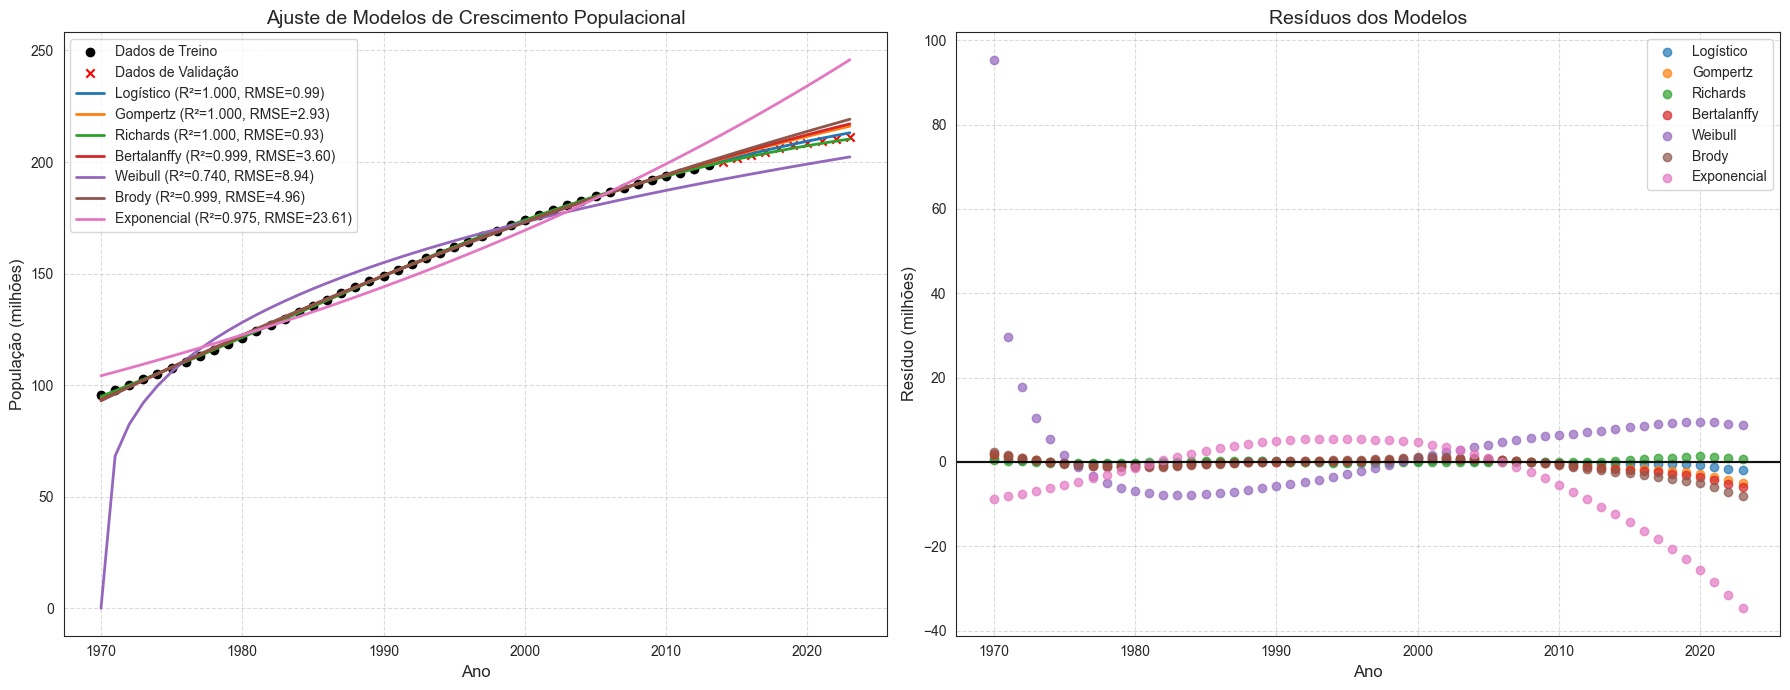


Comparação de Modelos:


,RMSE (treino),RMSE (teste),R² (treino),R² (teste),AIC,BIC
Modelo,,,,,,
Logístico,0.3510,0.9854,0.9999,0.9248,-84.12,-76.98
Gompertz,0.6314,2.9251,0.9996,0.3370,-32.47,-25.33
Richards,0.1957,0.9328,1.0000,0.9326,-133.56,-124.64
Bertalanffy,0.7330,3.5986,0.9995,-0.0035,-19.34,-12.20
Weibull,16.1800,8.9379,0.7396,-5.1903,252.97,260.11
Brody,0.9426,4.9642,0.9991,-0.9096,2.80,9.94
Exponencial,4.9721,23.6093,0.9754,-42.1923,147.14,152.49


In [64]:
# 4) Ajustar modelos e calcular métricas
results = []
cor_cycle = cm.tab10.colors

# Figura para comparação dos ajustes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plotar dados reais (treino e validação)
anos_originais_treino = anos_originais[:-n_validacao]
anos_originais_teste = anos_originais[-n_validacao:]
ax1.scatter(anos_originais_treino, pop_treino, color='black', label='Dados de Treino')
ax1.scatter(anos_originais_teste, pop_teste, color='red', marker='x', label='Dados de Validação')

# Ajuste dos modelos
pcovs = {}
for i, (name, (func, k, p0)) in enumerate(models.items()):
    try:
        # Ajuste do modelo com dados de treino
        params, pcov = curve_fit(func, anos_treino, pop_treino, p0=p0, maxfev=50000, bounds=(-np.inf, np.inf))
        pcovs[name] = pcov  # salva a matriz de covariância real

        # Calcular valores ajustados
        fitted_treino = func(anos_treino, *params)
        fitted_teste = func(anos_teste, *params)
        fitted_todos = func(anos, *params)
        
        # Métricas de treino
        rmse_treino = np.sqrt(mean_squared_error(pop_treino, fitted_treino))
        r2_treino = r2_score(pop_treino, fitted_treino)
        mae_treino = mean_absolute_error(pop_treino, fitted_treino)
        
        # Métricas de teste (validação)
        rmse_teste = np.sqrt(mean_squared_error(pop_teste, fitted_teste))
        r2_teste = r2_score(pop_teste, fitted_teste)
        mae_teste = mean_absolute_error(pop_teste, fitted_teste)
        
        # Critérios de informação
        n = len(pop_treino)
        sse = np.sum((pop_treino - fitted_treino)**2)
        aic = n * np.log(sse/n) + 2 * (k + 1)  # k parâmetros + 1 para variância
        bic = n * np.log(sse/n) + (k + 1) * np.log(n)
        
        # Calcular intervalos de confiança para os parâmetros
        perr = np.sqrt(np.diag(pcov))
        params_ci = [(p - 1.96*e, p + 1.96*e) for p, e in zip(params, perr)]
        
        results.append({
            'Modelo': name,
            'Parâmetros': np.round(params, 4).tolist(),
            'IC 95%': np.round(params_ci, 4).tolist(),
            'RMSE (treino)': round(rmse_treino, 4),
            'RMSE (teste)': round(rmse_teste, 4),
            'MAE (treino)': round(mae_treino, 4),
            'MAE (teste)': round(mae_teste, 4),
            'R² (treino)': round(r2_treino, 4),
            'R² (teste)': round(r2_teste, 4),
            'AIC': round(aic, 2),
            'BIC': round(bic, 2)
        })
        
        # Plotar curva ajustada (gráfico 1)
        cor = cor_cycle[i % len(cor_cycle)]
        ax1.plot(anos_originais, fitted_todos, color=cor, 
                 label=f'{name} (R²={r2_treino:.3f}, RMSE={rmse_teste:.2f})', 
                 linewidth=2)
        
        # Plotar resíduos (gráfico 2)
        residuos = pop - fitted_todos
        ax2.scatter(anos_originais, residuos, color=cor, alpha=0.7, label=name)
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        
    except Exception as e:
        print(f"Erro no modelo {name}: {e}")

# Configurar gráfico de ajuste
ax1.set_title('Ajuste de Modelos de Crescimento Populacional', fontsize=14)
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('População (milhões)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)

# Configurar gráfico de resíduos
ax2.set_title('Resíduos dos Modelos', fontsize=14)
ax2.set_xlabel('Ano', fontsize=12)
ax2.set_ylabel('Resíduo (milhões)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Exibir resultados em formato tabular
df_results = pd.DataFrame(results).set_index('Modelo')
print("\nComparação de Modelos:")
display(df_results[['RMSE (treino)', 'RMSE (teste)', 'R² (treino)', 'R² (teste)', 'AIC', 'BIC']])


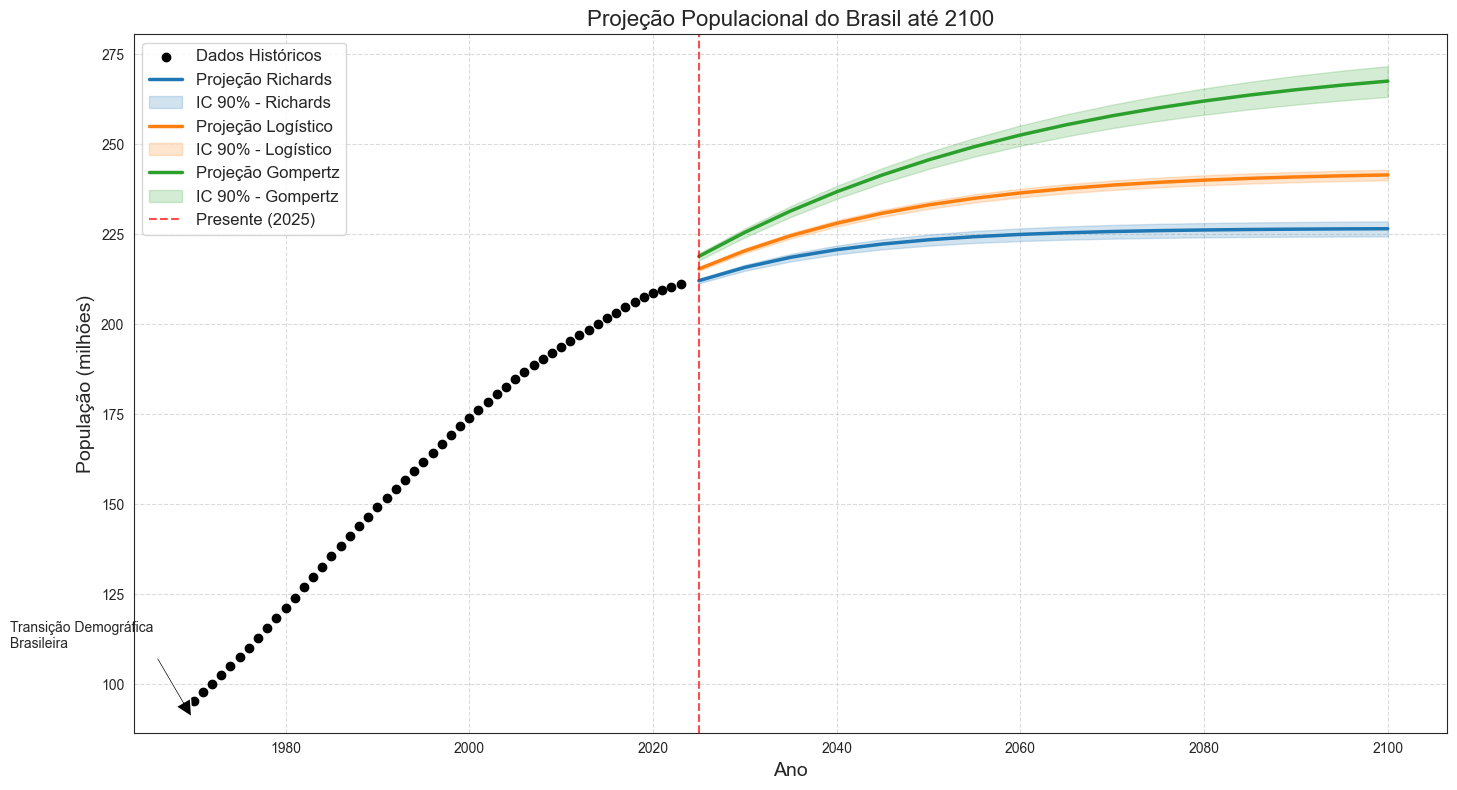

In [65]:
# 5) Projeção futura (2025 a 2100)
# Calcular anos futuros na escala deslocada
anos_futuros_originais = np.arange(2025, 2101, 5)
anos_futuros = anos_futuros_originais - anos_originais.min()

# Selecionar os 3 melhores modelos baseado no RMSE de teste
df_sorted = df_results.sort_values('RMSE (teste)')
top_models = df_sorted.index[:3].tolist()

plt.figure(figsize=(14, 8))

# Plotar dados históricos
plt.scatter(anos_originais, pop, color='black', label='Dados Históricos')

cores = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Projeções dos melhores modelos
for i, model_name in enumerate(top_models):
    func = models[model_name][0]
    params = df_results.loc[model_name, 'Parâmetros']
    
    # Calcular projeção
    projecao = func(anos_futuros, *params)
    
    # Calcular intervalos de confiança por simulação de Monte Carlo
    n_sim = 1000
    projections_sim = np.zeros((n_sim, len(anos_futuros)))
    
    # Obter covariância e parâmetros
# Obter covariância real do modelo ajustado
    pcov = pcovs[model_name]
    params_mean = np.array(params)
    
    # Simular parâmetros
    params_sim = np.random.multivariate_normal(params_mean, pcov, size=n_sim)
    
    # Calcular projeções para cada conjunto de parâmetros
    for j in range(n_sim):
        try:
            projections_sim[j, :] = func(anos_futuros, *params_sim[j, :])
        except:
            projections_sim[j, :] = projecao  # fallback para parâmetros que causam erro
    
    # Calcular intervalos de confiança (percentis 5% e 95%)
    lower_bound = np.percentile(projections_sim, 5, axis=0)
    upper_bound = np.percentile(projections_sim, 95, axis=0)
    
    # Plotar projeção e intervalo de confiança
    plt.plot(anos_futuros_originais, projecao, '-', color=cores[i], 
             linewidth=2.5, label=f'Projeção {model_name}')
    plt.fill_between(anos_futuros_originais, lower_bound, upper_bound, 
                      color=cores[i], alpha=0.2, label=f'IC 90% - {model_name}')

# Configurar gráfico
plt.title('Projeção Populacional do Brasil até 2100', fontsize=16)
plt.xlabel('Ano', fontsize=14)
plt.ylabel('População (milhões)', fontsize=14)
plt.axvline(x=2025, color='red', linestyle='--', alpha=0.7, label='Presente (2025)')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Adicionar anotações para eventos históricos relevantes
plt.annotate('Transição Demográfica\nBrasileira', xy=(1970, 90), xytext=(1950, 110),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5), fontsize=10)

plt.show()


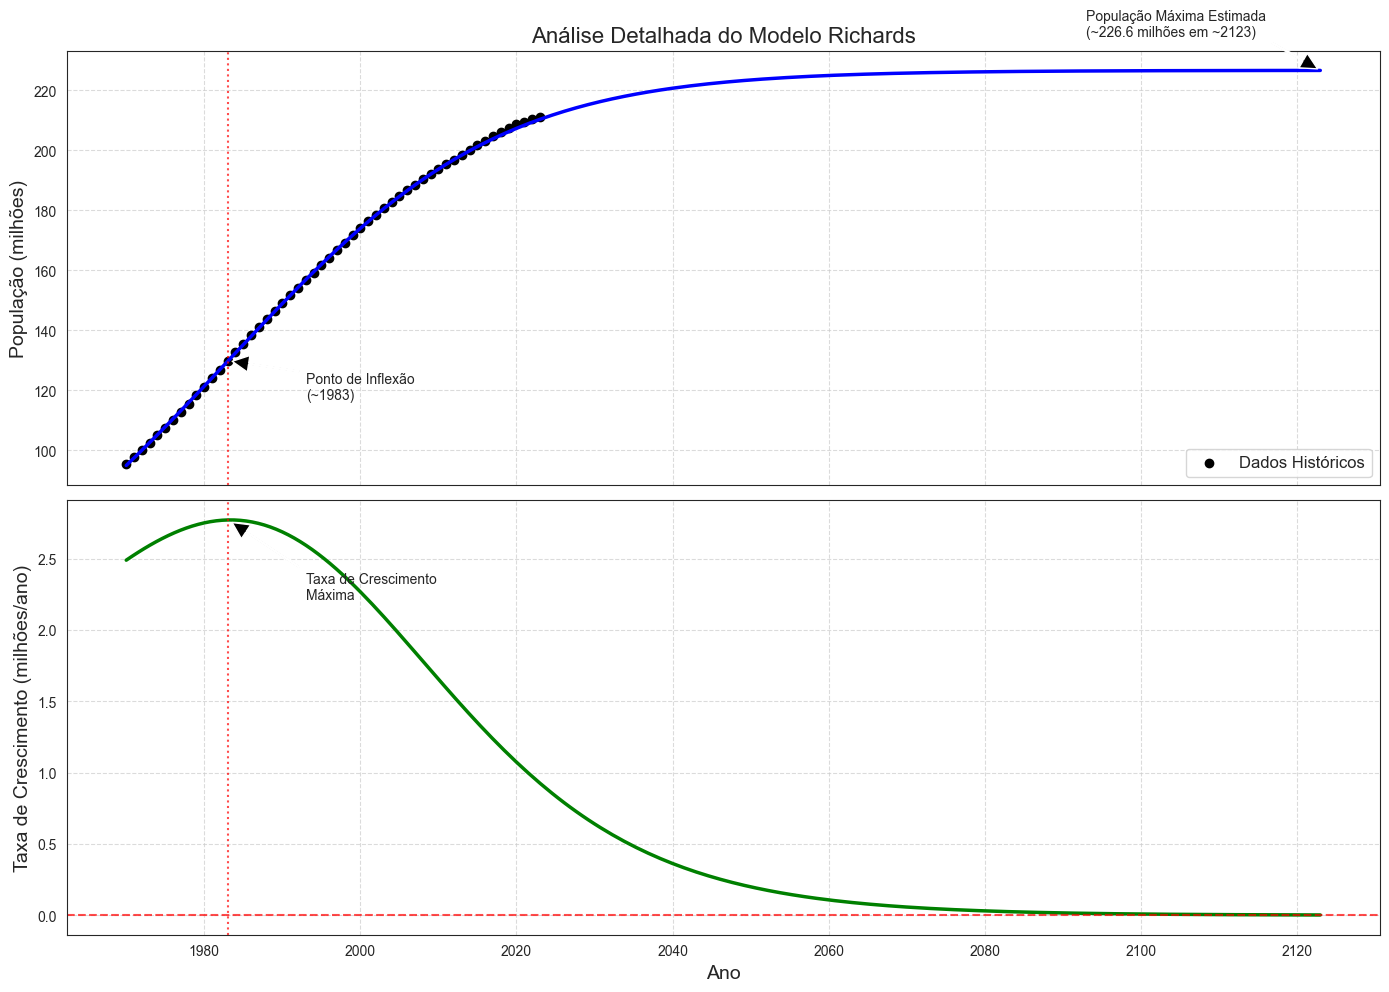

In [66]:
# 6) Análise detalhada do melhor modelo
best_model_name = top_models[0]
best_model_func = models[best_model_name][0]
best_params = df_results.loc[best_model_name, 'Parâmetros']

# Calcular taxa de crescimento implícita (derivada)
def growth_rate(func, params, t):
    """Calcula taxa de crescimento instantânea por diferença finita."""
    dt = 0.1
    p1 = func(t+dt, *params)
    p2 = func(t, *params)
    return (p1 - p2) / dt

# Gerar anos para análise detalhada
anos_detalhados = np.linspace(anos.min(), anos.max() + 100, 200)
anos_detalhados_originais = anos_detalhados + anos_originais.min()

# Calcular população e taxa de crescimento
pop_prevista = best_model_func(anos_detalhados, *best_params)
taxa_crescimento = [growth_rate(best_model_func, best_params, t) for t in anos_detalhados]

# Plotar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# População
ax1.plot(anos_detalhados_originais, pop_prevista, 'b-', linewidth=2.5)
ax1.scatter(anos_originais, pop, color='black', label='Dados Históricos')
ax1.set_title(f'Análise Detalhada do Modelo {best_model_name}', fontsize=16)
ax1.set_ylabel('População (milhões)', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(fontsize=12)

# Taxa de crescimento
ax2.plot(anos_detalhados_originais, taxa_crescimento, 'g-', linewidth=2.5)
ax2.set_xlabel('Ano', fontsize=14)
ax2.set_ylabel('Taxa de Crescimento (milhões/ano)', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7)

# Estimar ponto de inflexão e capacidade de suporte
inflexao_idx = np.argmax(taxa_crescimento)
ano_inflexao = anos_detalhados_originais[inflexao_idx]
pico_pop = np.max(pop_prevista)
ano_pico = anos_detalhados_originais[np.argmax(pop_prevista)]

# Anotações
ax1.axvline(x=ano_inflexao, color='red', linestyle=':', alpha=0.7)
ax1.annotate(f'Ponto de Inflexão\n(~{int(ano_inflexao)})', 
            xy=(ano_inflexao, best_model_func(anos_detalhados[inflexao_idx], *best_params)),
            xytext=(ano_inflexao+10, best_model_func(anos_detalhados[inflexao_idx], *best_params)*0.9),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1),
            fontsize=10)

ax1.annotate(f'População Máxima Estimada\n(~{pico_pop:.1f} milhões em ~{int(ano_pico)})', 
            xy=(ano_pico, pico_pop),
            xytext=(ano_pico-30, pico_pop*1.05),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1),
            fontsize=10)

ax2.axvline(x=ano_inflexao, color='red', linestyle=':', alpha=0.7)
ax2.annotate('Taxa de Crescimento\nMáxima', 
            xy=(ano_inflexao, np.max(taxa_crescimento)),
            xytext=(ano_inflexao+10, np.max(taxa_crescimento)*0.8),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1),
            fontsize=10)

plt.tight_layout()
plt.show()

In [67]:
# 7) Tabela com projeções específicas dos melhores modelos
anos_especificos = [2025, 2030, 2040, 2050, 2075, 2100]
anos_especificos_shifted = np.array(anos_especificos) - anos_originais.min()

projecoes = {}
for model_name in top_models:
    func = models[model_name][0]
    params = df_results.loc[model_name, 'Parâmetros']
    projecoes[model_name] = [func(ano, *params) for ano in anos_especificos_shifted]

# Adicionar dados ao DataFrame
df_projecoes = pd.DataFrame(projecoes, index=anos_especificos)
df_projecoes.index.name = 'Ano'
df_projecoes.columns.name = 'Modelo'

print("\nProjeções de População do Brasil (milhões):")
display(df_projecoes.round(2))



Projeções de População do Brasil (milhões):


Modelo,Richards,Logístico,Gompertz
Ano,,,
2025,212.08,215.34,218.82
2030,215.77,220.39,225.49
2040,220.69,228.02,236.76
2050,223.43,233.11,245.62
2075,225.98,239.38,260.05
2100,226.51,241.44,267.49


# Modelo de Richard com indicadores 


In [68]:
# Definindo a função de Richards
def modelo_richards(t, K, r, v, t0):
    """Modelo de Richards padrão."""
    denominator_base = 1 + v * np.exp(-r * (t - t0))
    denominator_base = np.maximum(denominator_base, 1e-9) 
    return K / denominator_base**(1/v)

def modelo_richards_com_indicadores(t, K_base, K_coef, r_base, r_coef, v_base, v_coef, t0_base, t0_coef, *indicadores_args_flat):
    """
    Modelo de Richards onde os parâmetros K, r, v, t0 são modificados pela soma ponderada dos indicadores.
    """
    if not isinstance(t, np.ndarray):
        t = np.array(t)
    if t.size == 0:
        return np.array([])
    if len(indicadores_args_flat) == 0:
        num_indicadores_features = 0
    else:
        if len(indicadores_args_flat) % len(t) != 0:
            raise ValueError(f"O comprimento de indicadores_args_flat ({len(indicadores_args_flat)}) não é um múltiplo de len(t) ({len(t)}).")
        num_indicadores_features = len(indicadores_args_flat) // len(t)

    if num_indicadores_features > 0:
        indicators = np.array(indicadores_args_flat).reshape(num_indicadores_features, len(t)).T
        sum_indicators_effect = np.sum(indicators, axis=1)
    else:
        sum_indicators_effect = np.zeros_like(t, dtype=float)
    
    K = K_base + K_coef * sum_indicators_effect
    r = r_base + r_coef * sum_indicators_effect
    v = v_base + v_coef * sum_indicators_effect
    t0 = t0_base + t0_coef * sum_indicators_effect
    
    K = np.maximum(K, 1e-9)
    r = np.clip(r, 0.001, 1.0)
    v = np.maximum(v, 0.001)
    
    pop = np.zeros_like(t, dtype=float)
    if K.shape == t.shape:
        for i in range(len(t)):
            pop[i] = modelo_richards(t[i], K[i], r[i], v[i], t0[i])
    else:
         pop = modelo_richards(t, K, r, v, t0)
            
    return pop

def modelo_richards_individual(t, K_base, r_base, v_base, t0_base, 
                               indicators_data_flat,
                               coefs_all_params,
                               num_indicator_features):
    """
    Modelo de Richards onde os parâmetros K, r, v, t0 são modificados por coeficientes individuais para cada indicador.
    """
    if not isinstance(t, np.ndarray):
        t = np.array(t)
    if t.size == 0:
        return np.array([])

    if num_indicator_features > 0:
        if len(indicators_data_flat) != num_indicator_features * len(t):
            raise ValueError(f"Shape inconsistente para indicators_data_flat. Esperado {num_indicator_features * len(t)}, obtido {len(indicators_data_flat)}")
        if len(coefs_all_params) != 4 * num_indicator_features:
            raise ValueError(f"Shape inconsistente para coefs_all_params. Esperado {4 * num_indicator_features}, obtido {len(coefs_all_params)}")

        indicators = np.array(indicators_data_flat).reshape(num_indicator_features, len(t)).T
        coefs_matrix = np.array(coefs_all_params).reshape(4, num_indicator_features)
        
        K_coefs_per_indicator = coefs_matrix[0, :]
        r_coefs_per_indicator = coefs_matrix[1, :]
        v_coefs_per_indicator = coefs_matrix[2, :]
        t0_coefs_per_indicator = coefs_matrix[3, :]
        
        K = K_base + np.dot(indicators, K_coefs_per_indicator)
        r = r_base + np.dot(indicators, r_coefs_per_indicator)
        v = v_base + np.dot(indicators, v_coefs_per_indicator)
        t0 = t0_base + np.dot(indicators, t0_coefs_per_indicator)
    else:
        K = np.full_like(t, K_base, dtype=float)
        r = np.full_like(t, r_base, dtype=float)
        v = np.full_like(t, v_base, dtype=float)
        t0 = np.full_like(t, t0_base, dtype=float)
    
    K = np.maximum(K, 1e-9)
    r = np.clip(r, 0.001, 1.0)
    v = np.maximum(v, 0.001)
    
    pop = np.zeros_like(t, dtype=float)
    if K.shape == t.shape:
        for i in range(len(t)):
            pop[i] = modelo_richards(t[i], K[i], r[i], v[i], t0[i])
    else:
         pop = modelo_richards(t, K, r, v, t0)
            
    return pop

def preparar_dados_para_modelagem(df, indicadores_selecionados_lista, population_col_name='Population, total', test_size=0.2, random_state=42):
    """Prepara os dados para modelagem com treino-teste e ajuste correto do StandardScaler."""

    valid_feature_names_from_selection = [
        ind for ind in indicadores_selecionados_lista 
        if ind in df.columns and ind != population_col_name
    ]

    cols_for_alignment = list(dict.fromkeys([population_col_name] + valid_feature_names_from_selection))
    df_aligned = df[cols_for_alignment].dropna()

    if df_aligned.empty:
        raise ValueError("DataFrame vazio após remover NaNs com as colunas selecionadas.")
    if population_col_name not in df_aligned.columns:
        raise ValueError(f"Coluna da população '{population_col_name}' não encontrada após alinhamento.")

    anos = df_aligned.index.values.astype(float)
    X = anos - anos.min()
    y = df_aligned[population_col_name].values.astype(float)

    # Train-test split SEMPRE ocorre
    if len(X) < 5:
        print(f"Poucos dados ({len(X)} amostras). Usando todos para treino.")
        train_idx = test_idx = np.arange(len(X))
    else:
        indices = np.arange(len(X))
        train_idx, test_idx = train_test_split(indices, test_size=test_size, random_state=random_state, shuffle=False)
        train_idx = np.sort(train_idx)
        test_idx = np.sort(test_idx)

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    anos_train, anos_test = anos[train_idx], anos[test_idx]

    # Agora tratamos os indicadores
    if not valid_feature_names_from_selection:
        indicators_train = np.empty((len(X_train), 0))
        indicators_test = np.empty((len(X_test), 0))
        scaler = None
    else:
        indicators_data = df_aligned[valid_feature_names_from_selection].values.astype(float)
        if indicators_data.ndim == 1:
            indicators_data = indicators_data.reshape(-1, 1)

        indicators_train_raw = indicators_data[train_idx]
        indicators_test_raw = indicators_data[test_idx]

        scaler = StandardScaler()
        indicators_train = scaler.fit_transform(indicators_train_raw)
        indicators_test = scaler.transform(indicators_test_raw)

    return {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'indicators_train': indicators_train, 'indicators_test': indicators_test,
        'anos_train': anos_train, 'anos_test': anos_test,
        'train_idx': train_idx, 'test_idx': test_idx,
        'indicadores_nomes': valid_feature_names_from_selection,
        'anos_completos': anos,
        'scaler': scaler
    }

def ajustar_modelo_richards_basico(X, y):
    """Ajusta o modelo de Richards básico."""
    p0 = [y.max() * 1.2, 0.03, 0.5, X.mean() if X.size > 0 else 0]
    bounds = [(y.max()*0.1, y.max() * 10), (0.001, 0.5), (0.001, 10), (X.min() if X.size > 0 else -np.inf, X.max() if X.size > 0 else np.inf)]
    
    for i in range(len(p0)):
        p0[i] = np.clip(p0[i], bounds[i][0], bounds[i][1])

    try:
        params, _ = curve_fit(
            modelo_richards, X, y, 
            p0=p0, 
            bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
            method='trf', maxfev=20000
        )
    except RuntimeError:
        print("curve_fit falhou para o modelo básico, tentando differential_evolution...")
        def obj_func(params_opt):
            y_pred_opt = modelo_richards(X, *params_opt)
            return np.sum((y - y_pred_opt)**2)
        
        result = differential_evolution(obj_func, bounds, maxiter=1000, popsize=20, tol=1e-8, seed=42)
        params = result.x
    
    y_pred = modelo_richards(X, *params)
    return params, y_pred

def ajustar_modelo_richards_com_indicadores(X, y, indicators_scaled_data):
    """Ajusta o modelo de Richards com indicadores (efeito somado)."""
    indicators_flat_for_model = indicators_scaled_data.T.flatten()
    
    def modelo_wrapper(t_wrapper, K_base, K_coef, r_base, r_coef, v_base, v_coef, t0_base, t0_coef):
        return modelo_richards_com_indicadores(
            t_wrapper, K_base, K_coef, r_base, r_coef, v_base, v_coef, t0_base, t0_coef,
            *indicators_flat_for_model
        )
    
    p0 = [y.max() * 0.8, 0.01,
          0.02, 0.001,
          0.5, 0.01,
          X.mean() if X.size > 0 else 0, 0.01]
          
    bounds_lower = [y.max()*0.1, -1.0, 0.001, -0.1, 0.001, -0.1, X.min() if X.size > 0 else -np.inf, -1.0]
    bounds_upper = [y.max()*2.0, 1.0, 0.1, 0.1, 10, 0.1, X.max() if X.size > 0 else np.inf, 1.0]

    for i in range(len(p0)):
        p0[i] = np.clip(p0[i], bounds_lower[i], bounds_upper[i])
        
    try:
        params, _ = curve_fit(
            modelo_wrapper, X, y, p0=p0, method='trf', maxfev=20000,
            bounds=(bounds_lower, bounds_upper)
        )
    except Exception as e:
        print(f"Erro no ajuste com indicadores (soma): {e}. Usando p0.")
        params = np.array(p0)
    
    y_pred = modelo_wrapper(X, *params)
    return params, y_pred

def ajustar_modelo_richards_individual(X, y, indicators_scaled_data):
    """Ajusta o modelo de Richards com coeficientes individuais para cada indicador."""
    num_features = indicators_scaled_data.shape[1]

    if num_features == 0:
        print("Nenhum indicador fornecido para o modelo individual. Ajustando como modelo básico.")
        return ajustar_modelo_richards_basico(X, y)

    indicators_data_flat_for_model = indicators_scaled_data.T.flatten()

    def modelo_wrapper_individual(t_wrapper, K_base, r_base, v_base, t0_base, *coefs_for_curve_fit):
        return modelo_richards_individual(
            t_wrapper, K_base, r_base, v_base, t0_base,
            indicators_data_flat_for_model,
            coefs_for_curve_fit,
            num_features
        )

    # p0 e bounds ajustados
    p0_base = [y.max() * 0.8, 0.02, 0.5, X.mean() if X.size > 0 else 0]
    p0_coefs = [0.01] * (4 * num_features)
    p0 = p0_base + p0_coefs

    bounds_lower_base = [y.max()*0.1, 0.001, 0.001, X.min() if X.size > 0 else -np.inf]
    bounds_upper_base = [y.max()*2.0, 0.5, 10, X.max() if X.size > 0 else np.inf]
    bounds_lower_coefs = [-2.0] * (4 * num_features)  # menos restritivo
    bounds_upper_coefs = [2.0] * (4 * num_features)

    bounds_lower = bounds_lower_base + bounds_lower_coefs
    bounds_upper = bounds_upper_base + bounds_upper_coefs

    for i in range(len(p0)):
        p0[i] = np.clip(p0[i], bounds_lower[i], bounds_upper[i])

    try:
        print(f"Ajustando Individual com {num_features} indicadores...")
        params, _ = curve_fit(
            modelo_wrapper_individual, X, y, p0=p0, method='trf', maxfev=50000,
            bounds=(bounds_lower, bounds_upper)
        )
    except Exception as e:
        print(f"⚠️ Erro no ajuste individual: {e}. Usando p0.")
        params = np.array(p0)

    y_pred = modelo_wrapper_individual(X, *params)
    return params, y_pred


def avaliar_modelo(y_true, y_pred, nome_modelo):
    """Avalia o modelo usando MSE, RMSE e R²."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\nAvaliação do modelo {nome_modelo}:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")
    
    return {"MSE": mse, "RMSE": rmse, "R2": r2}

def plotar_resultados_train_test(anos_train, y_train, anos_test, y_test,
                                y_pred_train_basico, y_pred_test_basico,
                                y_pred_train_indicadores, y_pred_test_indicadores,
                                y_pred_train_individual, y_pred_test_individual,
                                titulo_sufixo=""):
    """Plota os resultados dos três modelos com train-test split."""
    plt.figure(figsize=(16, 12))
    
    # Gráfico principal
    plt.subplot(3, 1, 1)
    plt.scatter(anos_train, y_train, color='blue', label='Treino', alpha=0.7, s=50)
    plt.scatter(anos_test, y_test, color='red', label='Teste', alpha=0.7, s=50)
    
    if y_pred_train_basico is not None and y_pred_test_basico is not None:
        plt.plot(anos_train, y_pred_train_basico, 'b-', linewidth=2, label='Básico (Treino)', alpha=0.8)
        plt.plot(anos_test, y_pred_test_basico, 'b--', linewidth=2, label='Básico (Teste)', alpha=0.8)
    
    if y_pred_train_indicadores is not None and y_pred_test_indicadores is not None:
        plt.plot(anos_train, y_pred_train_indicadores, 'g-', linewidth=2, label='Indicadores (Treino)', alpha=0.8)
        plt.plot(anos_test, y_pred_test_indicadores, 'g--', linewidth=2, label='Indicadores (Teste)', alpha=0.8)
    
    if y_pred_train_individual is not None and y_pred_test_individual is not None:
        plt.plot(anos_train, y_pred_train_individual, 'm-', linewidth=2, label='Individual (Treino)', alpha=0.8)
        plt.plot(anos_test, y_pred_test_individual, 'm--', linewidth=2, label='Individual (Teste)', alpha=0.8)
    
    plt.title(f'Comparação Train-Test {titulo_sufixo}'.strip(), fontsize=16)
    plt.xlabel('Ano', fontsize=12)
    plt.ylabel('População', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.ticklabel_format(axis='y', style='plain')
    
    # Resíduos de treino
    plt.subplot(3, 1, 2)
    if y_pred_train_basico is not None:
        residuos_train_basico = y_train - y_pred_train_basico
        plt.plot(anos_train, residuos_train_basico, 'b-', alpha=0.7, label='Básico')
    if y_pred_train_indicadores is not None:
        residuos_train_indicadores = y_train - y_pred_train_indicadores
        plt.plot(anos_train, residuos_train_indicadores, 'g-', alpha=0.7, label='Indicadores')
    if y_pred_train_individual is not None:
        residuos_train_individual = y_train - y_pred_train_individual
        plt.plot(anos_train, residuos_train_individual, 'm-', alpha=0.7, label='Individual')
    
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title(f'Resíduos Treino {titulo_sufixo}'.strip(), fontsize=14)
    plt.xlabel('Ano', fontsize=12)
    plt.ylabel('Resíduos', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    
    # Resíduos de teste
    plt.subplot(3, 1, 3)
    if y_pred_test_basico is not None:
        residuos_test_basico = y_test - y_pred_test_basico
        plt.plot(anos_test, residuos_test_basico, 'b--', alpha=0.7, label='Básico')
    if y_pred_test_indicadores is not None:
        residuos_test_indicadores = y_test - y_pred_test_indicadores
        plt.plot(anos_test, residuos_test_indicadores, 'g--', alpha=0.7, label='Indicadores')
    if y_pred_test_individual is not None:
        residuos_test_individual = y_test - y_pred_test_individual
        plt.plot(anos_test, residuos_test_individual, 'm--', alpha=0.7, label='Individual')
    
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title(f'Resíduos Teste {titulo_sufixo}'.strip(), fontsize=14)
    plt.xlabel('Ano', fontsize=12)
    plt.ylabel('Resíduos', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

def plotar_importancia_individual(params_modelo_individual, indicadores_nomes, titulo_sufixo=""):
    """Plota a importância (coeficientes) dos indicadores no modelo individual."""
    if not indicadores_nomes:
        print("Nenhum indicador para plotar importância.")
        return

    num_base_params = 4
    coefs_flat = np.array(params_modelo_individual[num_base_params:])
    
    num_indicator_features = len(indicadores_nomes)
    if len(coefs_flat) != 4 * num_indicator_features:
        print(f"Erro: Número de coeficientes ({len(coefs_flat)}) não corresponde a 4 * num_indicadores ({4*num_indicator_features}).")
        if not coefs_flat.size and num_indicator_features == 0:
             print("Modelo individual foi ajustado como básico (sem indicadores).")
             return

    if num_indicator_features == 0:
        print("Modelo individual sem indicadores.")
        return

    try:
        coefs_matrix = coefs_flat.reshape(4, num_indicator_features)
    except ValueError as e:
        print(f"Erro ao remodelar coeficientes: {e}")
        return

    plt.figure(figsize=(12, 8))
    parametros_nomes = ['K (Capacidade)', 'r (Taxa)', 'v (Forma)', 't0 (Tempo)']
    
    for i, param_nome in enumerate(parametros_nomes):
        plt.subplot(2, 2, i+1)
        coefs_para_parametro_atual = coefs_matrix[i, :]
        
        colors = ['red' if c < 0 else 'blue' for c in coefs_para_parametro_atual]
        bars = plt.bar(range(len(indicadores_nomes)), coefs_para_parametro_atual, color=colors, alpha=0.7)
        
        plt.title(f'Impacto no {param_nome} {titulo_sufixo}'.strip())
        plt.xticks(range(len(indicadores_nomes)), indicadores_nomes, rotation=45, ha='right')
        plt.ylabel('Coeficiente')
        plt.grid(True, linestyle='--', alpha=0.5, axis='y')
        plt.axhline(0, color='black', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def projetar_tres_modelos(df_historico, params_basico, params_indicadores_soma, params_individual, 
                           X_completo, indicadores_scaled_completo, anos_reais_completo,
                           num_indicator_features, anos_futuros=10, population_col_name='Population, total'):
    """Projeta os três modelos para o futuro."""
    
    if anos_reais_completo.size == 0:
        print("Não há dados históricos para basear a projeção.")
        return None

    ultimo_ano_historico = anos_reais_completo.max()
    anos_projetados_reais = np.arange(ultimo_ano_historico + 1, ultimo_ano_historico + anos_futuros + 1)
    
    X_projetados = anos_projetados_reais - anos_reais_completo.min() 
    todos_X_normalizado = np.concatenate([X_completo, X_projetados])

    projecao_basico = None
    if params_basico is not None:
        projecao_basico = modelo_richards(X_projetados, *params_basico)
    
    indicadores_projetados_scaled = np.empty((anos_futuros, num_indicator_features))
    if num_indicator_features > 0:
        num_ultimos_para_media = min(5, len(indicadores_scaled_completo))
        if num_ultimos_para_media > 0:
            media_ultimos_indicadores_scaled = np.mean(indicadores_scaled_completo[-num_ultimos_para_media:], axis=0)
            indicadores_projetados_scaled = np.tile(media_ultimos_indicadores_scaled, (anos_futuros, 1))
        else:
            indicadores_projetados_scaled = np.zeros((anos_futuros, num_indicator_features))
    
    if num_indicator_features > 0:
        todos_indicadores_scaled = np.vstack([indicadores_scaled_completo, indicadores_projetados_scaled])
        todos_indicadores_scaled_flat = todos_indicadores_scaled.T.flatten()
    else:
        todos_indicadores_scaled_flat = np.array([])

    projecao_indicadores_soma = None
    if params_indicadores_soma is not None:
        pop_completa_ind_soma = modelo_richards_com_indicadores(
            todos_X_normalizado, 
            *params_indicadores_soma,
            *todos_indicadores_scaled_flat
        )
        projecao_indicadores_soma = pop_completa_ind_soma[-anos_futuros:]
        
    projecao_individual = None
    if params_individual is not None:
        if num_indicator_features == 0 and len(params_individual) == 4:
            projecao_individual = modelo_richards(X_projetados, *params_individual)
        elif num_indicator_features > 0:
            base_params_ind = params_individual[:4]
            coefs_ind = params_individual[4:]
            
            pop_completa_individual = modelo_richards_individual(
                todos_X_normalizado,
                *base_params_ind,
                todos_indicadores_scaled_flat,
                coefs_ind,
                num_indicator_features
            )
            projecao_individual = pop_completa_individual[-anos_futuros:]

    plt.figure(figsize=(14, 8))
    
    pop_historica_real = df_historico[population_col_name].loc[anos_reais_completo].dropna()
    plt.scatter(pop_historica_real.index, pop_historica_real.values, 
                color='black', label='População Histórica', alpha=0.7, s=50)
    
    if projecao_basico is not None:
        plt.plot(anos_projetados_reais, projecao_basico, 'b--', linewidth=2, label='Projeção - Básico', alpha=0.8)
    if projecao_indicadores_soma is not None:
        plt.plot(anos_projetados_reais, projecao_indicadores_soma, 'r--', linewidth=2, label='Projeção - Indicadores (Soma)', alpha=0.8)
    if projecao_individual is not None:
        plt.plot(anos_projetados_reais, projecao_individual, 'g--', linewidth=2, label='Projeção - Individual', alpha=0.8)
        plt.fill_between(anos_projetados_reais, projecao_individual * 0.9, projecao_individual * 1.1, 
                         color='green', alpha=0.15, label='IC Individual (±10%)')
    
    plt.title(f'Projeções dos Modelos ({anos_projetados_reais.min()}-{anos_projetados_reais.max()})', fontsize=16)
    plt.xlabel('Ano', fontsize=14)
    plt.ylabel('População', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.ticklabel_format(axis='y', style='plain')
    
    print("\nProjeções para os próximos anos:")
    header = f"{'Ano':<6}"
    if projecao_basico is not None: header += f"{'Básico':<15}"
    if projecao_indicadores_soma is not None: header += f"{'Indic. Soma':<15}"
    if projecao_individual is not None: header += f"{'Individual':<15}"
    print(header)
    print("-" * len(header))

    for i, ano_proj in enumerate(anos_projetados_reais):
        row = f"{ano_proj:<6}"
        if projecao_basico is not None: row += f"{projecao_basico[i]:>14,.0f}"
        if projecao_indicadores_soma is not None: row += f"{projecao_indicadores_soma[i]:>14,.0f}"
        if projecao_individual is not None: row += f"{projecao_individual[i]:>14,.0f}"
        print(row)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'anos_projetados': anos_projetados_reais,
        'projecao_basico': projecao_basico,
        'projecao_indicadores_soma': projecao_indicadores_soma,
        'projecao_individual': projecao_individual
    }

def executar_modelagem_richards_completa(new_df_brasil_wide,
                                         population_col='Population, total',
                                         growth_col_for_corr='Population growth (annual %)',
                                         num_top_corr_indicators=5,
                                         anos_para_projetar=10,
                                         test_size=0.2,
                                         random_state=42,
                                         plot=True):
    """
    Executa todo o pipeline de modelagem Richards com rigor metodológico:
    - Split temporal para evitar data leakage na seleção de variáveis
    - Seleção de indicadores feita apenas com base no treino inicial
    - Modelagem, avaliação e projeção
    """
    print("=== MODELAGEM COM TRÊS VERSÕES DE RICHARDS (TRAIN-TEST SPLIT COM SELEÇÃO RIGOROSA) ===")

    # === Split inicial de treino/teste baseado nos índices do DataFrame ===
    df_completo = new_df_brasil_wide.dropna(subset=[population_col, growth_col_for_corr])
    anos = df_completo.index.values.astype(float)

    if len(anos) < 5:
        raise ValueError("Número insuficiente de amostras para divisão treino/teste rigorosa.")

    indices = np.arange(len(anos))
    train_idx, test_idx = train_test_split(indices, test_size=test_size, random_state=random_state, shuffle=False)
    train_idx = np.sort(train_idx)
    test_idx = np.sort(test_idx)

    df_treino_inicial = df_completo.iloc[train_idx]
    df_teste_inicial = df_completo.iloc[test_idx]

    # === Seleção de indicadores com base apenas no treino ===
    if growth_col_for_corr not in df_treino_inicial.columns:
        raise ValueError(f"A coluna '{growth_col_for_corr}' não foi encontrada no DataFrame de treino.")

    correlacoes = df_treino_inicial.corr(numeric_only=True)[growth_col_for_corr].dropna().sort_values(key=abs, ascending=False)
    indicadores_selecionados = [
        col for col in correlacoes.index
        if col != growth_col_for_corr and col != population_col
    ][:num_top_corr_indicators]

    print(f"Indicadores selecionados com maior correlação com '{growth_col_for_corr}' (usando apenas treino):")
    for ind in indicadores_selecionados:
        print(f" - {ind}: correlação = {correlacoes[ind]:.4f}")

    # === Preparar dados (split correto e escalonamento adequado) ===
    dados = preparar_dados_para_modelagem(new_df_brasil_wide, indicadores_selecionados, population_col, test_size, random_state)

    # === Ajustar modelos ===
    print("\nAjustando modelo básico...")
    params_basico, y_pred_basico_train = ajustar_modelo_richards_basico(dados['X_train'], dados['y_train'])
    y_pred_basico_test = modelo_richards(dados['X_test'], *params_basico)

    print("Ajustando modelo com indicadores (efeito somado)...")
    params_indicadores, y_pred_indicadores_train = ajustar_modelo_richards_com_indicadores(
        dados['X_train'], dados['y_train'], dados['indicators_train']
    )
    y_pred_indicadores_test = modelo_richards_com_indicadores(
        dados['X_test'], *params_indicadores, *dados['indicators_test'].T.flatten()
    )

    print("Ajustando modelo com coeficientes individuais por indicador...")
    params_individual, y_pred_individual_train = ajustar_modelo_richards_individual(
        dados['X_train'], dados['y_train'], dados['indicators_train']
    )
    y_pred_individual_test = modelo_richards_individual(
        dados['X_test'],
        *params_individual[:4],
        dados['indicators_test'].T.flatten(),
        params_individual[4:],
        len(dados['indicadores_nomes'])
    )

    # === Avaliação ===
    resultados = []
    resultados.append(avaliar_modelo(dados['y_test'], y_pred_basico_test, 'Básico'))
    resultados.append(avaliar_modelo(dados['y_test'], y_pred_indicadores_test, 'Indicadores (Soma)'))
    resultados.append(avaliar_modelo(dados['y_test'], y_pred_individual_test, 'Individual'))

    # === Visualizações ===
    plotar_resultados_train_test(dados['anos_train'], dados['y_train'], dados['anos_test'], dados['y_test'],
                                 y_pred_basico_train, y_pred_basico_test,
                                 y_pred_indicadores_train, y_pred_indicadores_test,
                                 y_pred_individual_train, y_pred_individual_test)

    plotar_importancia_individual(params_individual, dados['indicadores_nomes'])

    # === Projeção futura ===
    print("\nRealizando projeções...")
    resultados_projecao = projetar_tres_modelos(
    df_historico=new_df_brasil_wide,
    params_basico=params_basico,
    params_indicadores_soma=params_indicadores,
    params_individual=params_individual,
    X_completo=dados['X_train'],
    indicadores_scaled_completo=dados['indicators_train'],
    anos_reais_completo=dados['anos_train'],
    num_indicator_features=len(dados['indicadores_nomes']),
    anos_futuros=anos_para_projetar,
    population_col_name=population_col
)



    return {
        'params_basico': params_basico,
        'params_indicadores': params_indicadores,
        'params_individual': params_individual,
        'avaliacoes': resultados,
        'projecoes': resultados_projecao,
        'indicadores_selecionados': indicadores_selecionados,
        'dados' : dados
    }




Iniciando avaliação de R² para diferentes Ns...
Processando para N = 1...
=== MODELAGEM COM TRÊS VERSÕES DE RICHARDS (TRAIN-TEST SPLIT COM SELEÇÃO RIGOROSA) ===
Indicadores selecionados com maior correlação com 'Population growth (annual %)' (usando apenas treino):
 - Adjusted net national income (constant 2015 US$): correlação = -0.9600

Ajustando modelo básico...
Ajustando modelo com indicadores (efeito somado)...
Ajustando modelo com coeficientes individuais por indicador...
Ajustando Individual com 1 indicadores...

Avaliação do modelo Básico:
MSE: 852444874965.72
RMSE: 923279.41
R²: 0.9492

Avaliação do modelo Indicadores (Soma):
MSE: 330450020403.52
RMSE: 574847.82
R²: 0.9803

Avaliação do modelo Individual:
MSE: 1405566131307.58
RMSE: 1185565.74
R²: 0.9162

Realizando projeções...

Projeções para os próximos anos:
Ano   Básico         Indic. Soma    Individual     
---------------------------------------------------
2013.0   198,413,011   198,564,574   198,430,042
2014.0   199,8

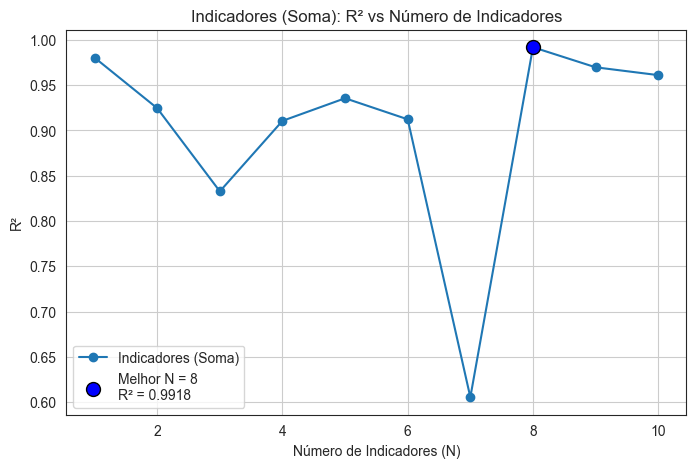

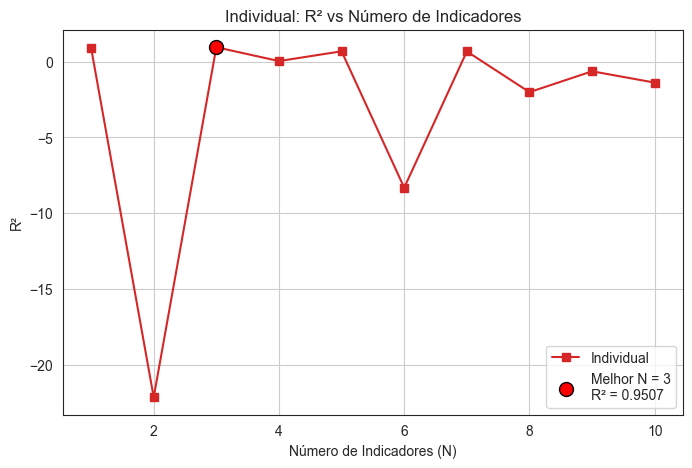

In [69]:
# Avaliar R² para diferentes números de indicadores
num_indicators_range = range(1, 11) # Intervalo de N (1 a 10)
r2_soma_list = []
r2_ind_list = []

# Salva a função show original
original_show = plt.show

print("Iniciando avaliação de R² para diferentes Ns...")

# Substitui plt.show por uma função vazia durante o loop
plt.show = lambda: None

for n_iter in num_indicators_range:
    print(f"Processando para N = {n_iter}...")
    
    # Chama a função - os gráficos internos não aparecerão
    resultados = executar_modelagem_richards_completa(
        new_df_brasil_wide=new_df_brasil_wide,
        population_col='Population, total',
        growth_col_for_corr='Population growth (annual %)',
        num_top_corr_indicators=n_iter,
        anos_para_projetar=8,
        test_size=0.2,
        random_state=42,
        plot=False  # Mantém o parâmetro, mesmo que não esteja funcionando
    )
    
    # Fecha qualquer figura que possa ter sido criada
    plt.close('all')
    
    # Coleta R² do modelo "Indicadores (Soma)" e do modelo "Individual"
    r2_soma_list.append(resultados['avaliacoes'][1]['R2'])
    r2_ind_list.append(resultados['avaliacoes'][2]['R2'])

# Restaura a função show original ANTES de plotar seus gráficos
plt.show = original_show

print("Avaliação de R² concluída.")

# Convertendo num_indicators_range em lista para plotagem e indexação
num_indicators_plot_list = list(num_indicators_range)

# Encontrando o melhor N para cada modelo
best_idx_soma = int(np.argmax(r2_soma_list))
best_n_soma = num_indicators_plot_list[best_idx_soma]
best_r2_soma = r2_soma_list[best_idx_soma]

best_idx_ind = int(np.argmax(r2_ind_list))
best_n_ind = num_indicators_plot_list[best_idx_ind]
best_r2_ind = r2_ind_list[best_idx_ind]

print(f"\nMelhor N para Indicadores (Soma): {best_n_soma} com R² = {best_r2_soma:.4f}")
print(f"Melhor N para Individual: {best_n_ind} com R² = {best_r2_ind:.4f}")

# Gráfico 1: Indicadores (Soma)
plt.figure(figsize=(8, 5))
plt.plot(num_indicators_plot_list, r2_soma_list, marker='o', label='Indicadores (Soma)')
plt.scatter([best_n_soma], [best_r2_soma], color='blue', s=100, edgecolors='k', zorder=5,
            label=f'Melhor N = {best_n_soma}\nR² = {best_r2_soma:.4f}')
plt.xlabel('Número de Indicadores (N)')
plt.ylabel('R²')
plt.title('Indicadores (Soma): R² vs Número de Indicadores')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Gráfico 2: Indicadores (Individual)
plt.figure(figsize=(8, 5))
plt.plot(num_indicators_plot_list, r2_ind_list, marker='s', label='Individual', color='tab:red')
plt.scatter([best_n_ind], [best_r2_ind], color='red', s=100, edgecolors='k', zorder=5,
            label=f'Melhor N = {best_n_ind}\nR² = {best_r2_ind:.4f}')
plt.xlabel('Número de Indicadores (N)')
plt.ylabel('R²')
plt.title('Individual: R² vs Número de Indicadores')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## K-fold cross validation def

In [70]:
def validacao_cruzada_rolante_soma(df, indicadores_selecionados, population_col='Population, total', 
                                   n_splits=5, min_train_size=10):
    
    df_limpo = df[indicadores_selecionados + [population_col]].dropna()
    anos = df_limpo.index.values.astype(float)
    X = anos - anos.min()
    y = df_limpo[population_col].values.astype(float)
    indicadores_raw = df_limpo[indicadores_selecionados].values.astype(float)
    
    if indicadores_raw.ndim == 1:
        indicadores_raw = indicadores_raw.reshape(-1, 1)
    
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=3)
    
    metricas_folds = {'MSE': [], 'RMSE': [], 'R2': []}
    fold_results = []
    
    print(f"Executando validação cruzada rolante com {n_splits} folds...")
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        if len(train_idx) < min_train_size:
            print(f"Fold {fold+1}: Poucos dados de treino ({len(train_idx)}), pulando...")
            continue
            
        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]
        indicadores_train_fold = indicadores_raw[train_idx]
        indicadores_test_fold = indicadores_raw[test_idx]
        
        scaler = StandardScaler()
        indicadores_train_scaled = scaler.fit_transform(indicadores_train_fold)
        indicadores_test_scaled = scaler.transform(indicadores_test_fold)
        
        try:
            params_fold, _ = ajustar_modelo_richards_com_indicadores(
                X_train_fold, y_train_fold, indicadores_train_scaled
            )
            
            y_pred_test_fold = modelo_richards_com_indicadores(
                X_test_fold, *params_fold, *indicadores_test_scaled.T.flatten()
            )
            
            mse = mean_squared_error(y_test_fold, y_pred_test_fold)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test_fold, y_pred_test_fold)
            
            metricas_folds['MSE'].append(mse)
            metricas_folds['RMSE'].append(rmse)
            metricas_folds['R2'].append(r2)
            
            fold_results.append({
                'fold': fold + 1,
                'train_size': len(train_idx),
                'test_size': len(test_idx),
                'train_years': f"{anos[train_idx].min():.0f}-{anos[train_idx].max():.0f}",
                'test_years': f"{anos[test_idx].min():.0f}-{anos[test_idx].max():.0f}",
                'MSE': mse,
                'RMSE': rmse,
                'R2': r2,
                'params': params_fold,
                'y_true': y_test_fold,
                'y_pred': y_pred_test_fold,
                'anos_test': anos[test_idx]
            })
            
            print(f"Fold {fold+1}: MSE={mse:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")
            
        except Exception as e:
            print(f"Erro no fold {fold+1}: {e}")
            continue
    
    if not metricas_folds['MSE']:
        print("Nenhum fold foi executado com sucesso!")
        return None
    
    estatisticas = {}
    for metrica in ['MSE', 'RMSE', 'R2']:
        valores = np.array(metricas_folds[metrica])
        estatisticas[metrica] = {
            'media': np.mean(valores),
            'std': np.std(valores),
            'min': np.min(valores),
            'max': np.max(valores),
            'valores': valores
        }
    
    print("\n=== RESUMO DA VALIDAÇÃO CRUZADA ROLANTE ===")
    print(f"Número de folds executados: {len(metricas_folds['MSE'])}")
    for metrica in ['MSE', 'RMSE', 'R2']:
        stats = estatisticas[metrica]
        print(f"{metrica}: {stats['media']:.4f} ± {stats['std']:.4f} (min: {stats['min']:.4f}, max: {stats['max']:.4f})")
    
    plotar_resultados_cv(fold_results, estatisticas)
    
    return {
        'estatisticas': estatisticas,
        'fold_results': fold_results,
        'metricas_por_fold': metricas_folds
    }

def plotar_resultados_cv(fold_results, estatisticas):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    axes[0,0].boxplot([estatisticas['MSE']['valores'], 
                       estatisticas['RMSE']['valores'], 
                       estatisticas['R2']['valores']], 
                      labels=['MSE', 'RMSE', 'R²'])
    axes[0,0].set_title('Distribuição das Métricas por Fold')
    axes[0,0].grid(True, alpha=0.3)
    
    folds = [r['fold'] for r in fold_results]
    r2_values = [r['R2'] for r in fold_results]
    axes[0,1].plot(folds, r2_values, 'o-', linewidth=2, markersize=8)
    axes[0,1].axhline(y=estatisticas['R2']['media'], color='red', linestyle='--', 
                      label=f"Média: {estatisticas['R2']['media']:.4f}")
    axes[0,1].fill_between(folds, 
                           estatisticas['R2']['media'] - estatisticas['R2']['std'],
                           estatisticas['R2']['media'] + estatisticas['R2']['std'],
                           alpha=0.2, color='red')
    axes[0,1].set_title('R² por Fold')
    axes[0,1].set_xlabel('Fold')
    axes[0,1].set_ylabel('R²')
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].legend()
    
    for i, resultado in enumerate(fold_results[:3]):
        axes[1,0].scatter(resultado['anos_test'], resultado['y_true'], 
                         label=f'Fold {resultado["fold"]} - Observado', alpha=0.7)
        axes[1,0].plot(resultado['anos_test'], resultado['y_pred'], 
                      label=f'Fold {resultado["fold"]} - Predito', linewidth=2)
    axes[1,0].set_title('Predições vs Observado (Primeiros 3 Folds)')
    axes[1,0].set_xlabel('Ano')
    axes[1,0].set_ylabel('População')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    all_true = np.concatenate([r['y_true'] for r in fold_results])
    all_pred = np.concatenate([r['y_pred'] for r in fold_results])
    axes[1,1].scatter(all_true, all_pred, alpha=0.6)
    min_val, max_val = min(all_true.min(), all_pred.min()), max(all_true.max(), all_pred.max())
    axes[1,1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[1,1].set_title('Predito vs Observado (Todos os Folds)')
    axes[1,1].set_xlabel('Observado')
    axes[1,1].set_ylabel('Predito')
    axes[1,1].grid(True, alpha=0.3)
    
    r2_total = r2_score(all_true, all_pred)
    axes[1,1].text(0.05, 0.95, f'R² Total: {r2_total:.4f}', 
                   transform=axes[1,1].transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def validacao_cruzada_rolante_individual(df, indicadores_selecionados, population_col='Population, total',
                                     n_splits=5, min_train_size=10):

    df_limpo = df[indicadores_selecionados + [population_col]].dropna()
    if df_limpo.empty or len(df_limpo) < n_splits + min_train_size -1 : # Checagem básica de dados suficientes
        print("Dados insuficientes após limpeza ou para o número de splits e tamanho mínimo de treino.")
        return None

    anos = df_limpo.index.values.astype(float)
    X = anos - anos.min()
    y = df_limpo[population_col].values.astype(float)
    indicadores_raw = df_limpo[indicadores_selecionados].values.astype(float)

    if indicadores_raw.ndim == 1:
        indicadores_raw = indicadores_raw.reshape(-1, 1)

    num_indicator_features = indicadores_raw.shape[1]

    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=3) # test_size=3 como no seu original

    metricas_folds = {'MSE': [], 'RMSE': [], 'R2': []}
    fold_results = []

    print(f"Executando validação cruzada rolante (Individual, n={num_indicator_features}) com {n_splits} folds...")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        if len(train_idx) < min_train_size:
            print(f"Fold {fold+1}: Poucos dados de treino ({len(train_idx)}), pulando...")
            continue

        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]
        indicadores_train_fold = indicadores_raw[train_idx]
        indicadores_test_fold = indicadores_raw[test_idx]

        scaler = StandardScaler()
        indicadores_train_scaled = scaler.fit_transform(indicadores_train_fold)
        indicadores_test_scaled = scaler.transform(indicadores_test_fold)

        try:
            # Ajusta o modelo Richards Individual
            # A função ajustar_modelo_richards_individual retorna todos os parâmetros concatenados
            # (4 base + 4*num_features coeficientes)
            params_fold, _ = ajustar_modelo_richards_individual(
                X_train_fold, y_train_fold, indicadores_train_scaled
            )

            # Prepara os dados para a predição
            base_params_fold = params_fold[:4]
            coefs_indic_fold = params_fold[4:]
            indicadores_test_scaled_flat = indicadores_test_scaled.T.flatten()

            y_pred_test_fold = modelo_richards_individual(
                X_test_fold,
                *base_params_fold, # K_base, r_base, v_base, t0_base
                indicadores_test_scaled_flat,
                coefs_indic_fold,
                num_indicator_features
            )

            mse = mean_squared_error(y_test_fold, y_pred_test_fold)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test_fold, y_pred_test_fold)

            metricas_folds['MSE'].append(mse)
            metricas_folds['RMSE'].append(rmse)
            metricas_folds['R2'].append(r2)

            fold_results.append({
                'fold': fold + 1,
                'train_size': len(train_idx),
                'test_size': len(test_idx),
                'train_years': f"{anos[train_idx].min():.0f}-{anos[train_idx].max():.0f}",
                'test_years': f"{anos[test_idx].min():.0f}-{anos[test_idx].max():.0f}",
                'MSE': mse,
                'RMSE': rmse,
                'R2': r2,
                'params': params_fold, # Armazena todos os parâmetros
                'y_true': y_test_fold,
                'y_pred': y_pred_test_fold,
                'anos_test': anos[test_idx]
            })

            print(f"Fold {fold+1}: MSE={mse:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")

        except Exception as e:
            print(f"Erro no fold {fold+1}: {e}")
            # continue # Comente ou remova se quiser que o erro pare a execução

    if not metricas_folds['MSE']:
        print("Nenhum fold foi executado com sucesso!")
        return None

    estatisticas = {}
    for metrica in ['MSE', 'RMSE', 'R2']:
        valores = np.array(metricas_folds[metrica])
        if len(valores) == 0: # Checagem para evitar erro com np.mean de array vazio
             estatisticas[metrica] = {'media': np.nan, 'std': np.nan, 'min': np.nan, 'max': np.nan, 'valores': valores}
        else:
            estatisticas[metrica] = {
                'media': np.mean(valores),
                'std': np.std(valores),
                'min': np.min(valores),
                'max': np.max(valores),
                'valores': valores
            }

    print("\n=== RESUMO DA VALIDAÇÃO CRUZADA ROLANTE (INDIVIDUAL) ===")
    print(f"Número de folds executados: {len(metricas_folds['MSE'])}")
    for metrica in ['MSE', 'RMSE', 'R2']:
        stats = estatisticas[metrica]
        print(f"{metrica}: {stats['media']:.4f} ± {stats['std']:.4f} (min: {stats['min']:.4f}, max: {stats['max']:.4f})")

    # A função plotar_resultados_cv pode ser usada como está,
    # pois ela é genérica em relação aos resultados dos folds.
    if any(len(v) > 0 for v in metricas_folds.values()): # Plota apenas se houver resultados
        plotar_resultados_cv(fold_results, estatisticas)


    return {
        'estatisticas': estatisticas,
        'fold_results': fold_results,
        'metricas_por_fold': metricas_folds
    }

def validacao_cruzada_basico(
    df,
    population_col: str = "Population, total",
    n_splits: int = 5,
    min_train_size: int = 10,
):
    
    df_limpo = df[[population_col]].dropna()
    if df_limpo.empty or len(df_limpo) < n_splits + min_train_size - 1:
        print("Dados insuficientes após limpeza ou para a quantidade de folds.")
        return None

    anos = df_limpo.index.values.astype(float)
    X = anos - anos.min()  # desloca para começar em 0
    y = df_limpo[population_col].values.astype(float)

    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=3)

    metricas_folds = {"MSE": [], "RMSE": [], "R2": []}
    fold_results = []

    print(
        f"Executando validação cruzada rolante (Básico) "
        f"com {n_splits} folds..."
    )

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        if len(train_idx) < min_train_size:
            print(
                f"Fold {fold + 1}: "
                f"apenas {len(train_idx)} dados de treino (mínimo = {min_train_size}), pulando..."
            )
            continue

        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]

        try:
            # Ajuste do modelo de Richards BÁSICO -------------------------
            params_fold, _ = ajustar_modelo_richards_basico(
                X_train_fold, y_train_fold
            )

            y_pred_test_fold = modelo_richards(
                X_test_fold, *params_fold  # K, r, v, t0
            )

            # Métricas ----------------------------------------------------
            mse = mean_squared_error(y_test_fold, y_pred_test_fold)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test_fold, y_pred_test_fold)

            metricas_folds["MSE"].append(mse)
            metricas_folds["RMSE"].append(rmse)
            metricas_folds["R2"].append(r2)

            fold_results.append(
                {
                    "fold": fold + 1,
                    "train_size": len(train_idx),
                    "test_size": len(test_idx),
                    "train_years": f"{anos[train_idx].min():.0f}-{anos[train_idx].max():.0f}",
                    "test_years": f"{anos[test_idx].min():.0f}-{anos[test_idx].max():.0f}",
                    "MSE": mse,
                    "RMSE": rmse,
                    "R2": r2,
                    "params": params_fold,
                    "y_true": y_test_fold,
                    "y_pred": y_pred_test_fold,
                    "anos_test": anos[test_idx],
                }
            )

            print(
                f"Fold {fold + 1}:  "
                f"MSE = {mse:.2f},  RMSE = {rmse:.2f},  R² = {r2:.4f}"
            )

        except Exception as e:
            print(f"Erro no fold {fold + 1}: {e}")

    if not metricas_folds["MSE"]:
        print("Nenhum fold foi executado com sucesso!")
        return None

    estatisticas = {}
    for metrica in ["MSE", "RMSE", "R2"]:
        valores = np.array(metricas_folds[metrica])
        estatisticas[metrica] = {
            "media": np.mean(valores) if valores.size else np.nan,
            "std": np.std(valores) if valores.size else np.nan,
            "min": np.min(valores) if valores.size else np.nan,
            "max": np.max(valores) if valores.size else np.nan,
            "valores": valores,
        }

    print("\n=== RESUMO DA VALIDAÇÃO CRUZADA ROLANTE (BÁSICO) ===")
    print(f"Número de folds executados: {len(metricas_folds['MSE'])}")
    for metrica in ["MSE", "RMSE", "R2"]:
        stats = estatisticas[metrica]
        print(
            f"{metrica}: {stats['media']:.4f} ± {stats['std']:.4f} "
            f"(min: {stats['min']:.4f}, max: {stats['max']:.4f})"
        )


    if any(len(v) > 0 for v in metricas_folds.values()):
        plotar_resultados_cv(fold_results, estatisticas)

    return {
        "estatisticas": estatisticas,
        "fold_results": fold_results,
        "metricas_por_fold": metricas_folds,
    }


Executando validação cruzada rolante (Básico) com 5 folds...
Fold 1:  MSE = 9085304265.71,  RMSE = 95316.86,  R² = 0.9947
Fold 2:  MSE = 16635145271.40,  RMSE = 128977.31,  R² = 0.9903
Fold 3:  MSE = 343206752698.53,  RMSE = 585838.50,  R² = 0.7754
Fold 4:  MSE = 401648446360.22,  RMSE = 633757.40,  R² = 0.6308
Fold 5:  MSE = 121577350416.58,  RMSE = 348679.44,  R² = 0.7118

=== RESUMO DA VALIDAÇÃO CRUZADA ROLANTE (BÁSICO) ===
Número de folds executados: 5
MSE: 178430599802.4896 ± 164356489241.0297 (min: 9085304265.7130, max: 401648446360.2166)
RMSE: 358513.9026 ± 223379.4562 (min: 95316.8624, max: 633757.4034)
R2: 0.8206 ± 0.1476 (min: 0.6308, max: 0.9947)


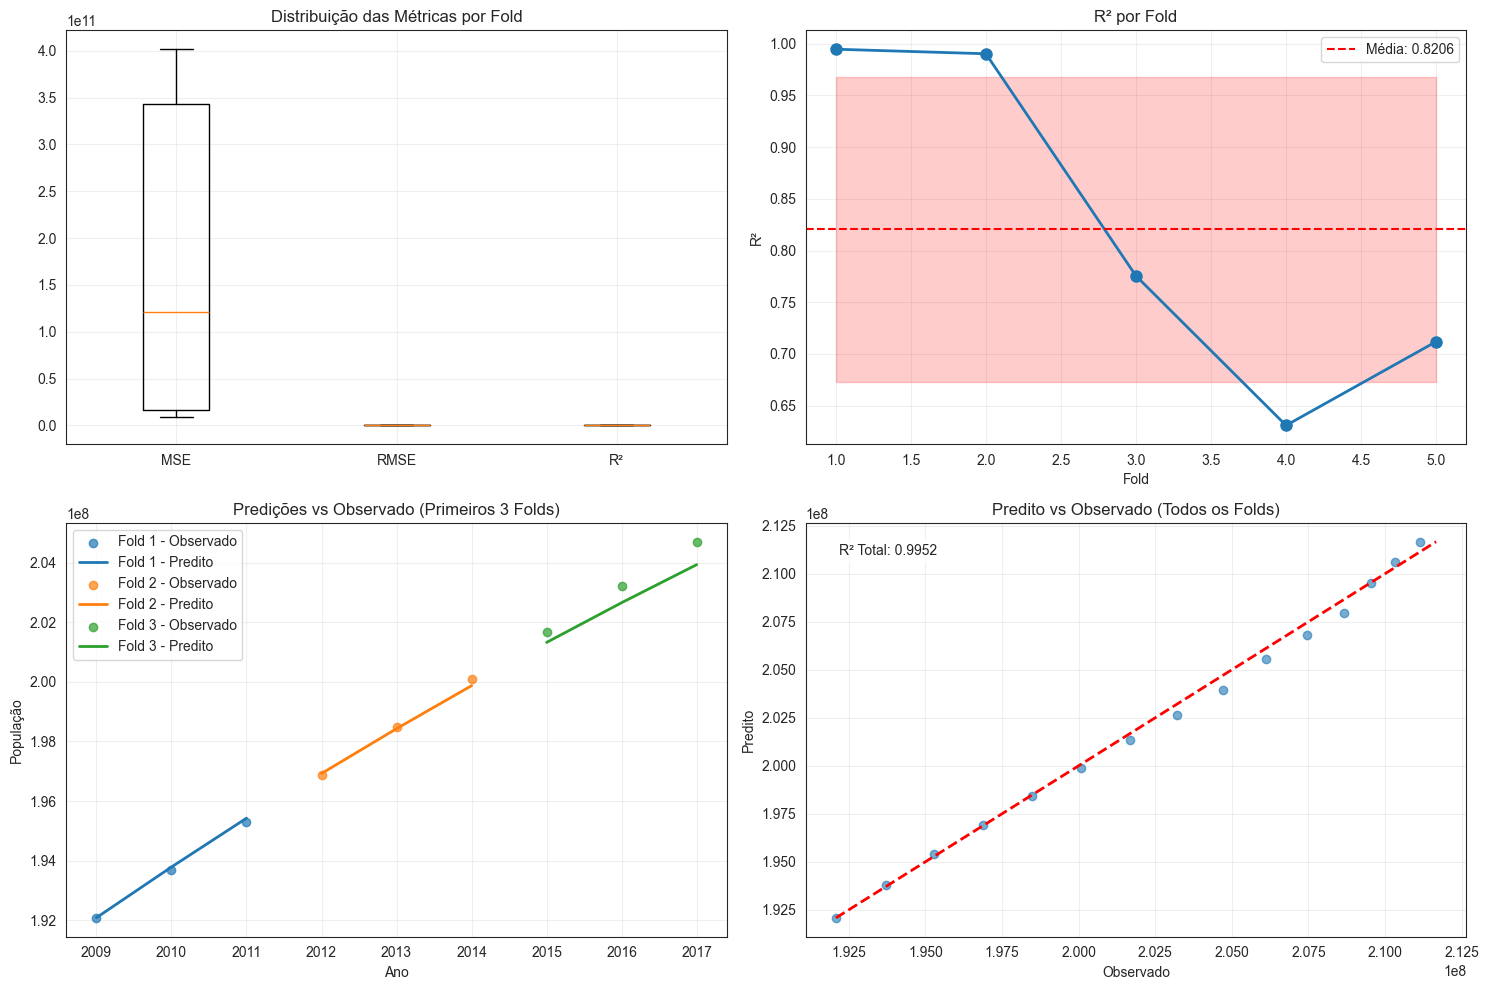

In [71]:
resultados_cv_basico = validacao_cruzada_basico(
    df=new_df_brasil_wide,      # seu DataFrame indexado por ano
    population_col="Population, total",  # nome da coluna de população
    n_splits=5,                 # quantidade de folds (opcional; default=5)
    min_train_size=10           # tamanho mínimo do bloco de treino (opcional)
)


## N = 3

=== MODELAGEM COM TRÊS VERSÕES DE RICHARDS (TRAIN-TEST SPLIT COM SELEÇÃO RIGOROSA) ===
Indicadores selecionados com maior correlação com 'Population growth (annual %)' (usando apenas treino):
 - Adjusted net national income (constant 2015 US$): correlação = -0.9600
 - Net secondary income (BoP, current US$): correlação = -0.9127
 - Grants, excluding technical cooperation (BoP, current US$): correlação = -0.9063

Ajustando modelo básico...
Ajustando modelo com indicadores (efeito somado)...
Ajustando modelo com coeficientes individuais por indicador...
Ajustando Individual com 3 indicadores...

Avaliação do modelo Básico:
MSE: 852444874965.72
RMSE: 923279.41
R²: 0.9492

Avaliação do modelo Indicadores (Soma):
MSE: 2806263761586.46
RMSE: 1675190.66
R²: 0.8327

Avaliação do modelo Individual:
MSE: 826250456438.63
RMSE: 908983.20
R²: 0.9507


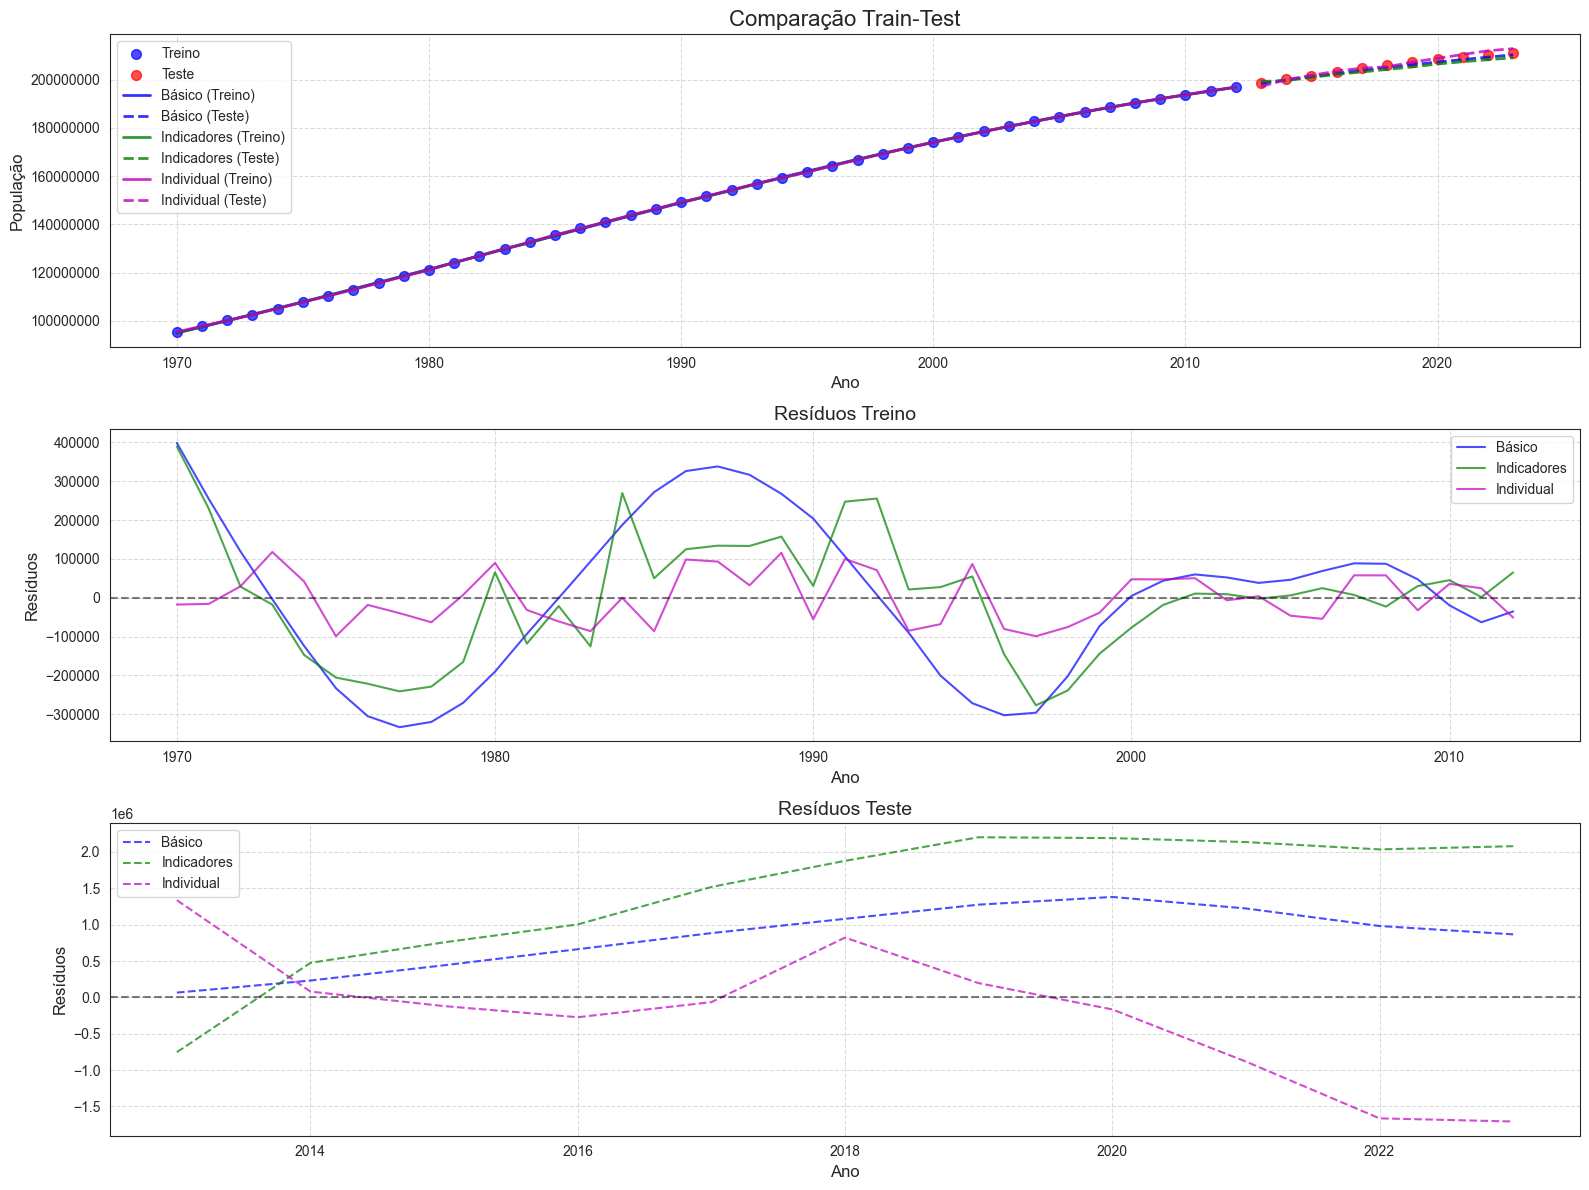

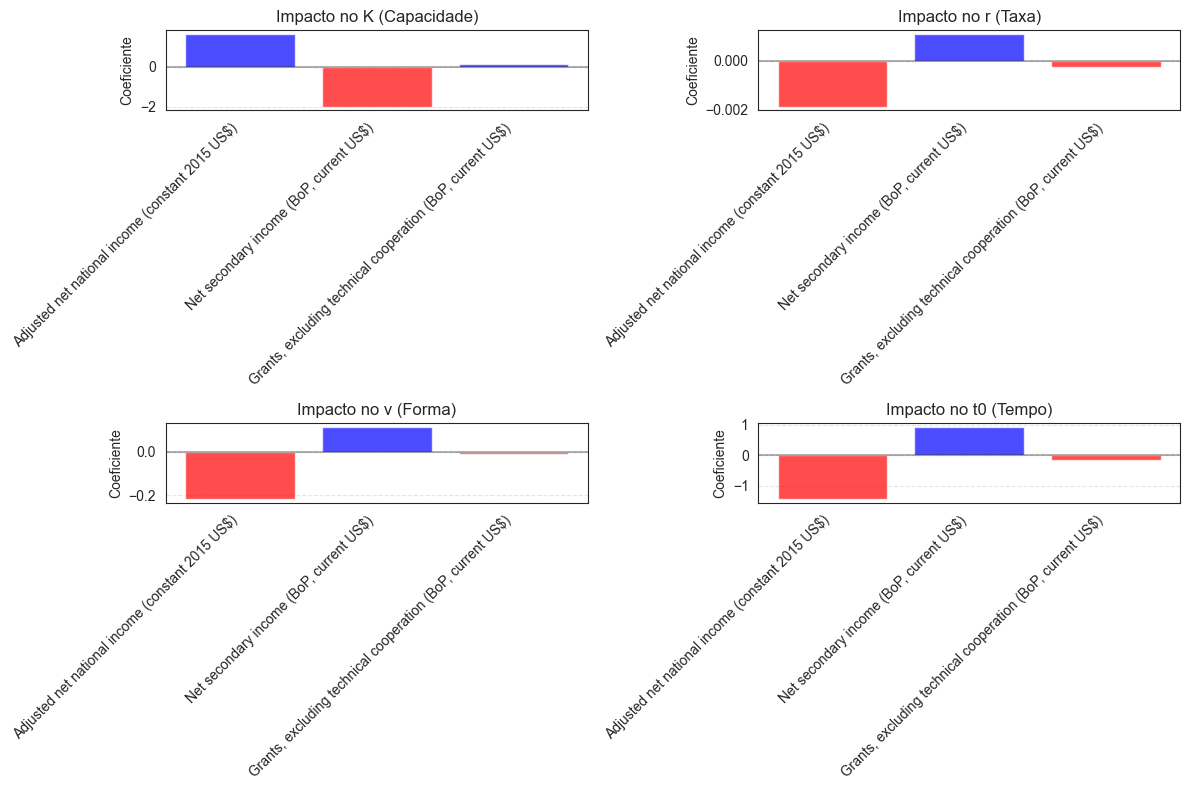


Realizando projeções...

Projeções para os próximos anos:
Ano   Básico         Indic. Soma    Individual     
---------------------------------------------------
2013.0   198,413,011   198,192,830   198,907,945
2014.0   199,853,650   199,551,839   200,532,519
2015.0   201,234,246   200,846,505   202,108,150
2016.0   202,555,931   202,078,916   203,635,507
2017.0   203,819,954   203,251,195   205,115,314
2018.0   205,027,670   204,365,490   206,548,344
2019.0   206,180,521   205,423,959   207,935,414
2020.0   207,280,023   206,428,755   209,277,380


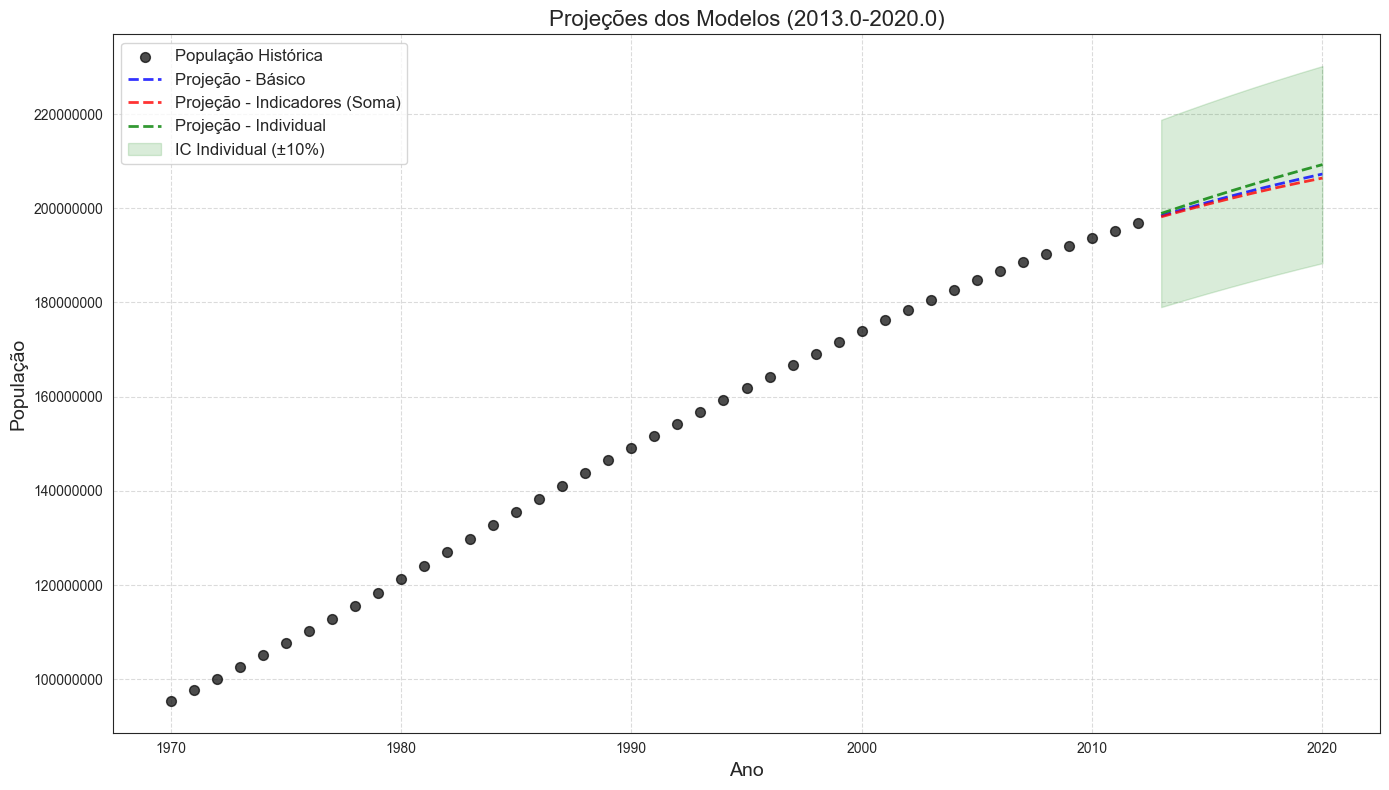

In [72]:
resultados_modelagem = executar_modelagem_richards_completa(
    new_df_brasil_wide=new_df_brasil_wide,
    population_col='Population, total',
    growth_col_for_corr='Population growth (annual %)',
    num_top_corr_indicators=3,      # pode ajustar a quantidade de indicadores para o modelo de soma
    anos_para_projetar=8,       # pode ajustar a quantidade de anos futuros para projetar
    test_size=0.2,               # fração dos dados usada para teste
    random_state=42              # para reprodutibilidade do split
)



### K-fold cross validation individual com n= 3


In [73]:
indicadores_selecionados_n3 = [
    "Adjusted net national income (constant 2015 US$)",
    "Net secondary income (BoP, current US$)",
    "Grants, excluding technical cooperation (BoP, current US$)"
    ]

Executando validação cruzada rolante (Individual, n=3) com 5 folds...
Ajustando Individual com 3 indicadores...
⚠️ Erro no ajuste individual: Optimal parameters not found: The maximum number of function evaluations is exceeded.. Usando p0.
Fold 1: MSE=3856102411298089.50, RMSE=62097523.39, R²=-2251.5836
Ajustando Individual com 3 indicadores...
Fold 2: MSE=64168071366325.27, RMSE=8010497.57, R²=-36.3875
Ajustando Individual com 3 indicadores...
Fold 3: MSE=1900587655861.44, RMSE=1378618.02, R²=-0.2437
Ajustando Individual com 3 indicadores...
Fold 4: MSE=168880964810.53, RMSE=410951.29, R²=0.8448
Ajustando Individual com 3 indicadores...
Fold 5: MSE=87529031547.88, RMSE=295853.06, R²=0.7925

=== RESUMO DA VALIDAÇÃO CRUZADA ROLANTE (INDIVIDUAL) ===
Número de folds executados: 5
MSE: 784485496063327.0000 ± 1536005177631165.5000 (min: 87529031547.8793, max: 3856102411298089.5000)
RMSE: 14438688.6675 ± 24000203.4497 (min: 295853.0574, max: 62097523.3910)
R2: -457.3155 ± 897.2477 (min: -225

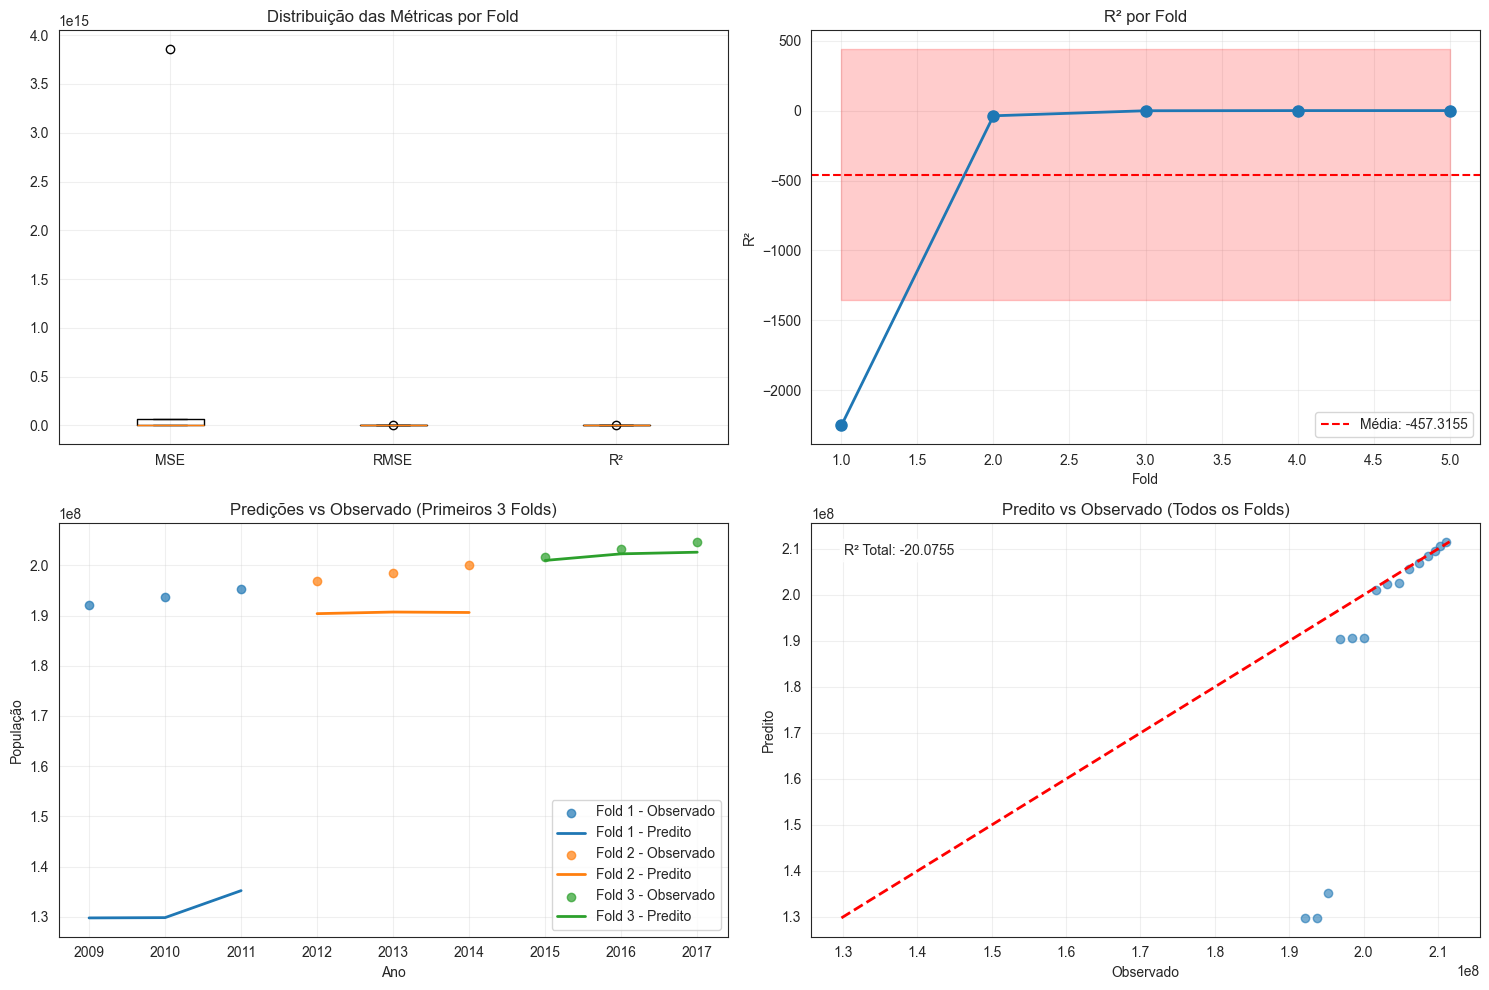

In [74]:
resultados_cv_individual_3 = validacao_cruzada_rolante_individual(
    df=new_df_brasil_wide,
    indicadores_selecionados= indicadores_selecionados_n3,
    population_col='Population, total',
    n_splits=5  
    )

### K-fold cross validation soma com n= 3


Executando validação cruzada rolante com 5 folds...
Fold 1: MSE=19552539860.74, RMSE=139830.40, R²=0.9886
Fold 2: MSE=350576047486.30, RMSE=592094.63, R²=0.7957
Fold 3: MSE=503090386407.37, RMSE=709288.65, R²=0.6708
Fold 4: MSE=293849507895.91, RMSE=542078.88, R²=0.7299
Fold 5: MSE=162634229777.75, RMSE=403279.34, R²=0.6145

=== RESUMO DA VALIDAÇÃO CRUZADA ROLANTE ===
Número de folds executados: 5
MSE: 265940542285.6125 ± 164658051495.7462 (min: 19552539860.7363, max: 503090386407.3707)
RMSE: 477314.3785 ± 195221.7363 (min: 139830.3968, max: 709288.6482)
R2: 0.7599 ± 0.1293 (min: 0.6145, max: 0.9886)


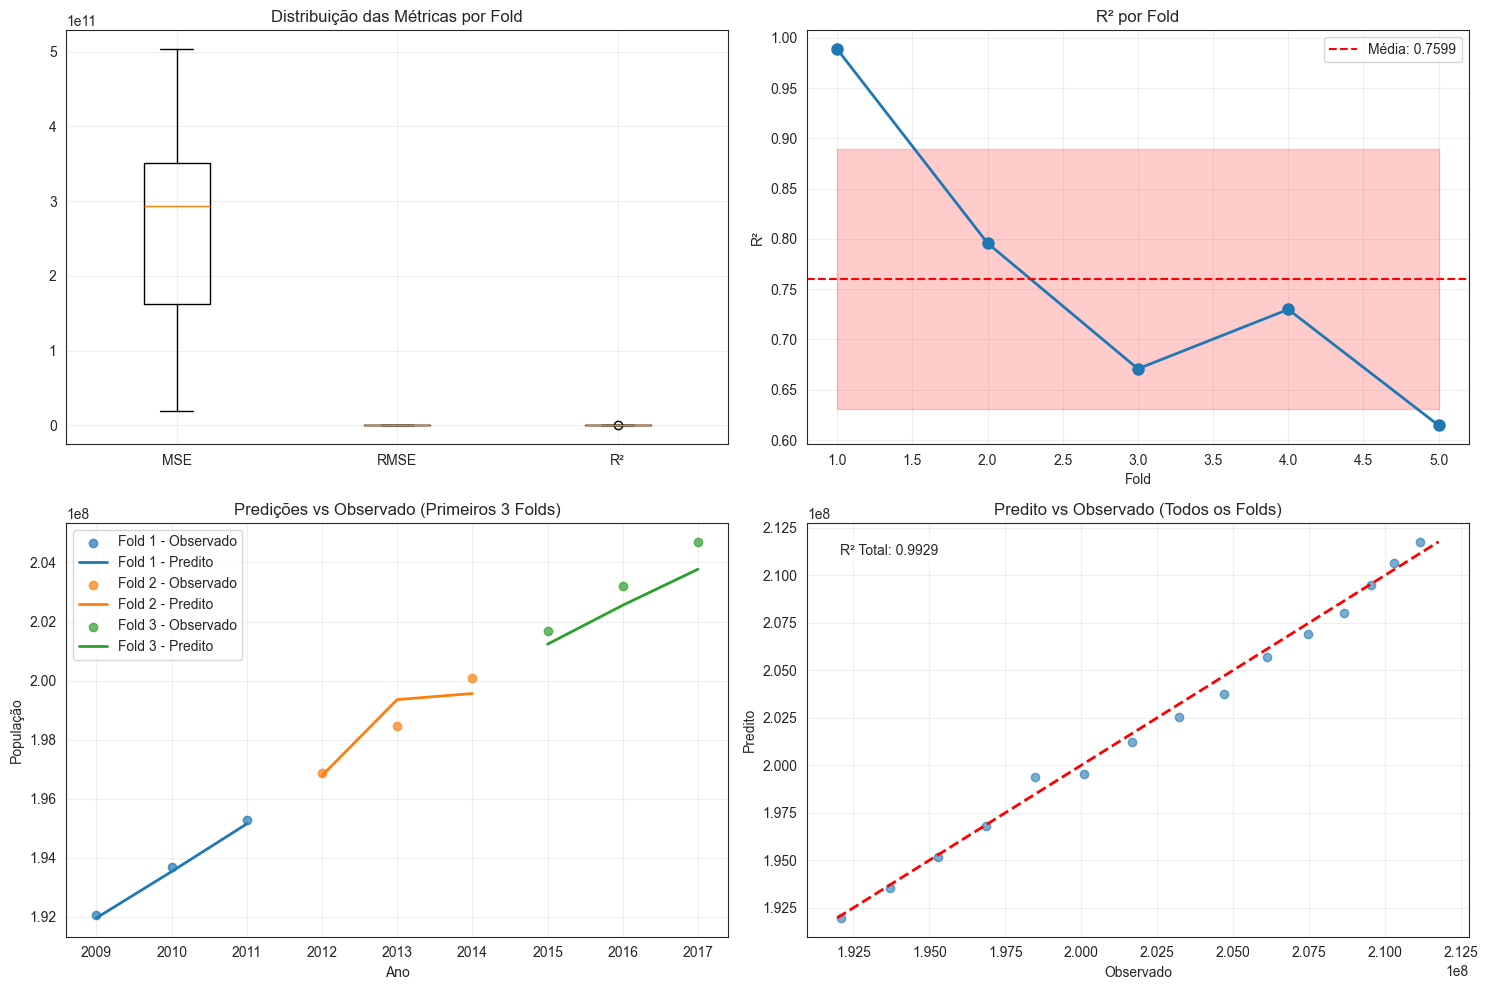

In [75]:
resultados_cv_soma_3 = validacao_cruzada_rolante_soma(
    df=new_df_brasil_wide,
    indicadores_selecionados= indicadores_selecionados_n3,
    population_col='Population, total',
    n_splits=5  
    )

Analisando o modelo: <function modelo_richards_com_indicadores at 0x00000218633DF2E0>
Total de Folds executados: 5

=== 1. RESUMO DAS MÉTRICAS POR FOLD ===
 Fold Anos Treino Anos Teste  N Treino  N Teste       RMSE    R²
    1   1970-2008  2009-2011        39        3 139830.397 0.989
    2   1970-2011  2012-2014        42        3 592094.627 0.796
    3   1970-2014  2015-2017        45        3 709288.648 0.671
    4   1970-2017  2018-2020        48        3 542078.876 0.730
    5   1970-2020  2021-2023        51        3 403279.345 0.615

--- MAPE (%) por fold ---
 Fold  MAPE_%
    1   0.071
    2   0.250
    3   0.334
    4   0.257
    5   0.155

=== 2. ANÁLISE DETALHADA DE UM FOLD ESPECÍFICO ===
--- Foco no Fold 4: Treino 1970-2017 → Teste 2018-2020 ---
   Ano        Real     Predito    Erro Erro_%
2018.0 206,107,261 205,691,539 415,722  0.20%
2019.0 207,455,459 206,905,371 550,088  0.27%
2020.0 208,660,842 208,023,561 637,281  0.31%


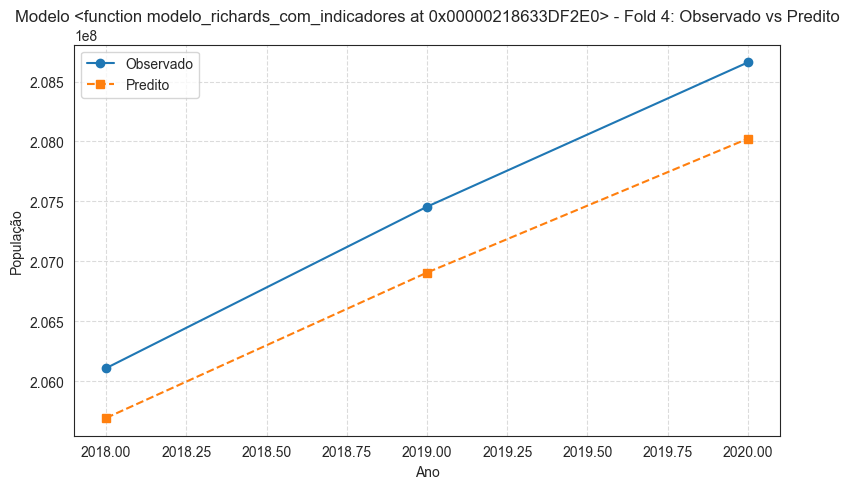


--- Indicadores (Fold 4 - Anos de Teste) ---
Indicator Name  Adjusted net national income (constant 2015 US$)  Net secondary income (BoP, current US$)  Grants, excluding technical cooperation (BoP, current US$)
Year                                                                                                                                                                 
2018                                                1.358081e+12                            -1.502089e+07                                                 255550000.0
2019                                                1.375689e+12                             1.184145e+09                                                 172680000.0
2020                                                1.339284e+12                             2.343875e+09                                                 279930000.0

=== 3. ANÁLISE DA ESTABILIDADE DOS PARÂMETROS ===

--- Parâmetros Richards (<function modelo_richards_com_indicadores at 0x

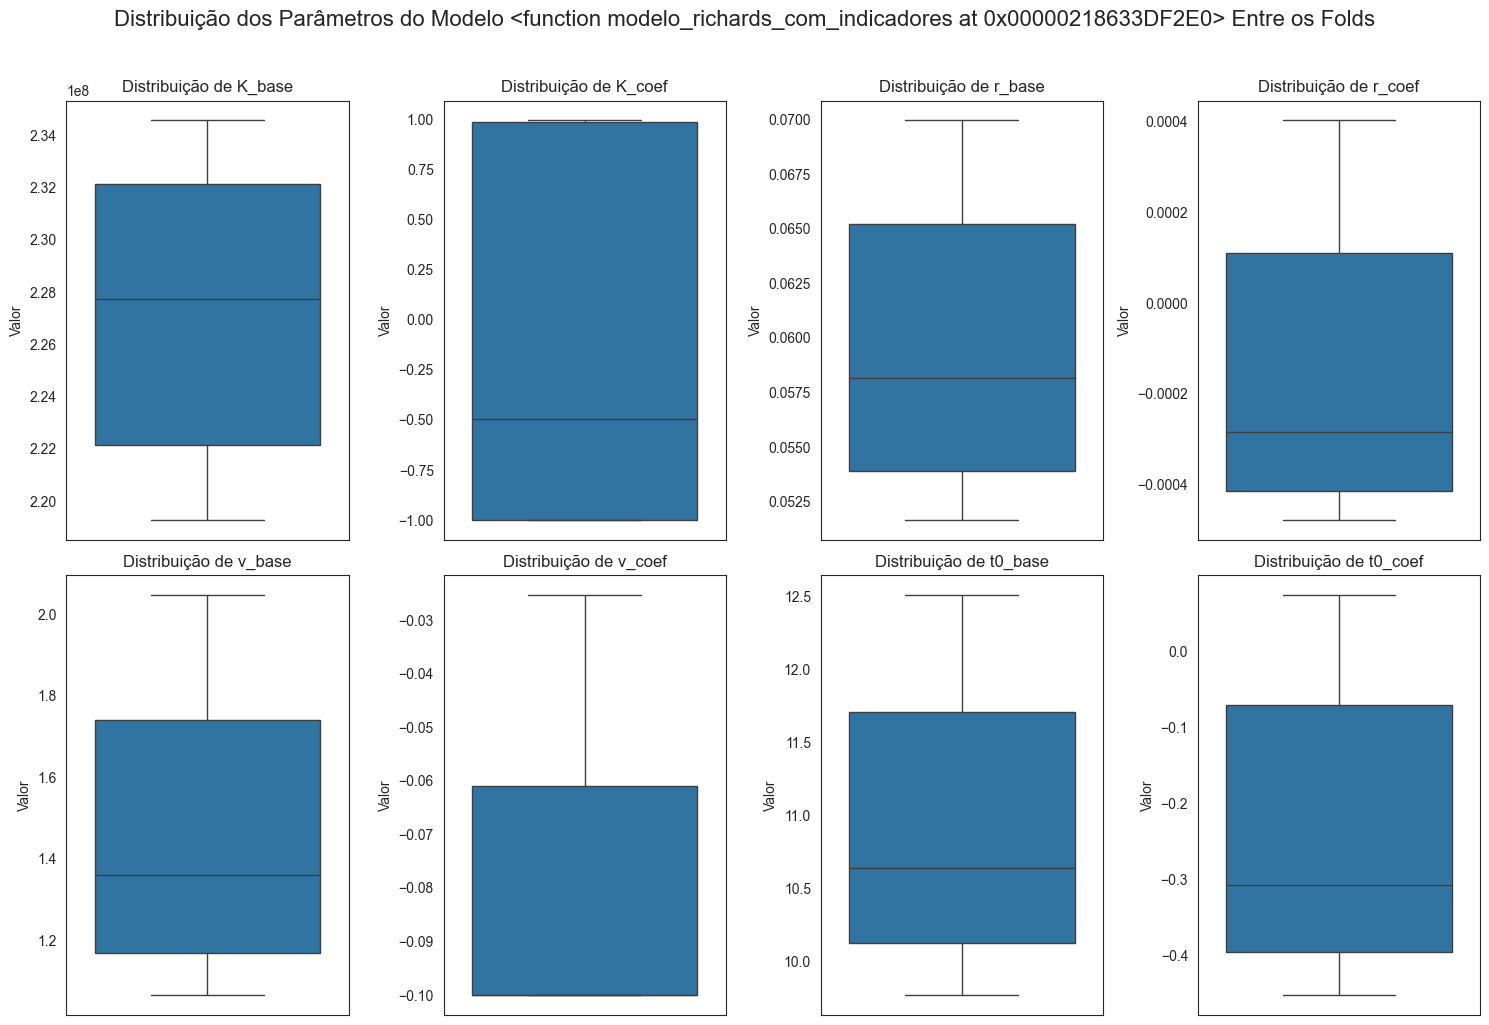


=== ANÁLISE DETALHADA CONCLUÍDA ===


In [76]:
if resultados_cv_soma_3 is None:
    raise ValueError("Variável 'resultados_cv_atual' não contém resultados. Verifique a configuração.")

fold_results = resultados_cv_soma_3['fold_results']
if not fold_results:
    raise ValueError("A lista 'fold_results' está vazia. Verifique os resultados da validação cruzada.")

print(f"Analisando o modelo: {modelo_richards_com_indicadores}")
print(f"Total de Folds executados: {len(fold_results)}")

# ----------------------------------------------------------------------
# 1) RESUMO DAS MÉTRICAS POR FOLD
# ----------------------------------------------------------------------
print("\n=== 1. RESUMO DAS MÉTRICAS POR FOLD ===")
tbl_fold = pd.DataFrame(
    [(f['fold'],
      f['train_years'], f['test_years'],
      f['train_size'], f['test_size'],
      f['RMSE'], f['R2']) for f in fold_results],
    columns=['Fold', 'Anos Treino', 'Anos Teste', 'N Treino', 'N Teste', 'RMSE', 'R²']
)
print(tbl_fold.to_string(index=False, float_format="%.3f"))

# Adicionar MAPE à tabela de resumo
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Evitar divisão por zero se y_true tiver zeros. Considerar pequena constante ou remover esses pontos.
    # Para população, y_true raramente será zero, mas é bom ter cuidado.
    mask = y_true != 0
    if not np.all(mask):
        print("Aviso: Encontrados valores zero em y_true para cálculo do MAPE. Esses pontos serão ignorados.")
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

try:
    tbl_fold['MAPE_%'] = [mape(fr['y_true'], fr['y_pred']) for fr in fold_results]
    print("\n--- MAPE (%) por fold ---")
    print(tbl_fold[['Fold','MAPE_%']].to_string(index=False, float_format="%.3f"))
except Exception as e:
    print(f"Erro ao calcular MAPE: {e}")


# ----------------------------------------------------------------------
# 2) ANÁLISE DETALHADA DE UM FOLD ESPECÍFICO
# ----------------------------------------------------------------------
print("\n=== 2. ANÁLISE DETALHADA DE UM FOLD ESPECÍFICO ===")
fold_id_analise = 4 # Ou escolha o fold com pior/melhor R², ou itere por todos
try:
    fold_data = next(fr for fr in fold_results if fr['fold'] == fold_id_analise)
except StopIteration:
    print(f"AVISO: Fold {fold_id_analise} não encontrado. Usando o último fold disponível.")
    if fold_results:
        fold_data = fold_results[-1]
        fold_id_analise = fold_data['fold']
    else:
        fold_data = None

if fold_data:
    print(f"--- Foco no Fold {fold_id_analise}: Treino {fold_data['train_years']} → Teste {fold_data['test_years']} ---")
    df_fold_analise = pd.DataFrame({
        'Ano': fold_data['anos_test'],
        'Real': fold_data['y_true'],
        'Predito': fold_data['y_pred']
    })
    df_fold_analise['Erro'] = df_fold_analise['Real'] - df_fold_analise['Predito']
    df_fold_analise['Erro_%'] = (df_fold_analise['Erro'] / df_fold_analise['Real']) * 100
    print(df_fold_analise.to_string(index=False, formatters={'Real':'{:,.0f}'.format, 'Predito':'{:,.0f}'.format, 'Erro':'{:,.0f}'.format, 'Erro_%':'{:.2f}%'.format}))

    # Gráfico do Fold específico
    plt.figure(figsize=(8, 5)) # Ajuste no tamanho
    plt.plot(df_fold_analise['Ano'], df_fold_analise['Real'], 'o-', label='Observado', markersize=6)
    plt.plot(df_fold_analise['Ano'], df_fold_analise['Predito'], 's--', label='Predito', markersize=6)
    # Linha de média apenas se fizer sentido (ex: para avaliar R² visualmente)
    # plt.axhline(df_fold_analise['Real'].mean(), color='gray', ls=':', alpha=0.5, label='Média Observado (Teste)')
    plt.title(f'Modelo {modelo_richards_com_indicadores} - Fold {fold_id_analise}: Observado vs Predito')
    plt.ylabel('População')
    plt.xlabel('Ano')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Indicadores do Fold específico
    print(f"\n--- Indicadores (Fold {fold_id_analise} - Anos de Teste) ---")
    try:
        # Certifique-se que 'new_df_brasil_wide' e 'indicadores_selecionados_atuais' estão definidos e corretos
        indic_fold_analise = new_df_brasil_wide.loc[df_fold_analise['Ano'], indicadores_selecionados_n3]
        print(indic_fold_analise.round(2).to_string())
    except Exception as e:
        print(f"Erro ao extrair indicadores para o fold: {e}")
        print("Verifique se 'new_df_brasil_wide' e 'indicadores_selecionados_atuais' estão corretos.")

# ----------------------------------------------------------------------
# 3) ANÁLISE DA ESTABILIDADE DOS PARÂMETROS
# ----------------------------------------------------------------------
print("\n=== 3. ANÁLISE DA ESTABILIDADE DOS PARÂMETROS ===")
# Para o modelo de Soma, sempre teremos 8 parâmetros.
# Se fosse o Individual, teríamos 4 + 4*num_indicadores.
# O nome 'param_cols' pode ser mantido, pois o modelo de Soma sempre retorna esses 8.
param_cols = ["K_base", "K_coef", "r_base", "r_coef", "v_base", "v_coef", "t0_base", "t0_coef"]

# Verificar se há parâmetros em fold_results e se têm o tamanho esperado
if fold_results and 'params' in fold_results[0] and len(fold_results[0]['params']) >= len(param_cols):
    df_params = pd.DataFrame([
        dict(zip(['Fold'] + param_cols, [fr['fold']] + list(fr['params'][:len(param_cols)])))
        for fr in fold_results if 'params' in fr # Checagem adicional
    ])

    if not df_params.empty:
        print(f"\n--- Parâmetros Richards ({modelo_richards_com_indicadores}) por Fold ---")
        print(df_params.to_string(index=False, float_format="%.5g")) # Usar 'g' para notação científica se necessário

        # Coeficiente de Variação (CV %)
        # Evitar divisão por zero ou por média muito próxima de zero para parâmetros que podem ser zero (ex: coeficientes)
        # Adicionar uma pequena constante ao denominador se a média for muito pequena e o std não for zero.
        std_devs = df_params[param_cols].std()
        means = df_params[param_cols].mean()
        # CV_percent = (std_devs / means).abs() * 100 # abs() para o caso de média negativa
        # Lidar com médias zero ou próximas de zero para evitar CVs infinitos ou NaN
        CV_percent = pd.Series(index=param_cols, dtype=float)
        for col in param_cols:
            if means[col] != 0:
                CV_percent[col] = (std_devs[col] / means[col]) * 100
            elif std_devs[col] != 0 : # Média é zero, mas há variação
                CV_percent[col] = np.inf
            else: # Média é zero e não há variação
                CV_percent[col] = 0.0

        print("\n--- Coeficiente de Variação (CV %) dos Parâmetros ---")
        print(CV_percent.abs().round(2).to_string()) # abs() para o CV, pois a direção vem da média

        # Gráficos de Distribuição dos Parâmetros (Boxplots ou Violinplots)
        if len(df_params) > 1: # Precisa de mais de um fold para fazer sentido
            plt.figure(figsize=(15, 10))
            for i, param_name in enumerate(param_cols):
                plt.subplot(2, 4, i + 1) # 2 linhas, 4 colunas
                sns.boxplot(y=df_params[param_name])
                # Ou: sns.violinplot(y=df_params[param_name])
                plt.title(f'Distribuição de {param_name}')
                plt.ylabel('Valor')
            plt.suptitle(f'Distribuição dos Parâmetros do Modelo {modelo_richards_com_indicadores} Entre os Folds', fontsize=16, y=1.02)
            plt.tight_layout()
            plt.show()
    else:
        print("Não foi possível criar DataFrame de parâmetros. Verifique 'fold_results'.")
else:
    print("Dados de parâmetros não encontrados ou incompletos em 'fold_results'.")

print("\n=== ANÁLISE DETALHADA CONCLUÍDA ===")

## N = 8

=== MODELAGEM COM TRÊS VERSÕES DE RICHARDS (TRAIN-TEST SPLIT COM SELEÇÃO RIGOROSA) ===
Indicadores selecionados com maior correlação com 'Population growth (annual %)' (usando apenas treino):
 - Adjusted net national income (constant 2015 US$): correlação = -0.9600
 - Net secondary income (BoP, current US$): correlação = -0.9127
 - Grants, excluding technical cooperation (BoP, current US$): correlação = -0.9063
 - Merchandise imports from low- and middle-income economies in Latin America & the Caribbean (% of total merchandise imports): correlação = -0.8291
 - Net bilateral aid flows from DAC donors, Belgium (current US$): correlação = -0.8181
 - Multilateral debt service (TDS, current US$): correlação = -0.8035
 - Claims on central government, etc. (% GDP): correlação = -0.7763
 - Adjusted savings: education expenditure (% of GNI): correlação = -0.7708

Ajustando modelo básico...
Ajustando modelo com indicadores (efeito somado)...
Ajustando modelo com coeficientes individuais por indi

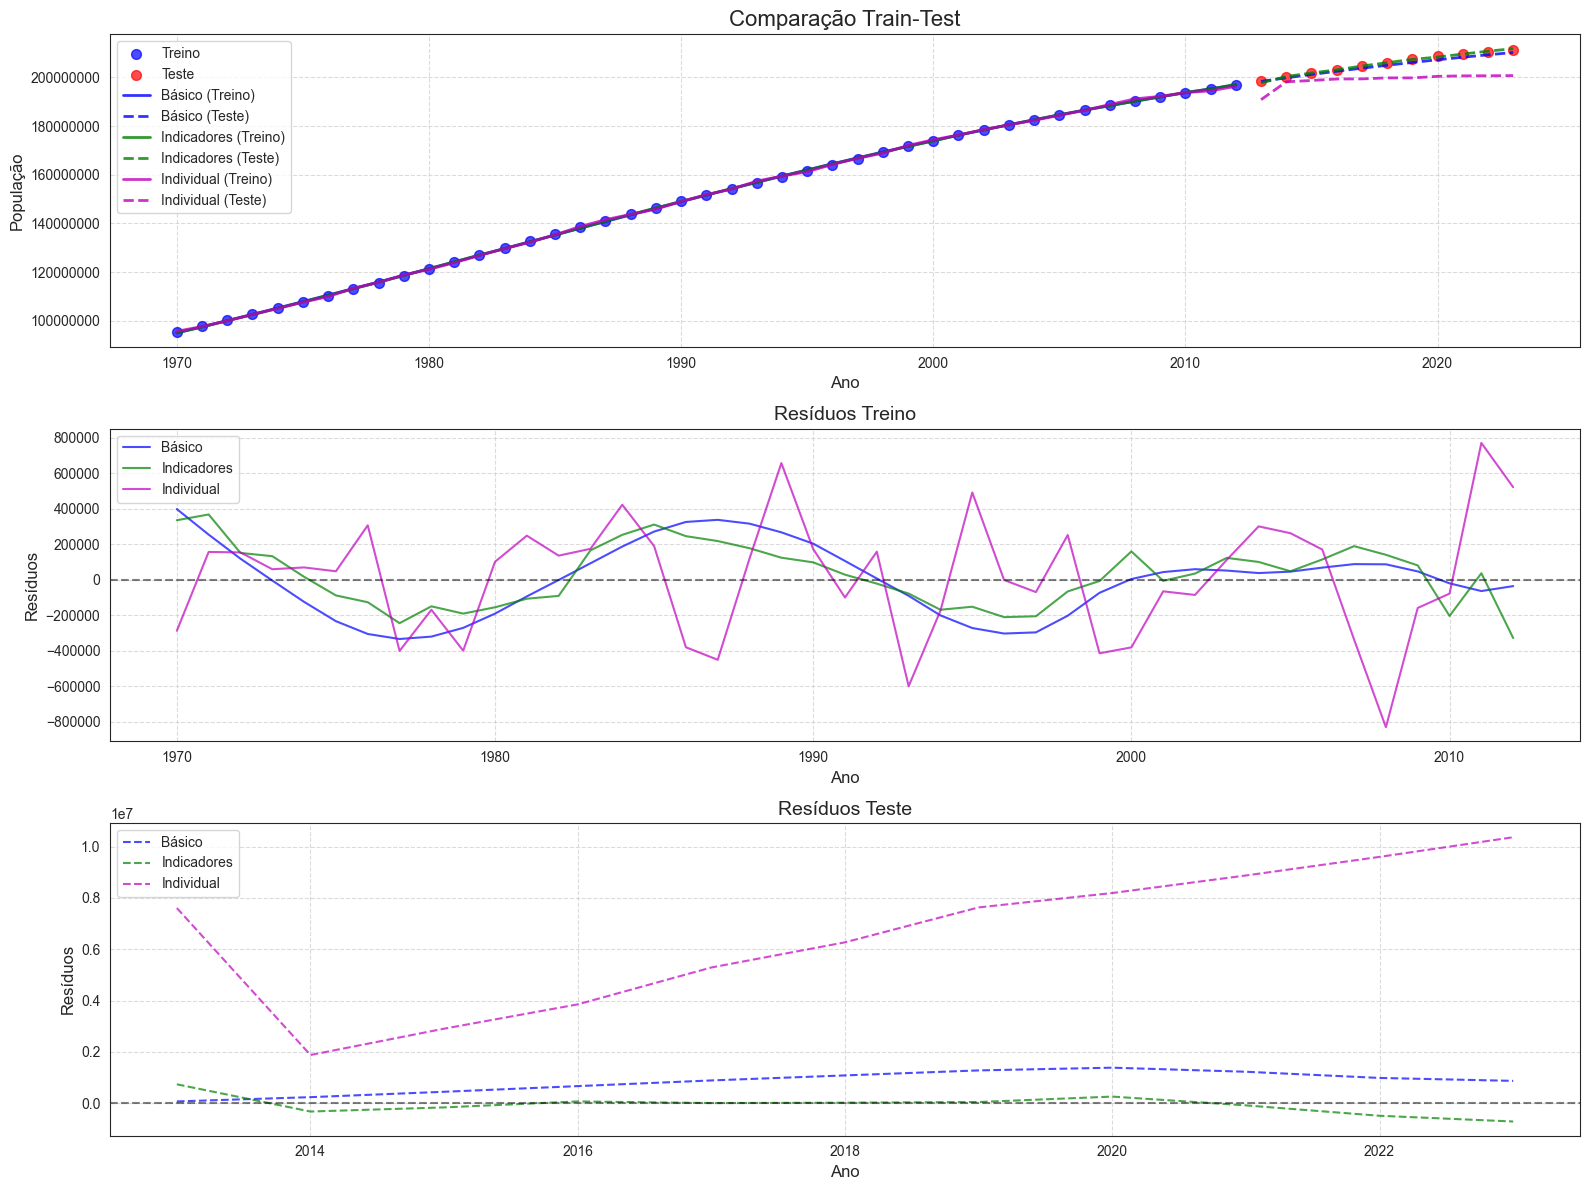

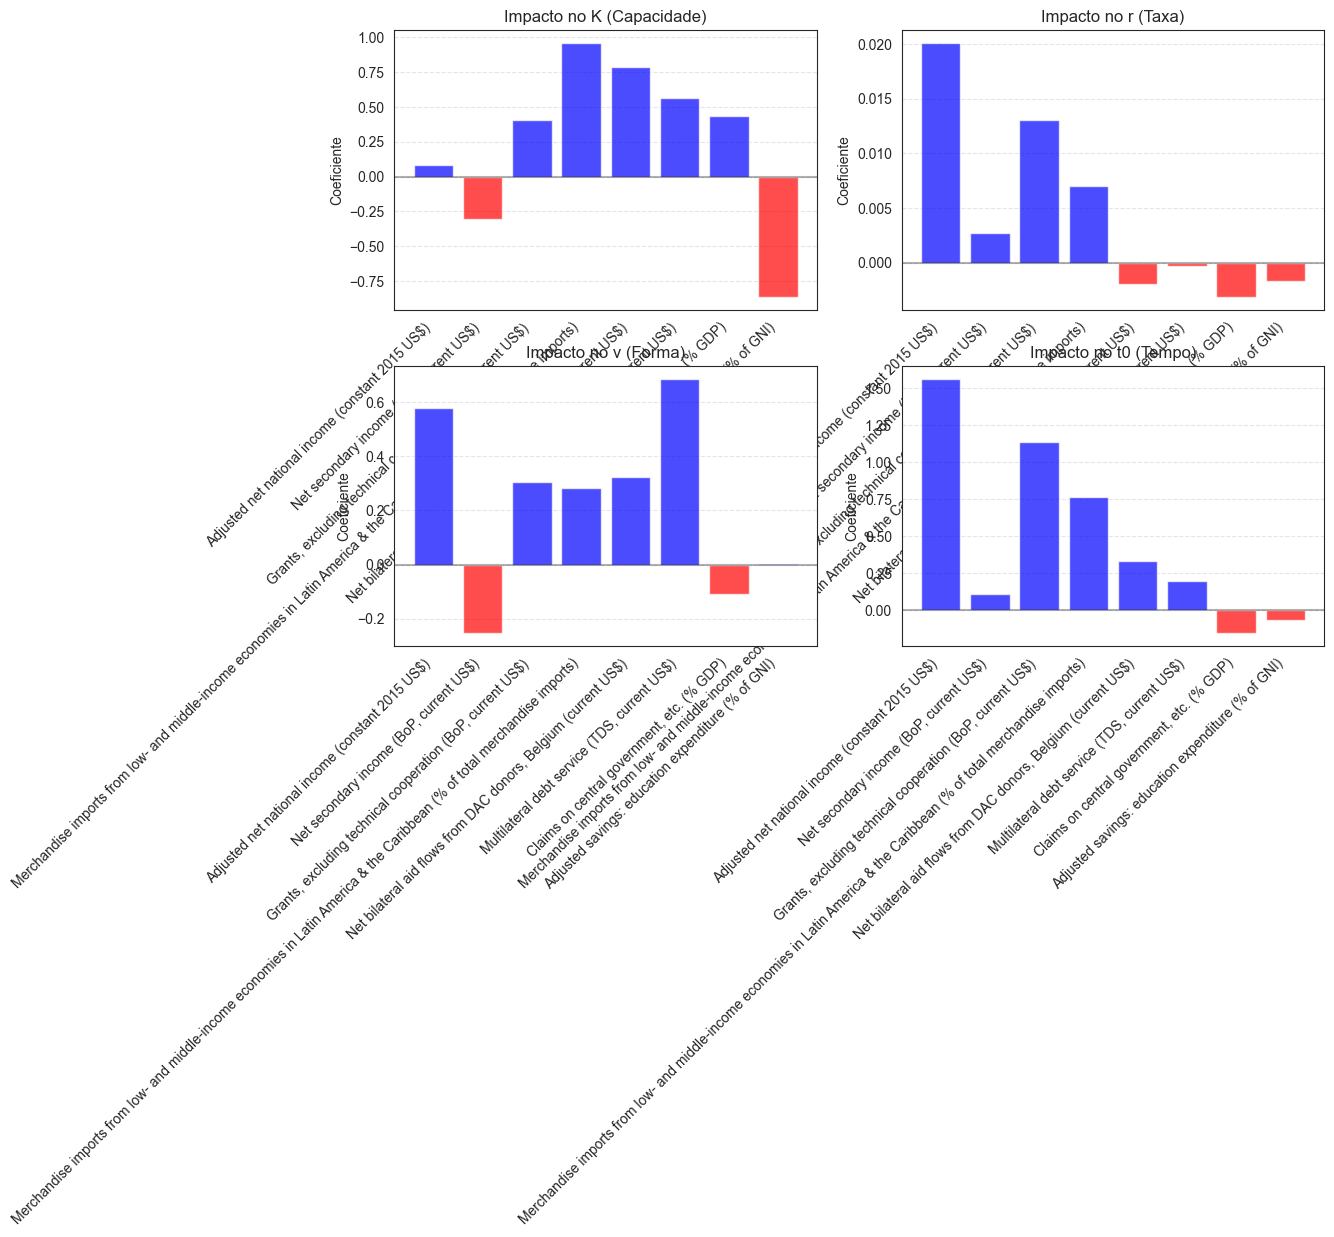


Realizando projeções...

Projeções para os próximos anos:
Ano   Básico         Indic. Soma    Individual     
---------------------------------------------------
2013.0   198,413,011   198,757,164   196,744,230
2014.0   199,853,650   200,303,706   197,495,907
2015.0   201,234,246   201,793,366   198,147,100
2016.0   202,555,931   203,226,637   198,708,989
2017.0   203,819,954   204,604,162   199,192,117
2018.0   205,027,670   205,926,719   199,606,248
2019.0   206,180,521   207,195,211   199,960,287
2020.0   207,280,023   208,410,652   200,262,252


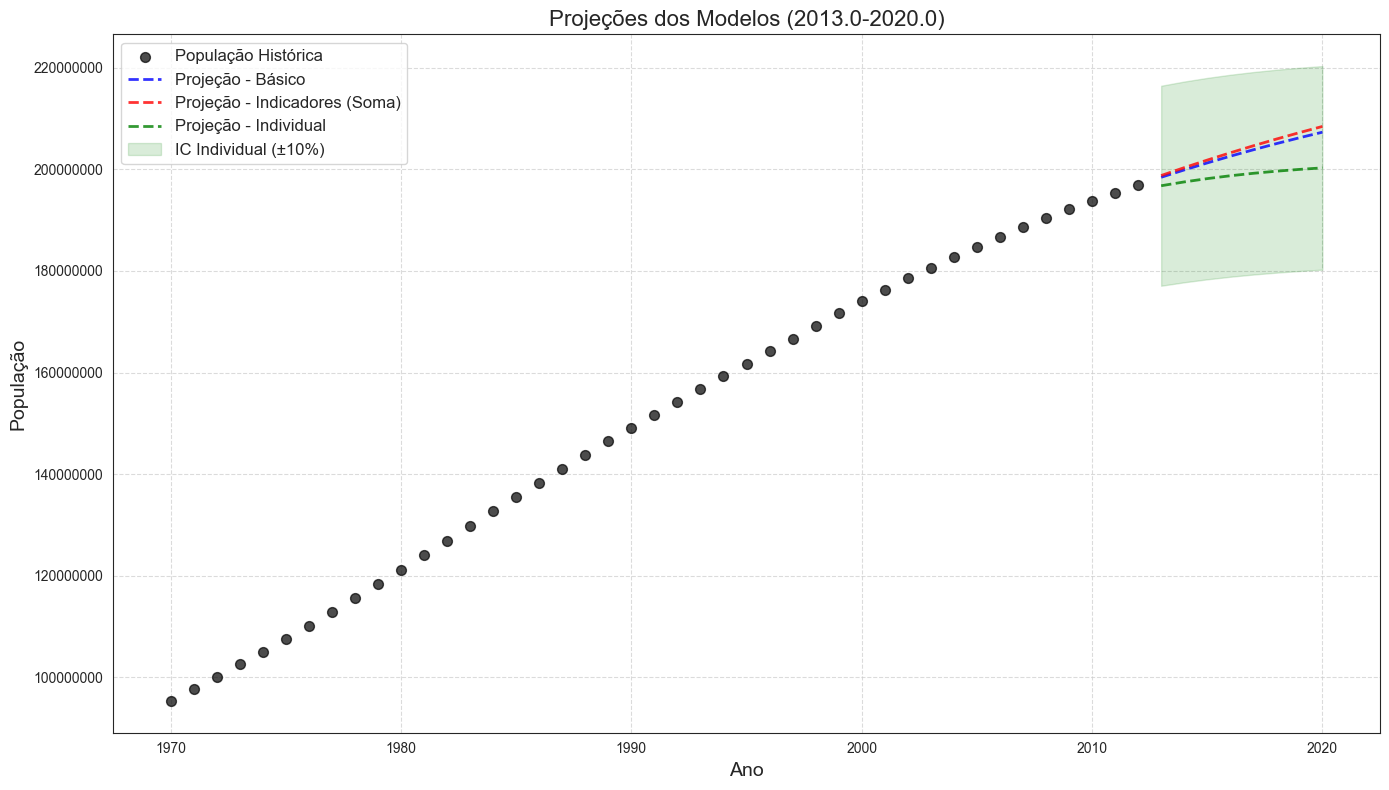

In [77]:
resultados_modelagem = executar_modelagem_richards_completa(
    new_df_brasil_wide=new_df_brasil_wide,
    population_col='Population, total',
    growth_col_for_corr='Population growth (annual %)',
    num_top_corr_indicators=8,      # pode ajustar a quantidade de indicadores para o modelo de soma
    anos_para_projetar=8,       # pode ajustar a quantidade de anos futuros para projetar
    test_size=0.2,               # fração dos dados usada para teste
    random_state=42              # para reprodutibilidade do split
)



### K-fold cross validation individual com n = 8

In [78]:
indicadores_selecionados_n8 = [
    "Adjusted net national income (constant 2015 US$)",
    "Net secondary income (BoP, current US$)",
    "Grants, excluding technical cooperation (BoP, current US$)",
    "Merchandise imports from low- and middle-income economies in Latin America & the Caribbean (% of total merchandise imports)",
    "Net bilateral aid flows from DAC donors, Belgium (current US$)",
    "Multilateral debt service (TDS, current US$)",
    "Claims on central government, etc. (% GDP)",
    "Adjusted savings: education expenditure (% of GNI)"
]


In [79]:
#resultados_cv_individual_8 = validacao_cruzada_rolante_individual(df=new_df_brasil_wide, indicadores_selecionados= indicadores_selecionados_n8, population_col='Population, total', n_splits=5  )

### K-fold cross validation soma com n = 8

Executando validação cruzada rolante com 5 folds...


Fold 1: MSE=360563993199.94, RMSE=600469.81, R²=0.7894
Fold 2: MSE=190575176045.61, RMSE=436549.17, R²=0.8890
Fold 3: MSE=417659826938.82, RMSE=646266.07, R²=0.7267
Fold 4: MSE=361464244455.94, RMSE=601218.97, R²=0.6678
Fold 5: MSE=105356554051.14, RMSE=324586.74, R²=0.7503

=== RESUMO DA VALIDAÇÃO CRUZADA ROLANTE ===
Número de folds executados: 5
MSE: 287123958938.2904 ± 118592231174.9979 (min: 105356554051.1360, max: 417659826938.8249)
RMSE: 521818.1505 ± 121777.5708 (min: 324586.7435, max: 646266.0651)
R2: 0.7646 ± 0.0736 (min: 0.6678, max: 0.8890)


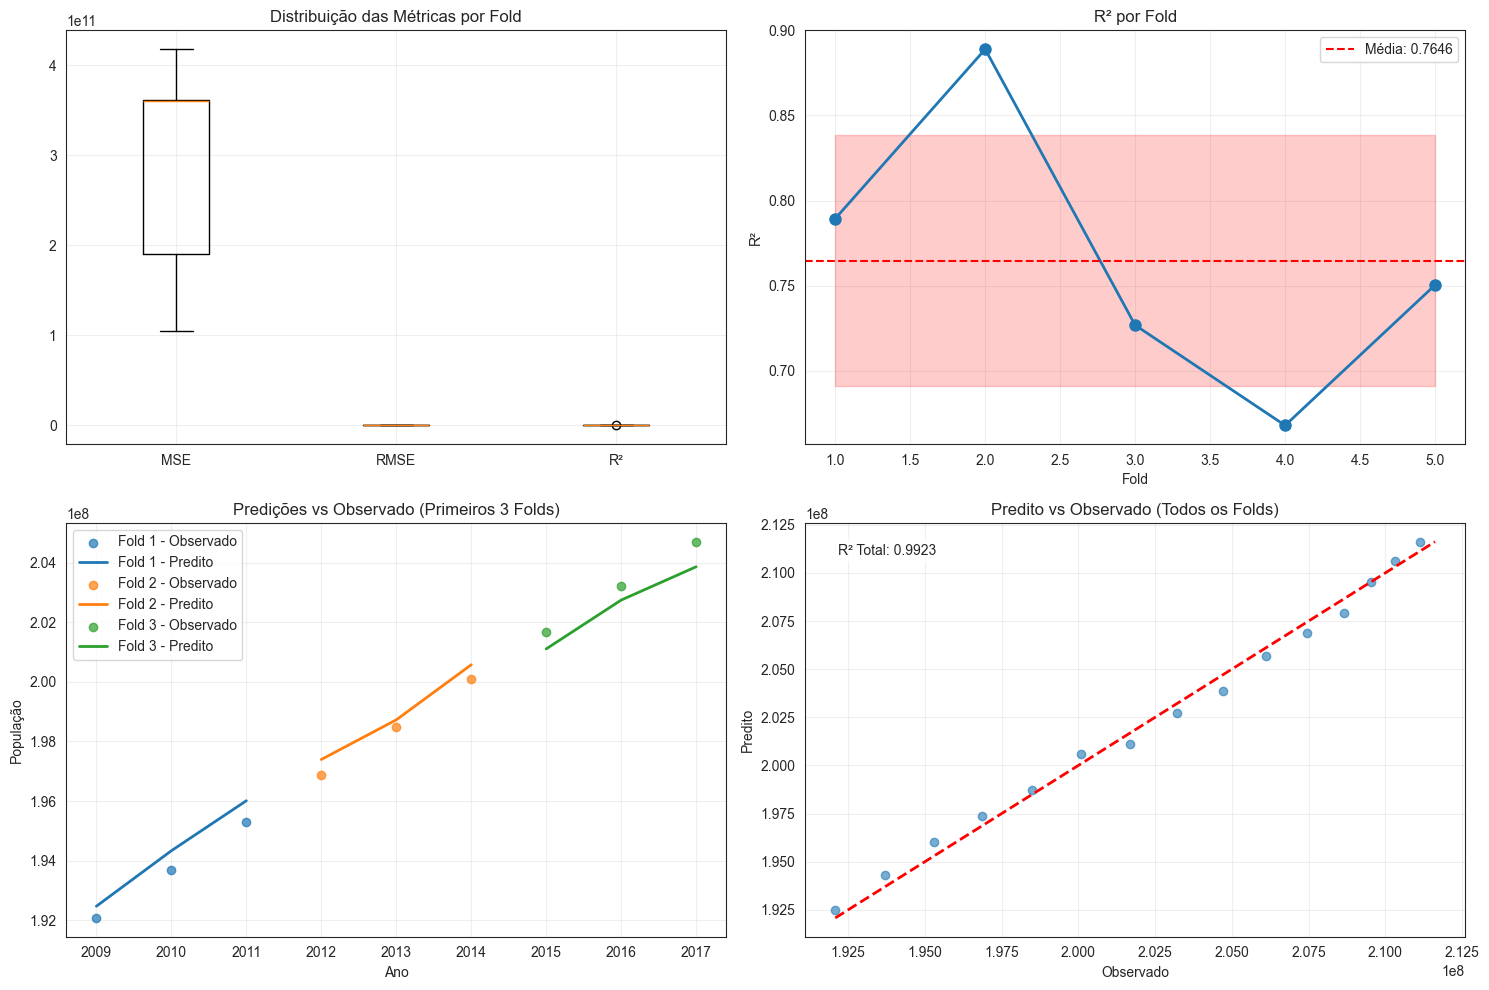

In [80]:
resultados_cv_soma_8 = validacao_cruzada_rolante_soma(
    df=new_df_brasil_wide,
    indicadores_selecionados= indicadores_selecionados_n8,
    population_col='Population, total',
    n_splits=5  
)

## PCA e Investigação de multicolinearidade

In [ ]:
# --- Funções Auxiliares ---
def investigar_multicolinearidade(indicators_data, indicadores_nomes, threshold=0.8):
    if indicators_data.shape[1] < 2: return [], None # Não pode calcular com < 2 indicadores
    corr_matrix = np.corrcoef(indicators_data.T)
    high_corr_pairs = []
    for i in range(len(indicadores_nomes)):
        for j in range(i+1, len(indicadores_nomes)):
            if abs(corr_matrix[i, j]) > threshold:
                high_corr_pairs.append((indicadores_nomes[i], indicadores_nomes[j], corr_matrix[i, j]))
    return high_corr_pairs, corr_matrix

def modelo_richards(t, K, r, v, t0):
    try:
        t_arr = np.array(t, dtype=float)
        # Garantir que K, r, v, t0 sejam escalares ou arrays com a mesma forma que t_arr para operações elemento a elemento
        K_arr, r_arr, v_arr, t0_arr = (val if isinstance(val, np.ndarray) and val.shape == t_arr.shape else np.full_like(t_arr, val)
                                      for val in [K, r, v, t0])

        exponent = np.clip(-r_arr * (t_arr - t0_arr), -500, 500)
        denominator = (1 + v_arr * np.exp(exponent))
        denominator = np.maximum(denominator, 1e-15) # Evitar divisão por zero ou valores muito pequenos
        
        # Checar se v_arr é zero antes da exponenciação 1/v_arr
        # Para v_arr muito próximo de zero, a curva de Richards aproxima-se da de Gompertz ou Logística
        # Aqui, simplesmente evitamos o erro de divisão por zero.
        # Um tratamento mais sofisticado para v próximo de zero pode ser necessário dependendo do contexto.
        v_arr_safe = np.where(np.abs(v_arr) < 1e-9, 1e-9, v_arr) # Evitar v=0
        
        with warnings.catch_warnings(): # Suprimir warnings de invalid value em power para v_arr_safe < 0
            warnings.simplefilter("ignore", RuntimeWarning)
            power_val = 1.0 / v_arr_safe
            # Se o denominador for negativo e power_val não for inteiro, resultará em NaN.
            # Denominador (1 + v * exp) é geralmente positivo se v > 0. Se v < 0, pode ser problemático.
            # A restrição v = np.maximum(v, 0.001) nos modelos ajuda a evitar isso.
            term_powered = denominator ** power_val

        result = K_arr / term_powered
        return np.maximum(result, 0) # População não pode ser negativa
    except Exception as e:
        # print(f"Debug: Erro em modelo_richards: {e}, t:{t}, K:{K}, r:{r}, v:{v}, t0:{t0}")
        return np.full_like(np.array(t, dtype=float), np.nan)


# Função preparar_dados_para_modelagem (do script original do usuário 'trab_curvas.py')
# Adaptada para consistência
def preparar_dados_para_modelagem(df_original, indicadores_para_usar, population_col_name='Population, total', test_size_ratio=0.2, random_state_val=42):
    cols_necessarias = [population_col_name] + [ind for ind in indicadores_para_usar if ind in df_original.columns]
    df_filtrado = df_original[list(dict.fromkeys(cols_necessarias))].copy() # Mantém ordem e remove duplicatas
    df_filtrado.dropna(subset=[population_col_name], inplace=True) # Remove linhas onde a população é NaN

    anos_abs = df_filtrado.index.values.astype(float)
    anos_rel = anos_abs - anos_abs.min()
    populacao = df_filtrado[population_col_name].values.astype(float)

    # Split cronológico
    if len(anos_rel) < 5:
        idx_treino = idx_teste = np.arange(len(anos_rel))
    else:
        ponto_split = int(len(anos_rel) * (1 - test_size_ratio))
        idx_treino = np.arange(ponto_split)
        idx_teste = np.arange(ponto_split, len(anos_rel))
        if len(idx_teste) == 0 and len(idx_treino) > 0:
             idx_teste = idx_treino[-1:]; idx_treino = idx_treino[:-1]
        if len(idx_treino) == 0: raise ValueError("Sem dados de treino após split.")

    X_treino, X_teste = anos_rel[idx_treino], anos_rel[idx_teste]
    y_treino, y_teste = populacao[idx_treino], populacao[idx_teste]
    anos_abs_treino, anos_abs_teste = anos_abs[idx_treino], anos_abs[idx_teste]

    indicadores_selecionados_presentes = [ind for ind in indicadores_para_usar if ind in df_filtrado.columns and ind != population_col_name]
    
    if indicadores_selecionados_presentes:
        dados_indicadores = df_filtrado[indicadores_selecionados_presentes].values.astype(float)
        # Tratar NaNs nos indicadores (ex: preenchimento pela média do treino ANTES do scale)
        # Para simplificar, assumimos que NaNs nos indicadores já foram tratados ou serão pelo scaler com erro.
        # Idealmente: imputer = SimpleImputer(); dados_indicadores_train = imputer.fit_transform(dados_indicadores[idx_treino]); ...
        
        indicadores_treino_raw = dados_indicadores[idx_treino]
        indicadores_teste_raw = dados_indicadores[idx_teste]

        scaler_obj = StandardScaler()
        # Lidar com colunas de variância zero antes do fit.
        # Se uma coluna em indicadores_treino_raw tiver std dev zero, StandardScaler falhará ou dará warning.
        # Solução simples: adicionar pequeno ruído ou remover essas colunas.
        # Para este exemplo, prosseguimos, mas isso pode ser um ponto de falha.
        try:
            indicadores_treino_scaled = scaler_obj.fit_transform(indicadores_treino_raw)
            indicadores_teste_scaled = scaler_obj.transform(indicadores_teste_raw)
        except ValueError as e: # Provável devido a variância zero
            print(f"Aviso: Problema no StandardScaler (provável variância zero em alguma coluna de indicadores): {e}. Indicadores não serão escalados.")
            indicadores_treino_scaled = indicadores_treino_raw
            indicadores_teste_scaled = indicadores_teste_raw
            scaler_obj = None # Indicar que o scaler não foi ajustado
    else:
        indicadores_treino_scaled = np.empty((len(X_treino), 0))
        indicadores_teste_scaled = np.empty((len(X_teste), 0))
        scaler_obj = None
        
    return {
        'X_train': X_treino, 'X_test': X_teste,
        'y_train': y_treino, 'y_test': y_teste,
        'indicators_train': indicadores_treino_scaled, 'indicators_test': indicadores_teste_scaled,
        'anos_train': anos_abs_treino, 'anos_test': anos_abs_teste,
        'indicadores_nomes': indicadores_selecionados_presentes, # Nomes dos indicadores efetivamente usados
        'scaler': scaler_obj
    }

def ajustar_modelo_richards_basico(X, y):
    def modelo_wrapper(t_params_wrapper, K, r, v, t0):
        t_array = np.array(t_params_wrapper, dtype=float)
        return modelo_richards(t_array, K, r, v, t0)

    p0 = [y.max()*0.8,0.02,0.5,X.mean() if X.size>0 else 0]
    bounds_lower = [y.max()*0.1,0.001,0.001,X.min() if X.size>0 else -np.inf]
    bounds_upper = [y.max()*2.0,0.5,10,X.max() if X.size>0 else np.inf]
    for i in range(len(p0)): p0[i] = np.clip(p0[i],bounds_lower[i],bounds_upper[i])
    try:
        params,pcov = curve_fit(modelo_wrapper,X,y,p0=p0,method='trf',maxfev=30000,bounds=(bounds_lower,bounds_upper))
        y_pred = modelo_wrapper(X,*params)
        try: param_errors = np.sqrt(np.diag(pcov))
        except: param_errors = np.full_like(params,np.inf)
    except Exception as e:
        print(f"Erro ajuste básico F: {e}. p0 usado."); params=np.array(p0); param_errors=np.full_like(params,np.inf)
        try: y_pred = modelo_wrapper(X,*params)
        except: y_pred = np.full_like(y,y.mean())
    return params,y_pred,param_errors

def modelo_richards_com_pca_soma(t, K_base, K_coef, r_base, r_coef, v_base, v_coef, t0_base, t0_coef, *pca_components_flat):
    t_arr = np.array(t,dtype=float); sum_pca_effect = np.zeros_like(t_arr,dtype=float)
    if t_arr.size==0: return np.array([])
    if len(pca_components_flat)>0:
        if len(pca_components_flat)%len(t_arr)!=0: raise ValueError("Shape pca_components_flat inconsistente")
        num_components = len(pca_components_flat)//len(t_arr)
        pca_data = np.array(pca_components_flat).reshape(num_components,len(t_arr)).T
        sum_pca_effect = np.sum(pca_data,axis=1)
    K=K_base+K_coef*sum_pca_effect; r=r_base+r_coef*sum_pca_effect
    v=v_base+v_coef*sum_pca_effect; t0=t0_base+t0_coef*sum_pca_effect
    K=np.maximum(K,1e-9);r=np.clip(r,0.001,1.0);v=np.maximum(v,0.001)
    return modelo_richards(t_arr,K,r,v,t0)

def ajustar_modelo_richards_com_pca_soma(X, y, pca_components):
    pca_flat = pca_components.T.flatten()
    def modelo_wrapper(t_w,K_b,K_c,r_b,r_c,v_b,v_c,t0_b,t0_c): return modelo_richards_com_pca_soma(t_w,K_b,K_c,r_b,r_c,v_b,v_c,t0_b,t0_c,*pca_flat)
    p0=[y.max()*0.8,0.001,0.02,0.0001,0.5,0.001,X.mean() if X.size>0 else 0,0.001]
    b_l=[y.max()*0.1,-0.5,0.001,-0.05,0.001,-0.05,X.min() if X.size>0 else -np.inf,-0.5]
    b_u=[y.max()*2.0,0.5,0.1,0.05,10,0.05,X.max() if X.size>0 else np.inf,0.5]
    for i in range(len(p0)):p0[i]=np.clip(p0[i],b_l[i],b_u[i])
    try:
        params,pcov=curve_fit(modelo_wrapper,X,y,p0=p0,method='trf',maxfev=30000,bounds=(b_l,b_u))
        param_errors=np.sqrt(np.diag(pcov))
    except Exception as e: print(f"Erro PCA Soma F:{e}. p0 usado.");params=np.array(p0);param_errors=np.full_like(params,np.inf)
    y_pred=modelo_wrapper(X,*params)
    return params,y_pred,param_errors

modelo_richards_com_pca_separado._pca_data = None 
def modelo_richards_com_pca_separado(t, K_base, r_base, v_base, t0_base, *pca_coefs_flat):
    t_arr=np.array(t,dtype=float); pca_data=modelo_richards_com_pca_separado._pca_data
    if t_arr.size==0:return np.array([])
    if pca_data is None or len(pca_coefs_flat)==0:
        K,r,v,t0=(np.full_like(t_arr,val,dtype=float) for val in [K_base,r_base,v_base,t0_base])
    else:
        n_comp=pca_data.shape[1]; exp_coefs=4*n_comp
        if len(pca_coefs_flat)!=exp_coefs: raise ValueError(f"PCA Sep Coefs: {exp_coefs} vs {len(pca_coefs_flat)}")
        coefs=np.array(pca_coefs_flat).reshape(4,n_comp)
        K_cs,r_cs,v_cs,t0_cs=coefs
        K=K_base+np.dot(pca_data,K_cs);r=r_base+np.dot(pca_data,r_cs)
        v=v_base+np.dot(pca_data,v_cs);t0=t0_base+np.dot(pca_data,t0_cs)
    K=np.maximum(K,1e-9);r=np.clip(r,0.001,1.0);v=np.maximum(v,0.001)
    return modelo_richards(t_arr,K,r,v,t0)

def ajustar_modelo_richards_com_pca_separado(X, y, pca_components):
    modelo_richards_com_pca_separado._pca_data = pca_components
    n_comp=pca_components.shape[1]
    p0_b=[y.max()*0.8,0.02,0.5,X.mean() if X.size>0 else 0];p0_c=[0.001]*(4*n_comp);p0=p0_b+p0_c
    b_l_b=[y.max()*0.1,0.001,0.001,X.min() if X.size>0 else -np.inf];b_u_b=[y.max()*2.0,0.5,10,X.max() if X.size>0 else np.inf]
    b_l_c=[-0.1]*(4*n_comp);b_u_c=[0.1]*(4*n_comp)
    b_l=b_l_b+b_l_c;b_u=b_u_b+b_u_c
    for i in range(len(p0)):p0[i]=np.clip(p0[i],b_l[i],b_u[i])
    try:
        params,pcov=curve_fit(modelo_richards_com_pca_separado,X,y,p0=p0,method='trf',maxfev=30000,bounds=(b_l,b_u))
        param_errors=np.sqrt(np.diag(pcov))
    except Exception as e: print(f"Erro PCA Sep F:{e}. p0 usado.");params=np.array(p0);param_errors=np.full_like(params,np.inf)
    y_pred=modelo_richards_com_pca_separado(X,*params)
    return params,y_pred,param_errors

def ajustar_modelo_richards_individual_regularizado_correto(X, y, indicators_data, regularization_strength=0.01):
    num_features = indicators_data.shape[1]
    if num_features == 0: return ajustar_modelo_richards_basico(X,y) 

    def objetivo_com_regularizacao(params):
        K_b,r_b,v_b,t0_b=params[:4];coefs=params[4:]
        try:
            coefs_m=coefs.reshape(4,num_features)
            K=K_b+np.dot(indicators_data,coefs_m[0,:]);r=r_b+np.dot(indicators_data,coefs_m[1,:])
            v=v_b+np.dot(indicators_data,coefs_m[2,:]);t0=t0_b+np.dot(indicators_data,coefs_m[3,:])
            K=np.maximum(K,1e-9);r=np.clip(r,0.001,1.0);v=np.maximum(v,0.001)
            y_p=np.zeros_like(y)
            for i in range(len(X)):y_p[i]=modelo_richards(X[i],K[i],r[i],v[i],t0[i])
            mse=np.mean((y-y_p)**2);reg=regularization_strength*np.sum(coefs**2)
            return mse+reg
        except: return 1e12 
    p0_b=[y.max()*0.8,0.02,0.5,X.mean() if X.size>0 else 0];p0_c=[0.001]*(4*num_features)
    p0=np.array(p0_b+p0_c)
    bds_b=[(y.max()*0.1,y.max()*2.0),(0.001,0.5),(0.001,10),(X.min() if X.size>0 else -np.inf,X.max() if X.size>0 else np.inf)]
    bds_c=[(-0.1,0.1)]*(4*num_features);bds=bds_b+bds_c
    param_errs=np.full_like(p0,np.inf) 
    try:
        res=minimize(objetivo_com_regularizacao,p0,method='L-BFGS-B',bounds=bds,options={'maxiter':1000,'ftol':1e-7,'maxfun': 20000})
        params=res.x
        K_b,r_b,v_b,t0_b=params[:4];coefs=params[4:]
        coefs_m=coefs.reshape(4,num_features)
        K=K_b+np.dot(indicators_data,coefs_m[0,:]);r=r_b+np.dot(indicators_data,coefs_m[1,:])
        v=v_b+np.dot(indicators_data,coefs_m[2,:]);t0=t0_b+np.dot(indicators_data,coefs_m[3,:])
        K=np.maximum(K,1e-9);r=np.clip(r,0.001,1.0);v=np.maximum(v,0.001)
        y_pred=np.zeros_like(y)
        for i in range(len(X)):y_pred[i]=modelo_richards(X[i],K[i],r[i],v[i],t0[i])
    except Exception as e: print(f"Erro Ind Reg F:{e}. p0 usado.");params=p0;y_pred=np.full_like(y,y.mean())
    return params,y_pred,param_errs

def calcular_cv_robusto(params_array):
    cv_vals = []
    if params_array.ndim == 1: params_array = params_array.reshape(1, -1) # Lida com array de 1D (1 fold)
    if params_array.shape[0] <= 1: return np.full(params_array.shape[1], np.nan) # Não pode calcular CV com 0 ou 1 amostra
    for i in range(params_array.shape[1]):
        p_vals=params_array[:,i];m_val=np.nanmean(p_vals);s_val=np.nanstd(p_vals)
        if abs(m_val)<1e-10:cv_vals.append(np.inf if s_val>1e-10 else 0.0)
        else:cv_vals.append(s_val/abs(m_val))
    return np.array(cv_vals)

def executar_modelagem_com_pca_estabilizada_corrigida(new_df_brasil_wide,
                                                      population_col='Population, total',
                                                      growth_col_for_corr='Population growth (annual %)',
                                                      num_top_corr_indicators=8,
                                                      n_pca_components=3,
                                                      k_folds=5, # Usado por TimeSeriesSplit
                                                      test_size_global=0.2, # Renomeado para clareza
                                                      random_state_global=42, # Renomeado
                                                      regularization_strength=0.01):
    print("=== ANÁLISE DE ESTABILIDADE E MODELAGEM COM PCA (VERSÃO CORRIGIDA E EXPANDIDA) ===")
    
    # 1. Preparação Inicial dos Dados e Seleção de Indicadores
    # Usa todas as colunas inicialmente para permitir a seleção de indicadores mais ampla
    # O split efetivo de treino/teste dos indicadores e escalonamento acontecerá em `preparar_dados_para_modelagem`
    df_para_selecao_indicadores = new_df_brasil_wide.dropna(subset=[population_col, growth_col_for_corr])
    
    # Split cronológico para seleção de indicadores (evitar data leakage da seleção para o teste global)
    anos_para_selecao = df_para_selecao_indicadores.index.values.astype(float)
    split_idx_selecao = int(len(anos_para_selecao) * (1 - test_size_global))
    df_treino_para_selecao_indicadores = df_para_selecao_indicadores.iloc[:split_idx_selecao]

    correlacoes = df_treino_para_selecao_indicadores.corr(numeric_only=True)[growth_col_for_corr].dropna().sort_values(key=abs, ascending=False)
    indicadores_candidatos = [
        col for col in correlacoes.index if col != growth_col_for_corr and col != population_col
    ][:num_top_corr_indicators]

    if not indicadores_candidatos:
        print("AVISO: Nenhum indicador candidato selecionado. Usando um conjunto padrão ou parando.")
        # Fallback para um conjunto padrão se necessário, ou raise error
        # indicadores_candidatos = ['DefaultIndicator1', 'DefaultIndicator2'] # Exemplo
        # Ou: raise ValueError("Nenhum indicador candidato pode ser selecionado.")
        # Por ora, o código prosseguirá e os modelos com indicadores/PCA não rodarão ou darão erro.
        # É melhor garantir que 'dados' seja criado mesmo assim para o modelo básico.
        if not indicadores_candidatos: # Se ainda vazio
            print("Nenhum indicador candidato selecionado. Apenas o modelo básico será efetivo no CV.")
            # Garante que a lista não seja None para preparar_dados_para_modelagem
            indicadores_candidatos_para_dados = [] 
    else:
        indicadores_candidatos_para_dados = indicadores_candidatos

    print(f"Indicadores candidatos para modelagem ({len(indicadores_candidatos_para_dados)}): {indicadores_candidatos_para_dados}")

    # Preparar dados para treino global e teste global usando os indicadores selecionados
    # Esta chamada a `preparar_dados_para_modelagem` define os conjuntos X_train, X_test, etc. GLOBAIS
    dados_globais = preparar_dados_para_modelagem(new_df_brasil_wide, 
                                          indicadores_candidatos_para_dados, 
                                          population_col, 
                                          test_size_global, 
                                          random_state_global)

    print("\n=== INVESTIGAÇÃO DE MULTICOLINEARIDADE (nos indicadores selecionados do treino global) ===")
    if dados_globais['indicators_train'].shape[1] > 1:
        high_corr_pairs, _ = investigar_multicolinearidade(dados_globais['indicators_train'], dados_globais['indicadores_nomes'])
        if high_corr_pairs: print("Pares com alta correlação (>0.8):"); [print(f" - {p[0]}x{p[1]}:{p[2]:.3f}") for p in high_corr_pairs]
        else: print("Nenhuma multicolinearidade severa detectada.")
    else: print("Menos de 2 indicadores selecionados para checagem de multicolinearidade.")

    pca_aplicado_global = False
    if dados_globais['indicators_train'].shape[1] > 0 and dados_globais['indicators_train'].shape[1] >= n_pca_components:
        print(f"\n=== APLICANDO PCA (n_components={n_pca_components}) GLOBALMENTE (nos indicadores do treino global) ===")
        pca_gerador_global = PCA(n_components=n_pca_components, random_state=random_state_global)
        pca_train_global = pca_gerador_global.fit_transform(dados_globais['indicators_train'])
        pca_test_global = pca_gerador_global.transform(dados_globais['indicators_test'])
        print("Variância explicada (PCA Global):"); [print(f" - PC{i+1}:{ve:.3f}({ve*100:.1f}%)") for i,ve in enumerate(pca_gerador_global.explained_variance_ratio_)]
        print(f"Total (PCA Global): {pca_gerador_global.explained_variance_ratio_.sum():.3f} ({pca_gerador_global.explained_variance_ratio_.sum()*100:.1f}%)")
        pca_aplicado_global = True
    else: print("\nAVISO: PCA Global não aplicado (indicadores insuficientes).")

    print(f"\n=== CROSS VALIDATION TEMPORAL (TimeSeriesSplit, n_splits={k_folds}) NOS DADOS DE TREINO GLOBAIS ===")
    tscv = TimeSeriesSplit(n_splits=k_folds)
    
    # Inicializar resultados_cv
    resultados_cv = {'basico': {'mse':[],'r2':[],'params':[],'param_errors':[]},
                     'individual_reg': {'mse':[],'r2':[],'params':[],'param_errors':[]}}
    if pca_aplicado_global:
        resultados_cv['pca_soma'] = {'mse':[],'r2':[],'params':[],'param_errors':[]}
        resultados_cv['pca_separado'] = {'mse':[],'r2':[],'params':[],'param_errors':[]}

    for fold, (train_fold_idx, val_fold_idx) in enumerate(tscv.split(dados_globais['X_train'])):
        print(f"\nFold {fold+1}/{k_folds}")
        X_tf, X_vf = dados_globais['X_train'][train_fold_idx], dados_globais['X_train'][val_fold_idx]
        y_tf, y_vf = dados_globais['y_train'][train_fold_idx], dados_globais['y_train'][val_fold_idx]
        ind_tf_raw = dados_globais['indicators_train'][train_fold_idx] # Já escalonados pelo scaler global
        ind_vf_raw = dados_globais['indicators_train'][val_fold_idx]   # Já escalonados pelo scaler global
        
        # Modelo Básico
        try:
            p_bas,_,err_bas = ajustar_modelo_richards_basico(X_tf,y_tf)
            y_p_bas_v = modelo_richards(X_vf,*p_bas) # X_vf é array
            resultados_cv['basico']['mse'].append(mean_squared_error(y_vf,y_p_bas_v)); resultados_cv['basico']['r2'].append(r2_score(y_vf,y_p_bas_v))
            resultados_cv['basico']['params'].append(p_bas); resultados_cv['basico']['param_errors'].append(err_bas)
        except Exception as e: print(f"Err basico F{fold+1}:{e}"); [resultados_cv['basico'][k].append(np.nan) for k in ['mse','r2']]; [resultados_cv['basico'][k].append(np.full(s,np.nan)) for k,s in [('params',4),('param_errors',4)]]

        if pca_aplicado_global:
            # PCA para o fold (fit_transform no treino do fold, transform na validação do fold)
            # Os indicadores ind_tf_raw e ind_vf_raw já foram escalonados pelo scaler global.
            # Para PCA dentro do CV, é mais rigoroso re-escalar e re-fazer PCA em cada fold de treino do CV
            # No entanto, para simplificar e se os indicadores já estão escalados globalmente,
            # pode-se aplicar PCA diretamente se o número de amostras for suficiente.
            # A abordagem mais correta é re-escalar E re-fazer PCA:
            scaler_fold = StandardScaler()
            ind_tf_scaled_fold = scaler_fold.fit_transform(ind_tf_raw)
            ind_vf_scaled_fold = scaler_fold.transform(ind_vf_raw)

            if ind_tf_scaled_fold.shape[1] >= n_pca_components and ind_tf_scaled_fold.shape[0] > n_pca_components : # Checa se há features e amostras para PCA
                pca_f = PCA(n_components=n_pca_components,random_state=random_state_global)
                pca_tf = pca_f.fit_transform(ind_tf_scaled_fold)
                pca_vf = pca_f.transform(ind_vf_scaled_fold)
                
                # Modelo PCA Soma
                try:
                    p_pca_s,_,err_pca_s = ajustar_modelo_richards_com_pca_soma(X_tf,y_tf,pca_tf)
                    y_p_pca_s_v = modelo_richards_com_pca_soma(X_vf,*p_pca_s,*pca_vf.T.flatten())
                    resultados_cv['pca_soma']['mse'].append(mean_squared_error(y_vf,y_p_pca_s_v)); resultados_cv['pca_soma']['r2'].append(r2_score(y_vf,y_p_pca_s_v))
                    resultados_cv['pca_soma']['params'].append(p_pca_s); resultados_cv['pca_soma']['param_errors'].append(err_pca_s)
                except Exception as e: print(f"Err PCA Soma F{fold+1}:{e}"); [resultados_cv['pca_soma'][k].append(np.nan) for k in ['mse','r2']]; [resultados_cv['pca_soma'][k].append(np.full(s,np.nan)) for k,s in [('params',8),('param_errors',8)]]

                # Modelo PCA Separado
                try:
                    p_pca_sep,_,err_pca_sep = ajustar_modelo_richards_com_pca_separado(X_tf,y_tf,pca_tf)
                    modelo_richards_com_pca_separado._pca_data = pca_vf
                    y_p_pca_sep_v = modelo_richards_com_pca_separado(X_vf,*p_pca_sep)
                    resultados_cv['pca_separado']['mse'].append(mean_squared_error(y_vf,y_p_pca_sep_v)); resultados_cv['pca_separado']['r2'].append(r2_score(y_vf,y_p_pca_sep_v))
                    resultados_cv['pca_separado']['params'].append(p_pca_sep); resultados_cv['pca_separado']['param_errors'].append(err_pca_sep)
                except Exception as e: print(f"Err PCA Sep F{fold+1}:{e}");[resultados_cv['pca_separado'][k].append(np.nan) for k in ['mse','r2']];n_p_pca_sep=4+4*n_pca_components;[resultados_cv['pca_separado'][k].append(np.full(s,np.nan)) for k,s in [('params',n_p_pca_sep),('param_errors',n_p_pca_sep)]]
            else: # Não foi possível aplicar PCA no fold
                print(f"PCA não aplicado no Fold {fold+1} (indicadores ou amostras insuficientes no treino do fold).")
                for pca_model_key in ['pca_soma', 'pca_separado']:
                     if pca_model_key in resultados_cv:
                        [resultados_cv[pca_model_key][k].append(np.nan) for k in ['mse','r2']]
                        num_params_default = 8 if pca_model_key == 'pca_soma' else 4 + 4*n_pca_components
                        [resultados_cv[pca_model_key][k].append(np.full(s,np.nan)) for k,s in [('params',num_params_default),('param_errors',num_params_default)]]
        

    print("\n=== ANÁLISE DE ESTABILIDADE DOS COEFICIENTES (ROBUSTA) ===")
    # (Como antes, mas usando np.nanmean e np.nanstd para lidar com possíveis NaNs de folds falhos)
    for modelo_nome, resultado in resultados_cv.items():
        # ... (código da análise de estabilidade como na sua última versão, usando nanmean/nanstd)
        if len(resultado.get('params', [])) > 0:
            # Filtra folds onde params não são todos NaN
            params_validos = [p for p in resultado['params'] if not np.all(np.isnan(p))]
            if len(params_validos) > 1 : # Precisa de pelo menos 2 folds com params válidos
                params_array = np.array(params_validos)
                cv_coeff = calcular_cv_robusto(params_array)
                
                print(f"\n{modelo_nome.upper()}:")
                # Calcula métricas apenas dos folds que não resultaram em NaN para mse/r2
                mse_validos = [m for m in resultado['mse'] if not np.isnan(m)]
                r2_validos = [r for r in resultado['r2'] if not np.isnan(r)]

                print(f" - MSE médio: {np.mean(mse_validos):.2e} ± {np.std(mse_validos):.2e}" if mse_validos else " - MSE médio: N/A")
                print(f" - R² médio: {np.mean(r2_validos):.4f} ± {np.std(r2_validos):.4f}" if r2_validos else " - R² médio: N/A")
                
                # Nomes dos parâmetros (genérico, pode ser melhorado para cada modelo)
                num_params_estimados = params_array.shape[1]
                param_names = []
                if modelo_nome == 'basico': param_names = ["K_base", "r_base", "v_base", "t0_base"]
                elif modelo_nome == 'pca_soma': param_names = ["K_b", "K_c_sum", "r_b", "r_c_sum", "v_b", "v_c_sum", "t0_b", "t0_c_sum"]
                elif modelo_nome == 'pca_separado':
                    param_names = ["K_b", "r_b", "v_b", "t0_b"]
                    for i in range(n_pca_components): param_names.append(f"K_PC{i+1}")
                    for i in range(n_pca_components): param_names.append(f"r_PC{i+1}")
                    for i in range(n_pca_components): param_names.append(f"v_PC{i+1}")
                    for i in range(n_pca_components): param_names.append(f"t0_PC{i+1}")
                elif modelo_nome == 'individual_reg':
                    param_names = ["K_b", "r_b", "v_b", "t0_b"]
                    num_inds_reg = dados_globais['indicators_train'].shape[1]
                    for i in range(num_inds_reg): param_names.append(f"K_Ind{i+1}")
                    for i in range(num_inds_reg): param_names.append(f"r_Ind{i+1}")
                    for i in range(num_inds_reg): param_names.append(f"v_Ind{i+1}")
                    for i in range(num_inds_reg): param_names.append(f"t0_Ind{i+1}")
                else: param_names = [f"P{i+1}" for i in range(num_params_estimados)]
                
                # Garante que param_names tenha o mesmo comprimento que cv_coeff
                if len(param_names) != len(cv_coeff):
                    param_names = [f"P{i+1}" for i in range(len(cv_coeff))]


                print(" - CV dos parâmetros (individual):")
                for name_idx, cv_val in enumerate(cv_coeff):
                    print(f"   - {param_names[name_idx]}: {cv_val*100:.2f}%" if np.isfinite(cv_val) else f"   - {param_names[name_idx]}: N/A")
                print(f" - CV médio dos parâmetros (finitos): {np.mean(cv_coeff[np.isfinite(cv_coeff)])*100:.2f}%")
                
                # Erros médios dos parâmetros (se disponíveis, ex: de curve_fit)
                if 'param_errors' in resultado:
                    param_errors_validos = [e for e in resultado.get('param_errors', []) if e is not None and not np.all(np.isinf(e)) and not np.all(np.isnan(e))]
                    if len(param_errors_validos) > 0:
                        param_errors_array = np.array(param_errors_validos)
                        if param_errors_array.ndim == 2 and param_errors_array.shape[0] > 0 :
                            avg_errors = np.nanmean(param_errors_array, axis=0)
                            # Garante que param_names tenha o mesmo comprimento que avg_errors
                            if len(param_names) != len(avg_errors):
                                current_param_err_names = [f"Err_P{i+1}" for i in range(len(avg_errors))]
                            else:
                                current_param_err_names = param_names

                            print(f" - Erros médios dos parâmetros (std err):")
                            for name_idx, err_val in enumerate(avg_errors):
                                print(f"   - {current_param_err_names[name_idx]}: {err_val:.3e}")
            else:
                print(f"\n{modelo_nome.upper()}: Não há parâmetros válidos suficientes para calcular CV robusto.")
        else:
             print(f"\n{modelo_nome.upper()}: Modelo não rodou ou não há parâmetros para análise de CV.")


    # Plotagem dos resultados do CV
    modelos_validos_plot = [m for m in resultados_cv.keys() if len(resultados_cv[m].get('mse',[])) > 0 and not all(np.isnan(m) for m in resultados_cv[m]['mse'])]
    if not modelos_validos_plot:
        print("Nenhum modelo com resultados válidos para plotar no CV.")
    else:
        plt.figure(figsize=(15, 10))
        bar_colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'lightsalmon', 'cyan'][:len(modelos_validos_plot)]

        plt.subplot(2,2,1)
        mse_means = [np.nanmean(resultados_cv[modelo]['mse']) for modelo in modelos_validos_plot]
        mse_stds = [np.nanstd(resultados_cv[modelo]['mse']) for modelo in modelos_validos_plot]
        plt.bar(range(len(mse_means)), mse_means, yerr=mse_stds, capsize=5, color=bar_colors)
        plt.xticks(range(len(mse_means)), [m.replace("_"," ").title() for m in modelos_validos_plot], rotation=30, ha="right")
        plt.title('MSE Médio por Modelo (CV)'); plt.ylabel('MSE'); plt.grid(True,alpha=0.3,axis='y')

        plt.subplot(2,2,2)
        r2_means = [np.nanmean(resultados_cv[modelo]['r2']) for modelo in modelos_validos_plot]
        r2_stds = [np.nanstd(resultados_cv[modelo]['r2']) for modelo in modelos_validos_plot]
        plt.bar(range(len(r2_means)), r2_means, yerr=r2_stds, capsize=5, color=bar_colors)
        plt.xticks(range(len(r2_means)), [m.replace("_"," ").title() for m in modelos_validos_plot], rotation=30, ha="right")
        plt.title('R² Médio por Modelo (CV)'); plt.ylabel('R²'); plt.grid(True,alpha=0.3,axis='y')

        plt.subplot(2,2,3)
        cv_means_plot_vals = []
        for modelo_nome in modelos_validos_plot:
            params_validos = [p for p in resultados_cv[modelo_nome]['params'] if not np.all(np.isnan(p))]
            if len(params_validos) > 1:
                params_array = np.array(params_validos)
                cv_coeff = calcular_cv_robusto(params_array)
                cv_means_plot_vals.append(np.mean(cv_coeff[np.isfinite(cv_coeff)]) * 100) # Em %
            else: cv_means_plot_vals.append(np.nan)
        plt.bar(range(len(cv_means_plot_vals)), cv_means_plot_vals, color=bar_colors)
        plt.xticks(range(len(cv_means_plot_vals)), [m.replace("_"," ").title() for m in modelos_validos_plot], rotation=30, ha="right")
        plt.title('CV Médio dos Parâmetros (%)'); plt.ylabel('CV Médio (%)'); plt.grid(True,alpha=0.3,axis='y')
        
        plt.tight_layout(rect=[0,0,1,0.96]); plt.suptitle(f"Comparação de Modelos via CV Temporal (k={k_folds})",fontsize=16); plt.show()

    # Seção de teste final no conjunto de teste GLOBAL (dados_globais['X_test'], etc.)
    # ... (pode ser adicionada aqui, reajustando o "melhor" modelo do CV em dados_globais['X_train'] completo)

    return {
        'resultados_cv': resultados_cv,
        'pca_global_object': pca_gerador_global if pca_aplicado_global else None,
        'dados_globais_usados': dados_globais, # Para referência
        'high_corr_pairs': high_corr_pairs if dados_globais['indicators_train'].shape[1]>1 else "N/A",
        'indicadores_candidatos_finais': indicadores_candidatos_para_dados
    }

# Configurações de Warnings (no final do script)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

=== ANÁLISE DE ESTABILIDADE E MODELAGEM COM PCA (VERSÃO CORRIGIDA E EXPANDIDA) ===
Indicadores candidatos para modelagem (3): ['Adjusted net national income (constant 2015 US$)', 'Net secondary income (BoP, current US$)', 'Grants, excluding technical cooperation (BoP, current US$)']

=== INVESTIGAÇÃO DE MULTICOLINEARIDADE (nos indicadores selecionados do treino global) ===
Pares com alta correlação (>0.8):
 - Adjusted net national income (constant 2015 US$)xNet secondary income (BoP, current US$):0.883
 - Adjusted net national income (constant 2015 US$)xGrants, excluding technical cooperation (BoP, current US$):0.923
 - Net secondary income (BoP, current US$)xGrants, excluding technical cooperation (BoP, current US$):0.820

=== APLICANDO PCA (n_components=1) GLOBALMENTE (nos indicadores do treino global) ===
Variância explicada (PCA Global):
 - PC1:0.917(91.7%)
Total (PCA Global): 0.917 (91.7%)

=== CROSS VALIDATION TEMPORAL (TimeSeriesSplit, n_splits=5) NOS DADOS DE TREINO GLOBAIS ===

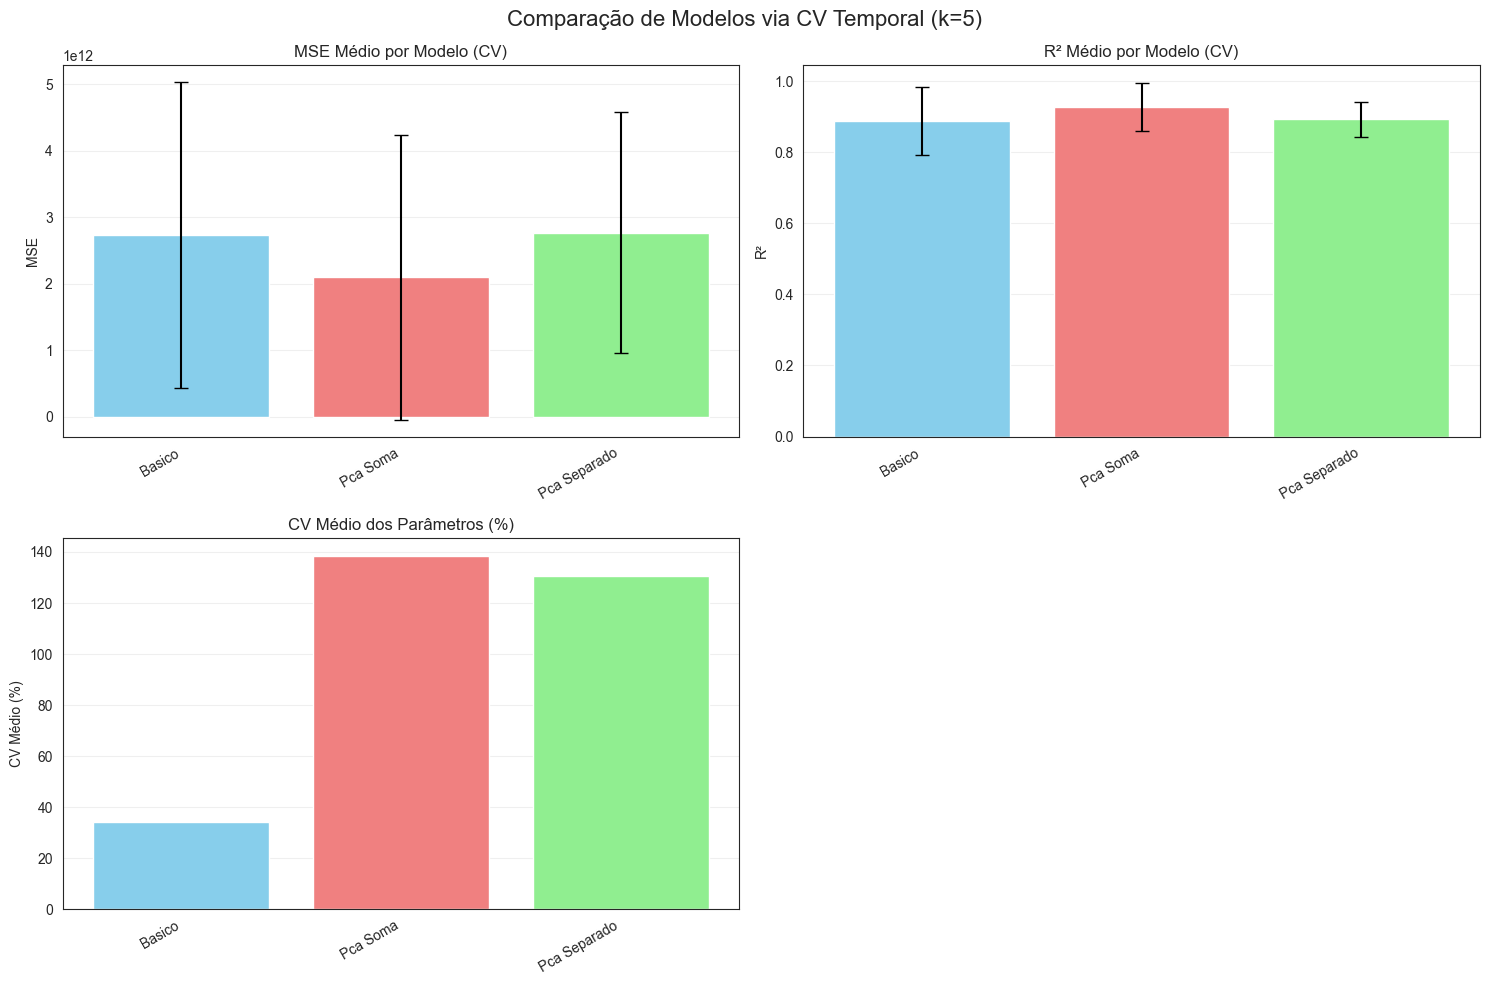

In [ ]:
resultados_completos = executar_modelagem_com_pca_estabilizada_corrigida(
    new_df_brasil_wide=new_df_brasil_wide,
    population_col='Population, total', 
    growth_col_for_corr='Population growth (annual %)', 
    num_top_corr_indicators=3, 
    n_pca_components=1,        
    k_folds=5,                 
    test_size_global=0.2,      
    random_state_global=42,    
    regularization_strength=0.01 
)


### PCA_soma

In [ ]:
def validacao_cruzada_rolante_pca_soma(df, indicadores_selecionados, population_col='Population, total', 
                                        n_components=3, n_splits=5, min_train_size=10):
    """
    Validação cruzada rolante para modelo Richards com PCA
    
    Parâmetros:
    -----------
    df : DataFrame
        DataFrame com os dados
    indicadores_selecionados : list
        Lista com nomes das colunas dos indicadores
    population_col : str
        Nome da coluna da população
    n_components : int
        Número de componentes PCA a usar
    n_splits : int
        Número de splits para validação cruzada
    min_train_size : int
        Tamanho mínimo do conjunto de treino
    """
    
    # Preparar dados
    df_limpo = df[indicadores_selecionados + [population_col]].dropna()
    anos = df_limpo.index.values.astype(float)
    X = anos - anos.min()
    y = df_limpo[population_col].values.astype(float)
    indicadores_raw = df_limpo[indicadores_selecionados].values.astype(float)
    
    if indicadores_raw.ndim == 1:
        indicadores_raw = indicadores_raw.reshape(-1, 1)
    
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=3)
    
    metricas_folds = {'MSE': [], 'RMSE': [], 'R2': []}
    fold_results = []
    
    print(f"Executando validação cruzada rolante com PCA ({n_components} componentes) e {n_splits} folds...")
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        if len(train_idx) < min_train_size:
            print(f"Fold {fold+1}: Poucos dados de treino ({len(train_idx)}), pulando...")
            continue
            
        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]
        indicadores_train_fold = indicadores_raw[train_idx]
        indicadores_test_fold = indicadores_raw[test_idx]
        
        # Padronizar indicadores
        scaler = StandardScaler()
        indicadores_train_scaled = scaler.fit_transform(indicadores_train_fold)
        indicadores_test_scaled = scaler.transform(indicadores_test_fold)
        
        # Aplicar PCA
        pca = PCA(n_components=n_components)
        pca_train = pca.fit_transform(indicadores_train_scaled)
        pca_test = pca.transform(indicadores_test_scaled)
        
        try:
            # Ajustar modelo com componentes PCA
            params_fold, _ = ajustar_modelo_richards_com_pca_soma(
                X_train_fold, y_train_fold, pca_train
            )
            
            # Fazer predições
            y_pred_test_fold = modelo_richards_com_pca_soma(
                X_test_fold, *params_fold, *pca_test.T.flatten()
            )
            
            # Calcular métricas
            mse = mean_squared_error(y_test_fold, y_pred_test_fold)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test_fold, y_pred_test_fold)
            
            metricas_folds['MSE'].append(mse)
            metricas_folds['RMSE'].append(rmse)
            metricas_folds['R2'].append(r2)
            
            # Calcular variância explicada pelo PCA neste fold
            variancia_explicada = pca.explained_variance_ratio_
            variancia_total = np.sum(variancia_explicada)
            
            fold_results.append({
                'fold': fold + 1,
                'train_size': len(train_idx),
                'test_size': len(test_idx),
                'train_years': f"{anos[train_idx].min():.0f}-{anos[train_idx].max():.0f}",
                'test_years': f"{anos[test_idx].min():.0f}-{anos[test_idx].max():.0f}",
                'MSE': mse,
                'RMSE': rmse,
                'R2': r2,
                'params': params_fold,
                'y_true': y_test_fold,
                'y_pred': y_pred_test_fold,
                'anos_test': anos[test_idx],
                'pca_variance_explained': variancia_explicada,
                'pca_total_variance': variancia_total,
                'pca_components': pca_test
            })
            
            print(f"Fold {fold+1}: MSE={mse:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}, "
                  f"Var.Expl.PCA={variancia_total:.3f}")
            
        except Exception as e:
            print(f"Erro no fold {fold+1}: {e}")
            continue
    
    if not metricas_folds['MSE']:
        print("Nenhum fold foi executado com sucesso!")
        return None
    
    # Calcular estatísticas
    estatisticas = {}
    for metrica in ['MSE', 'RMSE', 'R2']:
        valores = np.array(metricas_folds[metrica])
        estatisticas[metrica] = {
            'media': np.mean(valores),
            'std': np.std(valores),
            'min': np.min(valores),
            'max': np.max(valores),
            'valores': valores
        }
    
    # Estatísticas sobre variância explicada pelo PCA
    variancias_pca = [r['pca_total_variance'] for r in fold_results]
    estatisticas['PCA_variance'] = {
        'media': np.mean(variancias_pca),
        'std': np.std(variancias_pca),
        'min': np.min(variancias_pca),
        'max': np.max(variancias_pca),
        'valores': np.array(variancias_pca)
    }
    
    print("\n=== RESUMO DA VALIDAÇÃO CRUZADA ROLANTE COM PCA ===")
    print(f"Número de folds executados: {len(metricas_folds['MSE'])}")
    print(f"Componentes PCA utilizados: {n_components}")
    for metrica in ['MSE', 'RMSE', 'R2']:
        stats = estatisticas[metrica]
        print(f"{metrica}: {stats['media']:.4f} ± {stats['std']:.4f} (min: {stats['min']:.4f}, max: {stats['max']:.4f})")
    
    pca_stats = estatisticas['PCA_variance']
    print(f"Variância explicada PCA: {pca_stats['media']:.4f} ± {pca_stats['std']:.4f} "
          f"(min: {pca_stats['min']:.4f}, max: {pca_stats['max']:.4f})")
    
    plotar_resultados_cv_pca(fold_results, estatisticas, n_components)
    
    return {
        'estatisticas': estatisticas,
        'fold_results': fold_results,
        'metricas_por_fold': metricas_folds,
        'n_components': n_components
    }


def plotar_resultados_cv_pca(fold_results, estatisticas, n_components):
    """
    Plotar resultados da validação cruzada com PCA
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Boxplot das métricas
    axes[0,0].boxplot([estatisticas['MSE']['valores'], 
                       estatisticas['RMSE']['valores'], 
                       estatisticas['R2']['valores']], 
                      labels=['MSE', 'RMSE', 'R²'])
    axes[0,0].set_title('Distribuição das Métricas por Fold')
    axes[0,0].grid(True, alpha=0.3)
    
    # R² por fold
    folds = [r['fold'] for r in fold_results]
    r2_values = [r['R2'] for r in fold_results]
    axes[0,1].plot(folds, r2_values, 'o-', linewidth=2, markersize=8)
    axes[0,1].axhline(y=estatisticas['R2']['media'], color='red', linestyle='--', 
                      label=f"Média: {estatisticas['R2']['media']:.4f}")
    axes[0,1].fill_between(folds, 
                           estatisticas['R2']['media'] - estatisticas['R2']['std'],
                           estatisticas['R2']['media'] + estatisticas['R2']['std'],
                           alpha=0.2, color='red')
    axes[0,1].set_title('R² por Fold')
    axes[0,1].set_xlabel('Fold')
    axes[0,1].set_ylabel('R²')
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].legend()
    
    # Variância explicada pelo PCA por fold
    pca_variances = [r['pca_total_variance'] for r in fold_results]
    axes[0,2].plot(folds, pca_variances, 'o-', linewidth=2, markersize=8, color='green')
    axes[0,2].axhline(y=estatisticas['PCA_variance']['media'], color='red', linestyle='--', 
                      label=f"Média: {estatisticas['PCA_variance']['media']:.4f}")
    axes[0,2].set_title(f'Variância Explicada PCA ({n_components} comp.)')
    axes[0,2].set_xlabel('Fold')
    axes[0,2].set_ylabel('Variância Explicada')
    axes[0,2].grid(True, alpha=0.3)
    axes[0,2].legend()
    
    # Predições vs Observado por fold (primeiros 3 folds)
    for i, resultado in enumerate(fold_results[:3]):
        axes[1,0].scatter(resultado['anos_test'], resultado['y_true'], 
                         label=f'Fold {resultado["fold"]} - Observado', alpha=0.7)
        axes[1,0].plot(resultado['anos_test'], resultado['y_pred'], 
                      label=f'Fold {resultado["fold"]} - Predito', linewidth=2)
    axes[1,0].set_title('Predições vs Observado (Primeiros 3 Folds)')
    axes[1,0].set_xlabel('Ano')
    axes[1,0].set_ylabel('População')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # Scatter plot predito vs observado (todos os folds)
    all_true = np.concatenate([r['y_true'] for r in fold_results])
    all_pred = np.concatenate([r['y_pred'] for r in fold_results])
    axes[1,1].scatter(all_true, all_pred, alpha=0.6)
    min_val, max_val = min(all_true.min(), all_pred.min()), max(all_true.max(), all_pred.max())
    axes[1,1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[1,1].set_title('Predito vs Observado (Todos os Folds)')
    axes[1,1].set_xlabel('Observado')
    axes[1,1].set_ylabel('Predito')
    axes[1,1].grid(True, alpha=0.3)
    
    r2_total = r2_score(all_true, all_pred)
    axes[1,1].text(0.05, 0.95, f'R² Total: {r2_total:.4f}', 
                   transform=axes[1,1].transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Heatmap da variância explicada por componente PCA
    if len(fold_results) > 0:
        # Média da variância explicada por componente em todos os folds
        variance_components = np.array([r['pca_variance_explained'] for r in fold_results])
        mean_variance = np.mean(variance_components, axis=0)
        
        im = axes[1,2].bar(range(1, n_components+1), mean_variance, color='skyblue', alpha=0.7)
        axes[1,2].set_title('Variância Explicada por Componente PCA (Média)')
        axes[1,2].set_xlabel('Componente PCA')
        axes[1,2].set_ylabel('Variância Explicada')
        axes[1,2].grid(True, alpha=0.3)
        
        # Adicionar valores no topo das barras
        for i, v in enumerate(mean_variance):
            axes[1,2].text(i+1, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()


def ajustar_modelo_richards_com_pca_soma(t, y, pca_components):
    """
    Ajustar modelo Richards com componentes PCA
    
    Parâmetros:
    -----------
    t : array
        Valores de tempo
    y : array  
        Valores da população
    pca_components : array
        Componentes PCA (shape: n_samples x n_components)
    """
    
    def objective(params):
        try:
            y_pred = modelo_richards_com_pca_soma(t, *params, *pca_components.T.flatten())
            if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
                return 1e10
            return np.sum((y - y_pred) ** 2)
        except:
            return 1e10
    
    # Estimativas iniciais
    K_base_init = np.max(y) * 1.2
    r_base_init = 0.1
    v_base_init = 1.0
    t0_base_init = np.mean(t)
    
    # Coeficientes iniciais (pequenos)
    coef_init = 0.1
    
    initial_params = [
        K_base_init, coef_init,    # K_base, K_coef
        r_base_init, coef_init,    # r_base, r_coef  
        v_base_init, coef_init,    # v_base, v_coef
        t0_base_init, coef_init    # t0_base, t0_coef
    ]
    
    # Bounds para os parâmetros
    bounds = [
        (y.max() * 0.5, y.max() * 10),   # K_base
        (-1, 1),                         # K_coef
        (0.001, 1.0),                    # r_base
        (-0.5, 0.5),                     # r_coef
        (0.001, 10),                     # v_base
        (-1, 1),                         # v_coef
        (t.min() - 10, t.max() + 10),    # t0_base
        (-5, 5)                          # t0_coef
    ]
    
    try:
        result = minimize(objective, initial_params, bounds=bounds, method='L-BFGS-B')
        
        if result.success:
            return result.x, result.fun
        else:
            # Tentar com método diferente
            result2 = minimize(objective, initial_params, method='Powell')
            return result2.x, result2.fun
            
    except Exception as e:
        print(f"Erro no ajuste: {e}")
        return initial_params, 1e10

In [ ]:
indicadores_para_pca = [
    'Adjusted net national income (constant 2015 US$)',
    'Net secondary income (BoP, current US$)',
    'Grants, excluding technical cooperation (BoP, current US$)',
    'Merchandise imports from low- and middle-income economies in Latin America & the Caribbean (% of total merchandise imports)',
    'Net bilateral aid flows from DAC donors, Belgium (current US$)',
    'Multilateral debt service (TDS, current US$)',
    'Claims on central government, etc. (% GDP)',
    'Adjusted savings: education expenditure (% of GNI)'
]


Executando validação cruzada rolante com PCA (1 componentes) e 5 folds...
Fold 1: MSE=27972714913.19, RMSE=167250.46, R²=0.9837, Var.Expl.PCA=0.755
Fold 2: MSE=1155191496489.96, RMSE=1074798.35, R²=0.3269, Var.Expl.PCA=0.754
Fold 3: MSE=57485800430.83, RMSE=239761.97, R²=0.9624, Var.Expl.PCA=0.699
Fold 4: MSE=84215405307.43, RMSE=290198.91, R²=0.9226, Var.Expl.PCA=0.683
Fold 5: MSE=1810610149987.02, RMSE=1345589.15, R²=-3.2914, Var.Expl.PCA=0.660

=== RESUMO DA VALIDAÇÃO CRUZADA ROLANTE COM PCA ===
Número de folds executados: 5
Componentes PCA utilizados: 1
MSE: 627095113425.6875 ± 729069876885.4407 (min: 27972714913.1913, max: 1810610149987.0237)
RMSE: 623519.7652 ± 488178.4672 (min: 167250.4556, max: 1345589.1461)
R2: -0.0192 ± 1.6543 (min: -3.2914, max: 0.9837)
Variância explicada PCA: 0.7102 ± 0.0382 (min: 0.6599, max: 0.7552)


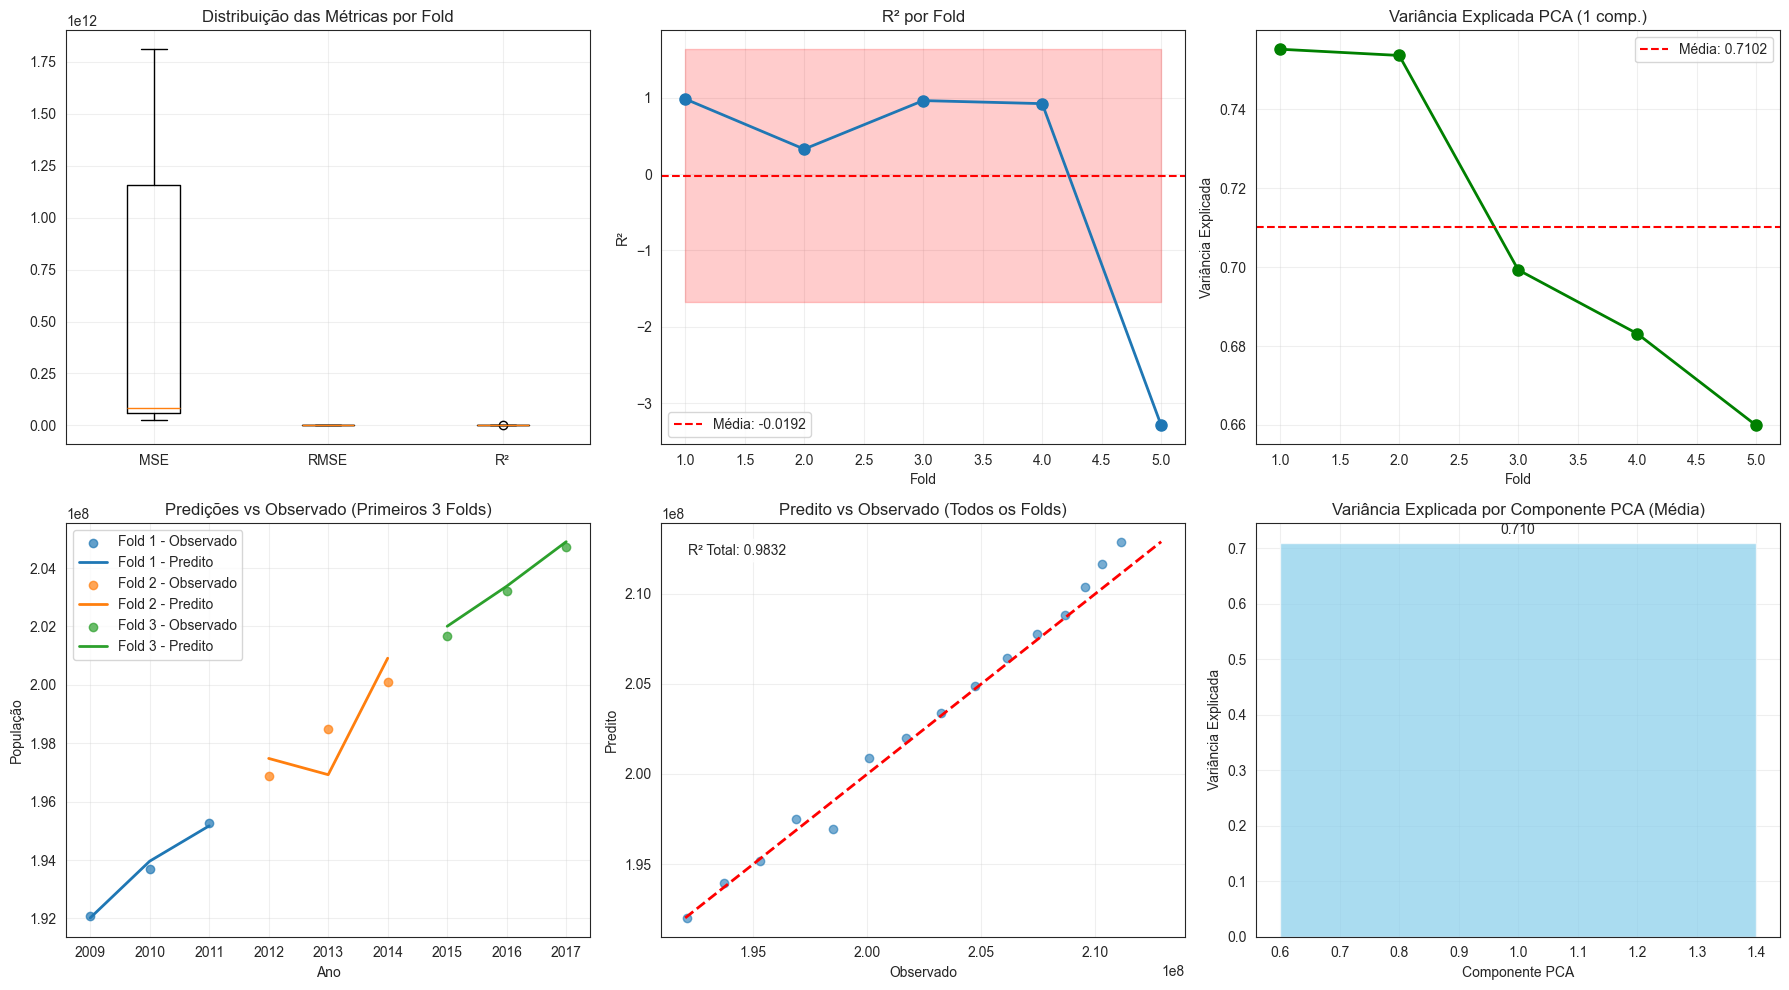

In [ ]:
# Exemplo de uso
resultados = validacao_cruzada_rolante_pca_soma(
    df=new_df_brasil_wide,
    indicadores_selecionados= indicadores_para_pca,
    population_col='Population, total',
    n_components=1,
    n_splits=5
)

### PCA seletivo nos parametros

In [ ]:
def modelo_richards_com_pca_soma_seletivo(t, K_base, r_base, v_base, t0_base, 
                                           K_c_sum=None, r_c_sum=None, v_c_sum=None, t0_c_sum=None,
                                           *pca_components_flat):
    t_arr = np.array(t, dtype=float)
    if t_arr.size == 0:
        return np.array([])
    
    pc1_effect = np.zeros_like(t_arr, dtype=float)
    if len(pca_components_flat) > 0:
        if len(pca_components_flat) != len(t_arr):
            raise ValueError("Shape pca_components_flat inconsistente")
        pc1_effect = np.array(pca_components_flat)
    
    K = K_base + (K_c_sum * pc1_effect if K_c_sum is not None else 0)
    r = r_base + (r_c_sum * pc1_effect if r_c_sum is not None else 0)
    v = v_base + (v_c_sum * pc1_effect if v_c_sum is not None else 0)
    t0 = t0_base + (t0_c_sum * pc1_effect if t0_c_sum is not None else 0)
    
    K = np.maximum(K, 1e-9)
    r = np.clip(r, 0.001, 1.0)
    v = np.maximum(v, 0.001)
    
    return modelo_richards(t_arr, K, r, v, t0)

def ajustar_modelo_richards_com_pca_soma_seletivo(X, y, pca_components, 
                                                  influencia_K=False, influencia_r=False,
                                                  influencia_v=False, influencia_t0=False):
    pc1_flat = pca_components[:, 0].flatten()
    
    param_names = ['K_base', 'r_base', 'v_base', 't0_base']
    p0 = [y.max()*0.8, 0.02, 0.5, X.mean() if X.size > 0 else 0]
    bounds_lower = [y.max()*0.1, 0.001, 0.001, X.min() if X.size > 0 else -np.inf]
    bounds_upper = [y.max()*2.0, 0.5, 10, X.max() if X.size > 0 else np.inf]
    
    coef_mapping = []
    if influencia_K:
        param_names.append('K_c_sum')
        p0.append(0.001)
        bounds_lower.append(-0.5)
        bounds_upper.append(0.5)
        coef_mapping.append('K_c_sum')
    else:
        coef_mapping.append(None)
    
    if influencia_r:
        param_names.append('r_c_sum')
        p0.append(0.0001)
        bounds_lower.append(-0.05)
        bounds_upper.append(0.05)
        coef_mapping.append('r_c_sum')
    else:
        coef_mapping.append(None)
    
    if influencia_v:
        param_names.append('v_c_sum')
        p0.append(0.001)
        bounds_lower.append(-0.05)
        bounds_upper.append(0.05)
        coef_mapping.append('v_c_sum')
    else:
        coef_mapping.append(None)
    
    if influencia_t0:
        param_names.append('t0_c_sum')
        p0.append(0.001)
        bounds_lower.append(-0.5)
        bounds_upper.append(0.5)
        coef_mapping.append('t0_c_sum')
    else:
        coef_mapping.append(None)
    
    for i in range(len(p0)):
        p0[i] = np.clip(p0[i], bounds_lower[i], bounds_upper[i])
    
    def modelo_wrapper(t_w, *params):
        K_base, r_base, v_base, t0_base = params[:4]
        coef_params = params[4:] if len(params) > 4 else []
        
        coef_idx = 0
        K_c_sum = coef_params[coef_idx] if coef_mapping[0] is not None and coef_idx < len(coef_params) else None
        if coef_mapping[0] is not None:
            coef_idx += 1
        
        r_c_sum = coef_params[coef_idx] if coef_mapping[1] is not None and coef_idx < len(coef_params) else None
        if coef_mapping[1] is not None:
            coef_idx += 1
        
        v_c_sum = coef_params[coef_idx] if coef_mapping[2] is not None and coef_idx < len(coef_params) else None
        if coef_mapping[2] is not None:
            coef_idx += 1
        
        t0_c_sum = coef_params[coef_idx] if coef_mapping[3] is not None and coef_idx < len(coef_params) else None
        
        return modelo_richards_com_pca_soma_seletivo(t_w, K_base, r_base, v_base, t0_base,
                                                    K_c_sum, r_c_sum, v_c_sum, t0_c_sum,
                                                    *pc1_flat)
    
    try:
        params, pcov = curve_fit(modelo_wrapper, X, y, p0=p0, method='trf', 
                               maxfev=30000, bounds=(bounds_lower, bounds_upper))
        param_errors = np.sqrt(np.diag(pcov))
    except Exception as e:
        print(f"Erro PCA Soma Seletivo: {e}. p0 usado.")
        params = np.array(p0)
        param_errors = np.full_like(params, np.inf)
    
    y_pred = modelo_wrapper(X, *params)
    return params, y_pred, param_errors, param_names

def executar_modelagem_pca_soma_seletivo(new_df_brasil_wide,
                                        population_col='Population, total',
                                        growth_col_for_corr='Population growth (annual %)',
                                        num_top_corr_indicators=8,
                                        k_folds=5,
                                        test_size_global=0.2,
                                        random_state_global=42):
    
    print("=== ANÁLISE PCA SOMA SELETIVO COM 1 PC ===")
    
    df_para_selecao_indicadores = new_df_brasil_wide.dropna(subset=[population_col, growth_col_for_corr])
    anos_para_selecao = df_para_selecao_indicadores.index.values.astype(float)
    split_idx_selecao = int(len(anos_para_selecao) * (1 - test_size_global))
    df_treino_para_selecao_indicadores = df_para_selecao_indicadores.iloc[:split_idx_selecao]

    correlacoes = df_treino_para_selecao_indicadores.corr(numeric_only=True)[growth_col_for_corr].dropna().sort_values(key=abs, ascending=False)
    indicadores_candidatos = [
        col for col in correlacoes.index if col != growth_col_for_corr and col != population_col
    ][:num_top_corr_indicators]

    if not indicadores_candidatos:
        print("AVISO: Nenhum indicador candidato selecionado.")
        indicadores_candidatos = []

    dados_globais = preparar_dados_para_modelagem(new_df_brasil_wide, 
                                                 indicadores_candidatos, 
                                                 population_col, 
                                                 test_size_global, 
                                                 random_state_global)

    pca_aplicado_global = False
    if dados_globais['indicators_train'].shape[1] > 0:
        print("Aplicando PCA com 1 componente")
        pca_gerador_global = PCA(n_components=1, random_state=random_state_global)
        pca_train_global = pca_gerador_global.fit_transform(dados_globais['indicators_train'])
        pca_test_global = pca_gerador_global.transform(dados_globais['indicators_test'])
        print(f"Variância explicada PC1: {pca_gerador_global.explained_variance_ratio_[0]:.3f} ({pca_gerador_global.explained_variance_ratio_[0]*100:.1f}%)")
        pca_aplicado_global = True

    if not pca_aplicado_global:
        print("PCA não aplicado. Retornando.")
        return None

    print(f"\nCross Validation Temporal (TimeSeriesSplit, n_splits={k_folds})")
    tscv = TimeSeriesSplit(n_splits=k_folds)
    
    variacoes = [
        {'nome': 'pca_soma_K', 'influencia': {'influencia_K': True}},
        {'nome': 'pca_soma_r', 'influencia': {'influencia_r': True}},
        {'nome': 'pca_soma_Kr', 'influencia': {'influencia_K': True, 'influencia_r': True}}
    ]
    
    resultados_cv = {'basico': {'mse':[],'r2':[],'params':[],'param_errors':[]}}
    for var in variacoes:
        resultados_cv[var['nome']] = {'mse':[],'r2':[],'params':[],'param_errors':[],'param_names':[]}

    for fold, (train_fold_idx, val_fold_idx) in enumerate(tscv.split(dados_globais['X_train'])):
        print(f"\nFold {fold+1}/{k_folds}")
        X_tf, X_vf = dados_globais['X_train'][train_fold_idx], dados_globais['X_train'][val_fold_idx]
        y_tf, y_vf = dados_globais['y_train'][train_fold_idx], dados_globais['y_train'][val_fold_idx]
        ind_tf_raw = dados_globais['indicators_train'][train_fold_idx]
        ind_vf_raw = dados_globais['indicators_train'][val_fold_idx]
        
        try:
            p_bas, _, err_bas = ajustar_modelo_richards_basico(X_tf, y_tf)
            y_p_bas_v = modelo_richards(X_vf, *p_bas)
            resultados_cv['basico']['mse'].append(mean_squared_error(y_vf, y_p_bas_v))
            resultados_cv['basico']['r2'].append(r2_score(y_vf, y_p_bas_v))
            resultados_cv['basico']['params'].append(p_bas)
            resultados_cv['basico']['param_errors'].append(err_bas)
        except Exception as e:
            print(f"Erro básico F{fold+1}: {e}")
            resultados_cv['basico']['mse'].append(np.nan)
            resultados_cv['basico']['r2'].append(np.nan)
            resultados_cv['basico']['params'].append(np.full(4, np.nan))
            resultados_cv['basico']['param_errors'].append(np.full(4, np.nan))

        if ind_tf_raw.shape[1] > 0 and ind_tf_raw.shape[0] > 0:
            scaler_fold = StandardScaler()
            ind_tf_scaled_fold = scaler_fold.fit_transform(ind_tf_raw)
            ind_vf_scaled_fold = scaler_fold.transform(ind_vf_raw)
            
            pca_f = PCA(n_components=1, random_state=random_state_global)
            pca_tf = pca_f.fit_transform(ind_tf_scaled_fold)
            pca_vf = pca_f.transform(ind_vf_scaled_fold)
            
            for var in variacoes:
                try:
                    params, _, param_errors, param_names = ajustar_modelo_richards_com_pca_soma_seletivo(
                        X_tf, y_tf, pca_tf, **var['influencia']
                    )
                    
                    def pred_wrapper(X_pred, pca_pred):
                        K_base, r_base, v_base, t0_base = params[:4]
                        coef_params = params[4:] if len(params) > 4 else []
                        
                        coef_idx = 0
                        K_c_sum = coef_params[coef_idx] if var['influencia'].get('influencia_K', False) and coef_idx < len(coef_params) else None
                        if var['influencia'].get('influencia_K', False):
                            coef_idx += 1
                        
                        r_c_sum = coef_params[coef_idx] if var['influencia'].get('influencia_r', False) and coef_idx < len(coef_params) else None
                        if var['influencia'].get('influencia_r', False):
                            coef_idx += 1
                        
                        v_c_sum = coef_params[coef_idx] if var['influencia'].get('influencia_v', False) and coef_idx < len(coef_params) else None
                        if var['influencia'].get('influencia_v', False):
                            coef_idx += 1
                        
                        t0_c_sum = coef_params[coef_idx] if var['influencia'].get('influencia_t0', False) and coef_idx < len(coef_params) else None
                        
                        return modelo_richards_com_pca_soma_seletivo(
                            X_pred, K_base, r_base, v_base, t0_base,
                            K_c_sum, r_c_sum, v_c_sum, t0_c_sum,
                            *pca_pred[:, 0].flatten()
                        )
                    
                    y_pred_val = pred_wrapper(X_vf, pca_vf)
                    
                    resultados_cv[var['nome']]['mse'].append(mean_squared_error(y_vf, y_pred_val))
                    resultados_cv[var['nome']]['r2'].append(r2_score(y_vf, y_pred_val))
                    resultados_cv[var['nome']]['params'].append(params)
                    resultados_cv[var['nome']]['param_errors'].append(param_errors)
                    if fold == 0:
                        resultados_cv[var['nome']]['param_names'] = param_names
                        
                except Exception as e:
                    print(f"Erro {var['nome']} F{fold+1}: {e}")
                    resultados_cv[var['nome']]['mse'].append(np.nan)
                    resultados_cv[var['nome']]['r2'].append(np.nan)
                    expected_params = 4 + sum(var['influencia'].values())
                    resultados_cv[var['nome']]['params'].append(np.full(expected_params, np.nan))
                    resultados_cv[var['nome']]['param_errors'].append(np.full(expected_params, np.nan))

    print("\n=== ANÁLISE DE ESTABILIDADE DOS COEFICIENTES ===")
    for modelo_nome, resultado in resultados_cv.items():
        if len(resultado.get('params', [])) > 0:
            params_validos = [p for p in resultado['params'] if not np.all(np.isnan(p))]
            if len(params_validos) > 1:
                params_array = np.array(params_validos)
                cv_coeff = calcular_cv_robusto(params_array)
                
                print(f"\n{modelo_nome.upper()}:")
                mse_validos = [m for m in resultado['mse'] if not np.isnan(m)]
                r2_validos = [r for r in resultado['r2'] if not np.isnan(r)]

                if mse_validos:
                    print(f" - MSE médio: {np.mean(mse_validos):.2e} ± {np.std(mse_validos):.2e}")
                if r2_validos:
                    print(f" - R² médio: {np.mean(r2_validos):.4f} ± {np.std(r2_validos):.4f}")
                
                param_names = resultado.get('param_names', [f"P{i+1}" for i in range(len(cv_coeff))])
                if len(param_names) != len(cv_coeff):
                    param_names = [f"P{i+1}" for i in range(len(cv_coeff))]

                print(" - CV dos parâmetros (individual):")
                for name_idx, cv_val in enumerate(cv_coeff):
                    if np.isfinite(cv_val):
                        print(f"   - {param_names[name_idx]}: {cv_val*100:.2f}%")
                    else:
                        print(f"   - {param_names[name_idx]}: N/A")
                
                cv_finitos = cv_coeff[np.isfinite(cv_coeff)]
                if len(cv_finitos) > 0:
                    print(f" - CV médio dos parâmetros: {np.mean(cv_finitos)*100:.2f}%")

    modelos_validos_plot = [m for m in resultados_cv.keys() 
                           if len(resultados_cv[m].get('mse',[])) > 0 
                           and not all(np.isnan(val) for val in resultados_cv[m]['mse'])]
    
    if modelos_validos_plot:
        plt.figure(figsize=(15, 10))
        bar_colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'lightsalmon', 'cyan'][:len(modelos_validos_plot)]

        plt.subplot(2,2,1)
        mse_means = [np.nanmean(resultados_cv[modelo]['mse']) for modelo in modelos_validos_plot]
        mse_stds = [np.nanstd(resultados_cv[modelo]['mse']) for modelo in modelos_validos_plot]
        plt.bar(range(len(mse_means)), mse_means, yerr=mse_stds, capsize=5, color=bar_colors)
        plt.xticks(range(len(mse_means)), [m.replace("_"," ").title() for m in modelos_validos_plot], rotation=30, ha="right")
        plt.title('MSE Médio por Modelo (CV)')
        plt.ylabel('MSE')
        plt.grid(True, alpha=0.3, axis='y')

        plt.subplot(2,2,2)
        r2_means = [np.nanmean(resultados_cv[modelo]['r2']) for modelo in modelos_validos_plot]
        r2_stds = [np.nanstd(resultados_cv[modelo]['r2']) for modelo in modelos_validos_plot]
        plt.bar(range(len(r2_means)), r2_means, yerr=r2_stds, capsize=5, color=bar_colors)
        plt.xticks(range(len(r2_means)), [m.replace("_"," ").title() for m in modelos_validos_plot], rotation=30, ha="right")
        plt.title('R² Médio por Modelo (CV)')
        plt.ylabel('R²')
        plt.grid(True, alpha=0.3, axis='y')

        plt.subplot(2,2,3)
        cv_means_plot_vals = []
        for modelo_nome in modelos_validos_plot:
            params_validos = [p for p in resultados_cv[modelo_nome]['params'] if not np.all(np.isnan(p))]
            if len(params_validos) > 1:
                params_array = np.array(params_validos)
                cv_coeff = calcular_cv_robusto(params_array)
                cv_finitos = cv_coeff[np.isfinite(cv_coeff)]
                if len(cv_finitos) > 0:
                    cv_means_plot_vals.append(np.mean(cv_finitos) * 100)
                else:
                    cv_means_plot_vals.append(np.nan)
            else:
                cv_means_plot_vals.append(np.nan)
        
        plt.bar(range(len(cv_means_plot_vals)), cv_means_plot_vals, color=bar_colors)
        plt.xticks(range(len(cv_means_plot_vals)), [m.replace("_"," ").title() for m in modelos_validos_plot], rotation=30, ha="right")
        plt.title('CV Médio dos Parâmetros (%)')
        plt.ylabel('CV Médio (%)')
        plt.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout(rect=[0,0,1,0.96])
        plt.suptitle(f"Comparação PCA Soma Seletivo (1 PC) via CV Temporal (k={k_folds})", fontsize=16)
        plt.show()

    return {
        'resultados_cv': resultados_cv,
        'pca_global_object': pca_gerador_global,
        'dados_globais_usados': dados_globais,
        'indicadores_candidatos_finais': indicadores_candidatos
    }

=== ANÁLISE PCA SOMA SELETIVO COM 1 PC ===
Aplicando PCA com 1 componente
Variância explicada PC1: 0.746 (74.6%)

Cross Validation Temporal (TimeSeriesSplit, n_splits=5)

Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5

=== ANÁLISE DE ESTABILIDADE DOS COEFICIENTES ===

BASICO:
 - MSE médio: 2.73e+12 ± 2.30e+12
 - R² médio: 0.8880 ± 0.0956
 - CV dos parâmetros (individual):
   - P1: 14.25%
   - P2: 43.04%
   - P3: 49.86%
   - P4: 29.29%
 - CV médio dos parâmetros: 34.11%

PCA_SOMA_K:
 - MSE médio: 2.73e+12 ± 2.30e+12
 - R² médio: 0.8880 ± 0.0956
 - CV dos parâmetros (individual):
   - K_base: 14.25%
   - r_base: 43.04%
   - v_base: 49.86%
   - t0_base: 29.29%
   - K_c_sum: 29.51%
 - CV médio dos parâmetros: 33.19%

PCA_SOMA_R:
 - MSE médio: 3.08e+12 ± 1.87e+12
 - R² médio: 0.8639 ± 0.0916
 - CV dos parâmetros (individual):
   - K_base: 15.80%
   - r_base: 22.98%
   - v_base: 20.43%
   - t0_base: 50.07%
   - r_c_sum: 123.18%
 - CV médio dos parâmetros: 46.49%

PCA_SOMA_KR:
 - MSE médio:

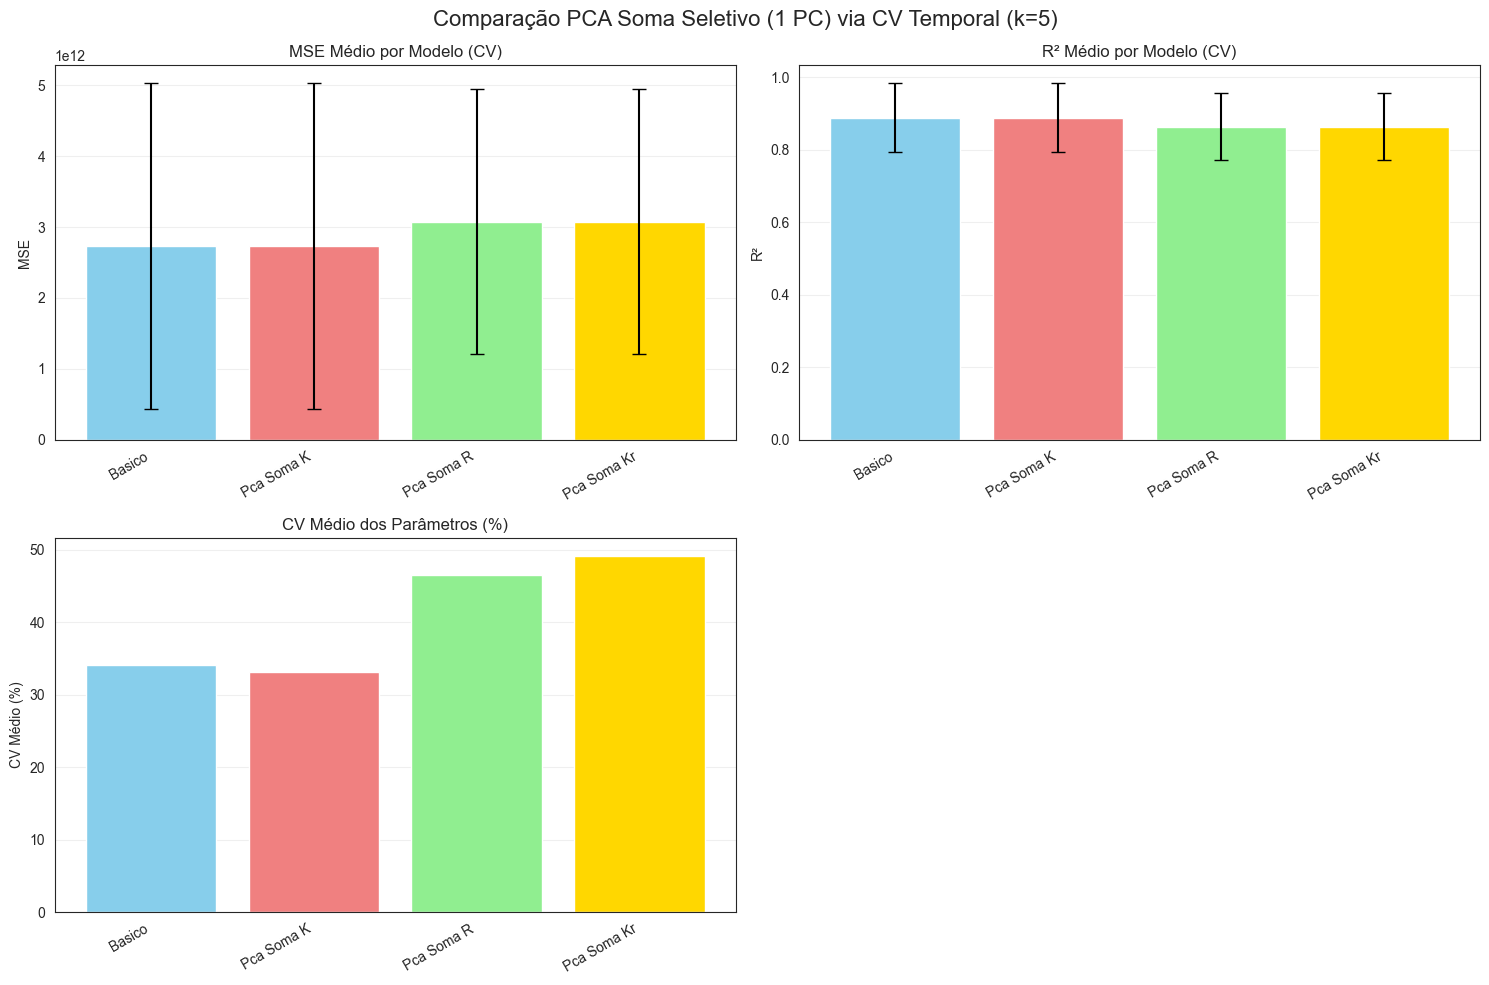

In [ ]:
resultados_pca_seletivo = executar_modelagem_pca_soma_seletivo(
    new_df_brasil_wide=new_df_brasil_wide,
    population_col='Population, total', # Verifique se este é o nome correto da sua coluna de população
    growth_col_for_corr='Population growth (annual %)', # Verifique a coluna para correlação
    num_top_corr_indicators=8,  # Número de indicadores para alimentar o PCA (que resultará em 1 PC)
    k_folds=5,
    test_size_global=0.2,
    random_state_global=42
)

### Validação modelo básico

In [ ]:
def validacao_cruzada_basico(
    df,
    population_col: str = "Population, total",
    n_splits: int = 5,
    min_train_size: int = 10,
):

    df_limpo = df[[population_col]].dropna()
    if df_limpo.empty or len(df_limpo) < n_splits + min_train_size: # Ajuste na condição
        print("Dados insuficientes após limpeza ou para a quantidade de folds.")
        return None

    anos = df_limpo.index.values.astype(float)
    X = anos - anos.min()  # desloca para começar em 0
    y = df_limpo[population_col].values.astype(float)

    # Definir test_size para TimeSeriesSplit, ex: 3 como nos seus outros CVs
    # Se não definir, o último fold terá apenas 1 ponto de teste, o que pode ser pouco.
    # Um test_size pequeno e fixo é geralmente bom para esta aplicação.
    test_size_cv = 3 if len(X) // (n_splits +1) >=3 else max(1, len(X) // (n_splits + 1))


    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size_cv)

    metricas_folds = {"MSE": [], "RMSE": [], "R2": [], "Params_Errors": []} # Adicionado para erros
    fold_results = []

    print(
        f"Executando validação cruzada rolante (Básico) "
        f"com {n_splits} folds..."
    )

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        if len(train_idx) < min_train_size:
            print(
                f"Fold {fold + 1}: "
                f"apenas {len(train_idx)} dados de treino (mínimo = {min_train_size}), pulando..."
            )
            continue

        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]

        try:
            # Ajuste do modelo de Richards BÁSICO -------------------------
            # CORREÇÃO AQUI: Desempacotar os 3 valores retornados
            params_fold, _, param_errors_fold = ajustar_modelo_richards_basico(
                X_train_fold, y_train_fold
            )
            # O segundo valor (y_pred_treino) é ignorado com '_' pois não é usado aqui.
            # param_errors_fold é capturado.

            y_pred_test_fold = modelo_richards(
                X_test_fold, *params_fold  # K, r, v, t0
            )

            # Métricas ----------------------------------------------------
            mse = mean_squared_error(y_test_fold, y_pred_test_fold)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test_fold, y_pred_test_fold)

            metricas_folds["MSE"].append(mse)
            metricas_folds["RMSE"].append(rmse)
            metricas_folds["R2"].append(r2)
            metricas_folds["Params_Errors"].append(param_errors_fold) # Armazenar erros dos params

            fold_results.append(
                {
                    "fold": fold + 1,
                    "train_size": len(train_idx),
                    "test_size": len(test_idx),
                    "train_years": f"{anos[train_idx].min():.0f}-{anos[train_idx].max():.0f}",
                    "test_years": f"{anos[test_idx].min():.0f}-{anos[test_idx].max():.0f}",
                    "MSE": mse,
                    "RMSE": rmse,
                    "R2": r2,
                    "params": params_fold,
                    "param_errors": param_errors_fold, # Adicionar ao resultado do fold
                    "y_true": y_test_fold,
                    "y_pred": y_pred_test_fold,
                    "anos_test": anos[test_idx],
                }
            )

            print(
                f"Fold {fold + 1}:  "
                f"MSE = {mse:.2f},  RMSE = {rmse:.2f},  R² = {r2:.4f}"
            )

        except Exception as e:
            print(f"Erro no fold {fold + 1}: {e}")
            # Adicionar NaNs para manter a estrutura em caso de erro no fold
            metricas_folds["MSE"].append(np.nan)
            metricas_folds["RMSE"].append(np.nan)
            metricas_folds["R2"].append(np.nan)
            metricas_folds["Params_Errors"].append(np.full(4, np.nan)) # Modelo básico tem 4 params

    if not any(np.isfinite(m) for m in metricas_folds["MSE"]): # Checa se há algum resultado válido
        print("Nenhum fold foi executado com sucesso!")
        return None

    estatisticas = {}
    for metrica in ["MSE", "RMSE", "R2"]:
        # Filtrar NaNs antes de calcular estatísticas para evitar RuntimeWarnings
        valores = np.array([v for v in metricas_folds[metrica] if np.isfinite(v)])
        estatisticas[metrica] = {
            "media": np.mean(valores) if valores.size > 0 else np.nan,
            "std": np.std(valores) if valores.size > 1 else 0, # std de 1 elemento é 0
            "min": np.min(valores) if valores.size > 0 else np.nan,
            "max": np.max(valores) if valores.size > 0 else np.nan,
            "valores": valores, # Armazena apenas os valores finitos para boxplot
        }

    print("\n=== RESUMO DA VALIDAÇÃO CRUZADA ROLANTE (BÁSICO) ===")
    num_folds_sucesso = len(estatisticas["MSE"]["valores"])
    print(f"Número de folds executados com sucesso: {num_folds_sucesso}/{n_splits}")
    for metrica in ["MSE", "RMSE", "R2"]:
        stats = estatisticas[metrica]
        print(
            f"{metrica}: {stats['media']:.4f} ± {stats['std']:.4f} "
            f"(min: {stats['min']:.4f}, max: {stats['max']:.4f})"
        )

    # Chamar plotar_resultados_cv apenas se houver resultados e a função estiver definida
    if num_folds_sucesso > 0 and 'plotar_resultados_cv' in globals():
        plotar_resultados_cv(fold_results, estatisticas) # fold_results pode ter NaNs se um fold falhou
                                                        # plotar_resultados_cv precisa ser robusto a isso ou filtrar

    return {
        "estatisticas": estatisticas,
        "fold_results": fold_results, # Contém todos os folds, incluindo os que podem ter falhado parcialmente
        "metricas_por_fold": metricas_folds, # Contém listas de métricas, incluindo NaNs se falhas
    }

Executando validação cruzada rolante (Básico) com 5 folds...
Fold 1:  MSE = 9085160529.02,  RMSE = 95316.11,  R² = 0.9947
Fold 2:  MSE = 16635215000.18,  RMSE = 128977.58,  R² = 0.9903
Fold 3:  MSE = 343207122144.74,  RMSE = 585838.82,  R² = 0.7754
Fold 4:  MSE = 401648902357.81,  RMSE = 633757.76,  R² = 0.6308
Fold 5:  MSE = 121578248770.46,  RMSE = 348680.73,  R² = 0.7118

=== RESUMO DA VALIDAÇÃO CRUZADA ROLANTE (BÁSICO) ===
Número de folds executados com sucesso: 5/5
MSE: 178430929760.4426 ± 164356640921.0535 (min: 9085160529.0241, max: 401648902357.8091)
RMSE: 358514.1985 ± 223379.7198 (min: 95316.1084, max: 633757.7632)
R2: 0.8206 ± 0.1476 (min: 0.6308, max: 0.9947)


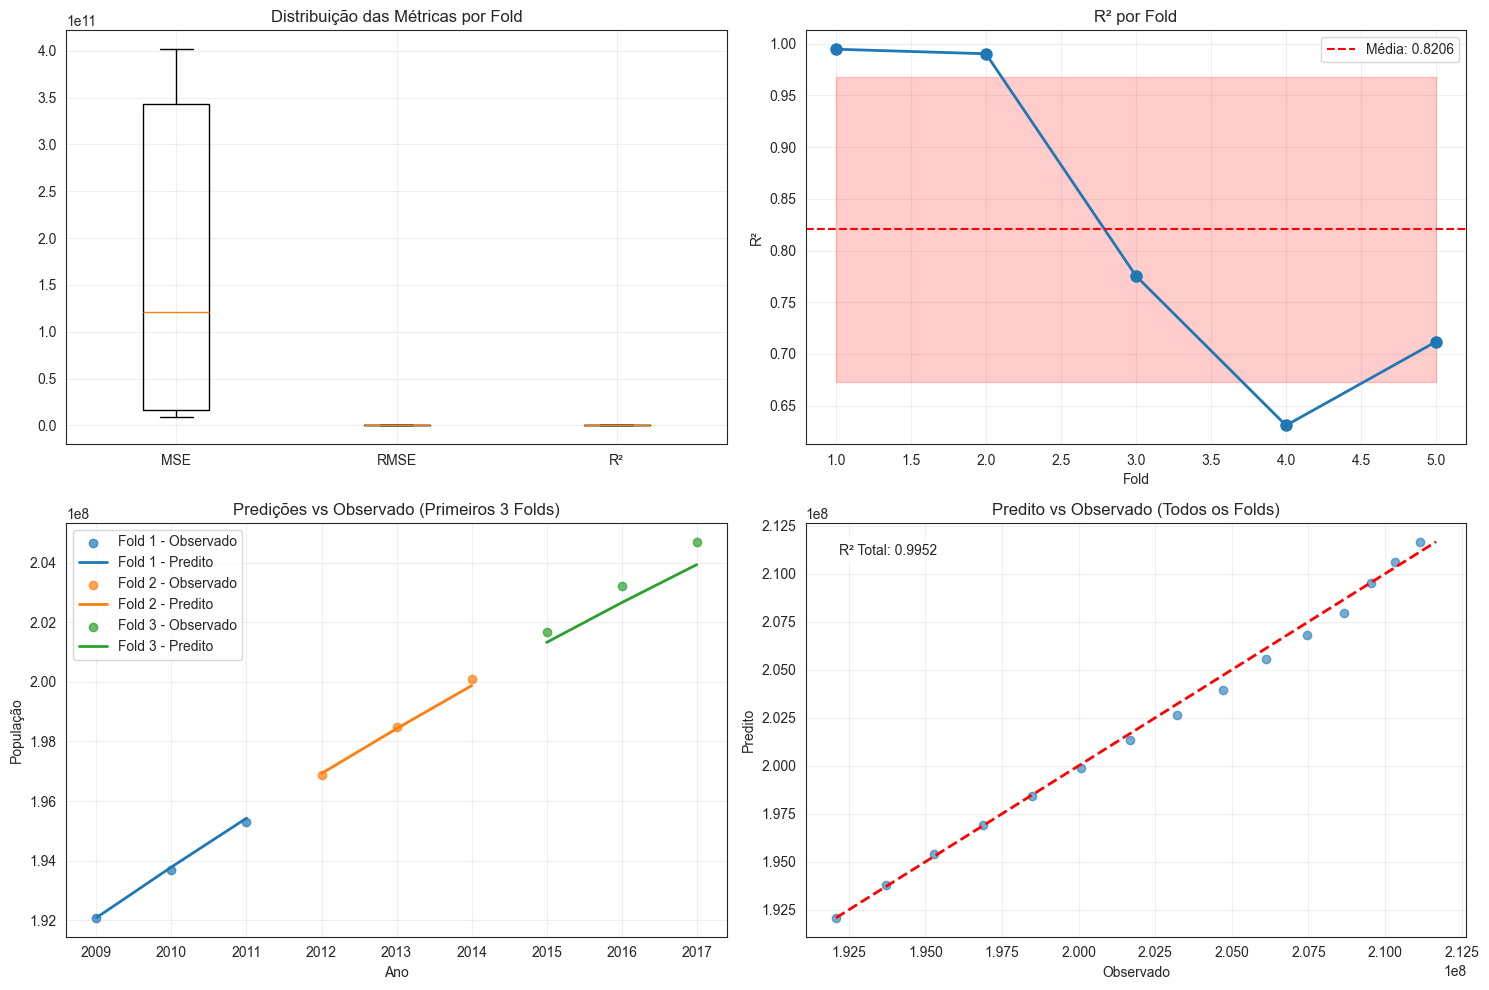

In [ ]:
resultados_cv_basico = validacao_cruzada_basico(
    df=new_df_brasil_wide,      # seu DataFrame indexado por ano
    population_col="Population, total",  # nome da coluna de população
    n_splits=5,                 # quantidade de folds (opcional; default=5)
    min_train_size=10           # tamanho mínimo do bloco de treino (opcional)
)



Folds executados: 5

=== RESUMO POR FOLD ===
 fold train_years test_years  n_train  n_test       RMSE    R2
    1   1970-2008  2009-2011       39       3  95316.108 0.995
    2   1970-2011  2012-2014       42       3 128977.576 0.990
    3   1970-2014  2015-2017       45       3 585838.819 0.775
    4   1970-2017  2018-2020       48       3 633757.763 0.631
    5   1970-2020  2021-2023       51       3 348680.726 0.712

=== FOLD 4 ===  treino 1970-2017  →  teste 2018-2020
 ano      real      pred   erro
2018 206107261 205582224 525037
2019 207455459 206795916 659543
2020 208660842 207957787 703055

=== Indicadores (Fold 4) ===
Indicator Name  Adjusted net national income (constant 2015 US$)  Net secondary income (BoP, current US$)  Grants, excluding technical cooperation (BoP, current US$)  Merchandise imports from low- and middle-income economies in Latin America & the Caribbean (% of total merchandise imports)  Net bilateral aid flows from DAC donors, Belgium (current US$)  Multilat

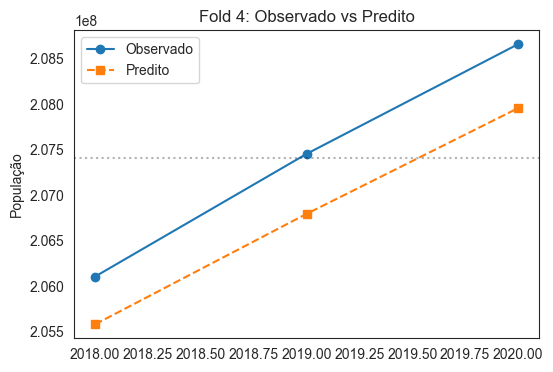

In [ ]:
# Testes extras
if resultados_cv_basico is None:
    raise ValueError("Nenhum resultado retornado — cheque mensagens de erro do passo anterior.")

fold_results = resultados_cv_basico['fold_results']
print(f"\nFolds executados: {len(fold_results)}")

# ----------------------------------------------------------------------
# 1) QUICK SUMMARY por fold  (tudo em texto)
tbl_fold = pd.DataFrame(
    [(f['fold'],
      f['train_years'], f['test_years'],
      f['train_size'],  f['test_size'],
      f['RMSE'], f['R2']) for f in fold_results],
    columns=['fold','train_years','test_years','n_train','n_test','RMSE','R2']
)

print("\n=== RESUMO POR FOLD ===")
print(tbl_fold.to_string(index=False, float_format="%.3f"))

# ----------------------------------------------------------------------
# 2) FOCO NO FOLD 4  (troque fold_id se quiser outro)
fold_id = 4
f4 = next(fr for fr in fold_results if fr['fold'] == fold_id)

print(f"\n=== FOLD {fold_id} ===  treino {f4['train_years']}  →  teste {f4['test_years']}")
df_f4 = pd.DataFrame({
    'ano'  : f4['anos_test'],
    'real' : f4['y_true'],
    'pred' : f4['y_pred']
})
df_f4['erro'] = df_f4['real'] - df_f4['pred']
print(df_f4.to_string(index=False, float_format="%.0f"))

# Gráfico rápido
plt.figure(figsize=(6,4))
plt.plot(df_f4['ano'], df_f4['real'], 'o-', label='Observado')
plt.plot(df_f4['ano'], df_f4['pred'], 's--', label='Predito')
plt.axhline(df_f4['real'].mean(), color='k', ls=':', alpha=.3)
plt.title(f'Fold {fold_id}: Observado vs Predito')
plt.ylabel('População')
plt.legend()
plt.show()

# ----------------------------------------------------------------------
# 3) INDICADORES dos anos de teste do Fold 4
indic_f4 = new_df_brasil_wide.loc[df_f4['ano'], indicadores_selecionados_n8]
print("\n=== Indicadores (Fold 4) ===")
print(indic_f4.round(2).to_string())

# ----------------------------------------------------------------------
# 4) MAPE por fold
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

tbl_fold['MAPE_%'] = [mape(fr['y_true'], fr['y_pred']) for fr in fold_results]
print("\n=== MAPE (%) por fold ===")
print(tbl_fold[['fold','MAPE_%']].to_string(index=False, float_format="%.3f"))

# ----------------------------------------------------------------------
# 5) ESTABILIDADE DOS PARÂMETROS
param_cols_basico = ["K", "r", "v", "t0"]

df_params = pd.DataFrame([
    dict(zip(['fold'] + param_cols_basico, [fr['fold']] + list(fr['params'][:8])))
    for fr in fold_results
])

print("\n=== Parâmetros Richards por fold ===")
print(df_params.to_string(index=False, float_format="%.5f"))

cv = df_params[param_cols_basico].std() / df_params[param_cols_basico].mean() * 100
print("\nCoeficiente de variação (CV %) dos parâmetros:")
print(cv.round(2).to_string())


### Investigação pca_k_soma

In [ ]:
def analisar_pca_soma_k_detalhado(
    resultados_pipeline: dict,
    df_dados_completos_para_plot: pd.DataFrame, # Ex: new_df_brasil_wide completo
    population_col: str = 'Population, total' # Usado para obter y se necessário para plots, não diretamente aqui
):
    """
    Realiza uma análise detalhada do modelo PCA_SOMA_K, focando na
    interpretação do PC1 e seu impacto no parâmetro K.
    Utiliza os objetos PCA e Scaler ajustados no conjunto de treino da pipeline principal.
    """
    print("=== ANÁLISE DETALHADA PCA SOMA K (COM OBJETOS PCA/SCALER DO TREINO) ===\n")

    # 1. Extrair informações necessárias dos resultados da pipeline
    indicadores_usados_no_pca = resultados_pipeline.get('indicadores_candidatos_finais')
    pca_obj_treino = resultados_pipeline.get('pca_global_object')
    dados_globais = resultados_pipeline.get('dados_globais_usados')
    resultados_cv = resultados_pipeline.get('resultados_cv')

    if dados_globais is None or 'scaler' not in dados_globais:
        print("ERRO: Objeto scaler não encontrado nos resultados da pipeline ('dados_globais_usados').")
        return
    scaler_obj_treino = dados_globais['scaler']

    if not indicadores_usados_no_pca:
        print("ERRO: Lista de 'indicadores_candidatos_finais' está vazia ou não foi fornecida.")
        return
    if pca_obj_treino is None:
        print("ERRO: Objeto 'pca_global_object' (PCA ajustado no treino) não foi fornecido.")
        # Se pca_aplicado_global foi False, este objeto pode ser None.
        print("Verifique se o PCA foi aplicado com sucesso na pipeline de modelagem.")
        return
    if scaler_obj_treino is None: # Pode acontecer se não houver indicadores para escalar
        print("AVISO: Objeto scaler é None. Se havia indicadores, o escalonamento pode não ter ocorrido.")
        # Se não há indicadores, PCA também não deveria ter sido aplicado.
        # Se há indicadores mas o scaler é None, os dados para PCA não foram escalados.
        if indicadores_usados_no_pca:
             print("Os indicadores para PCA podem não ter sido escalados. O PC1 pode ter interpretação diferente.")


    print("1. INDICADORES UTILIZADOS PARA GERAR O PC1 (selecionados no treino da pipeline):")
    for i, indicador in enumerate(indicadores_usados_no_pca, 1):
        print(f"{i:2d}. {indicador}")

    # 2. Preparar dados de indicadores do DataFrame completo para plotagem do PC1 e K_dinamico
    #    usando o scaler e pca ajustados no TREINO da pipeline.
    # Assegurar que apenas as colunas de indicadores existam e na ordem correta
    try:
        df_indicadores_completos = df_dados_completos_para_plot[indicadores_usados_no_pca].copy()
    except KeyError as e:
        print(f"ERRO: Um ou mais indicadores de 'indicadores_usados_no_pca' não encontrados em 'df_dados_completos_para_plot': {e}")
        return
        
    df_indicadores_completos.dropna(inplace=True) # Remove linhas com NaN em QUALQUER dos indicadores selecionados

    if df_indicadores_completos.empty:
        print("ERRO: DataFrame de indicadores para plotagem ficou vazio após remover NaNs.")
        return

    anos_completos_plot = df_indicadores_completos.index.values.astype(float)
    
    if scaler_obj_treino and indicadores_usados_no_pca: # Aplica transform se scaler existe e há indicadores
        indicadores_completos_scaled = scaler_obj_treino.transform(df_indicadores_completos.values)
        pc1_valores_completos = pca_obj_treino.transform(indicadores_completos_scaled)[:, 0]
    elif indicadores_usados_no_pca: # Havia indicadores, mas não foram escalados
        pc1_valores_completos = pca_obj_treino.transform(df_indicadores_completos.values)[:,0]
    else: # Não havia indicadores
        pc1_valores_completos = np.zeros(len(anos_completos_plot)) # Placeholder


    print(f"\n2. PCA - VARIÂNCIA EXPLICADA PC1 (do treino da pipeline): {pca_obj_treino.explained_variance_ratio_[0]:.4f} ({pca_obj_treino.explained_variance_ratio_[0]*100:.1f}%)")

    print("\n3. CARGAS (LOADINGS) DOS INDICADORES NO PC1 (do PCA ajustado no treino):")
    cargas_pc1 = pca_obj_treino.components_[0]
    cargas_ordenadas = sorted(zip(indicadores_usados_no_pca, cargas_pc1), key=lambda x: abs(x[1]), reverse=True)
    
    for indicador, carga in cargas_ordenadas:
        print(f"    {indicador[:50]:50s}: {carga:+.4f}") # Limita o nome do indicador para formatação
    
    if cargas_ordenadas:
        print(f"\n4. MAIOR CARGA POSITIVA NO PC1: {max(cargas_ordenadas, key=lambda x: x[1]) if any(c > 0 for _, c in cargas_ordenadas) else 'Nenhuma'}")
        print(f"   MAIOR CARGA NEGATIVA NO PC1: {min(cargas_ordenadas, key=lambda x: x[1]) if any(c < 0 for _, c in cargas_ordenadas) else 'Nenhuma'}")

    # 5. Análise do Coeficiente K_c_sum
    k_c_sum_medio_cv = np.nan # Default
    if resultados_cv and 'pca_soma_K' in resultados_cv and 'params' in resultados_cv['pca_soma_K']:
        params_pca_k_folds = resultados_cv['pca_soma_K']['params']
        params_validos_folds = [p for p in params_pca_k_folds if p is not None and not np.all(np.isnan(p))]
        
        if params_validos_folds:
            params_array_folds = np.array(params_validos_folds)
            # O modelo PCA_SOMA_K tem 5 params: K_base, r_base, v_base, t0_base, K_c_sum
            if params_array_folds.shape[1] == 5:
                k_c_sum_values_folds = params_array_folds[:, 4]
                
                print(f"\n5. ANÁLISE DO COEFICIENTE K_c_sum (do PCA_SOMA_K) ATRAVÉS DOS FOLDS DO CV:")
                print(f"   Valores K_c_sum nos folds: {k_c_sum_values_folds}")
                if len(k_c_sum_values_folds) > 0:
                    k_c_sum_medio_cv = np.mean(k_c_sum_values_folds)
                    print(f"   Média K_c_sum: {k_c_sum_medio_cv:+.6f}")
                    print(f"   Desvio Padrão K_c_sum: {np.std(k_c_sum_values_folds):.6f}")
                    print(f"   Min K_c_sum: {np.min(k_c_sum_values_folds):+.6f}, Max K_c_sum: {np.max(k_c_sum_values_folds):+.6f}")
                    
                    sinais_k_c_sum = np.sign(k_c_sum_values_folds[np.isfinite(k_c_sum_values_folds)])
                    consistencia_sinal_k_c_sum = len(np.unique(sinais_k_c_sum)) == 1 if len(sinais_k_c_sum) > 0 else False
                    print(f"   Sinal Consistente para K_c_sum: {'SIM' if consistencia_sinal_k_c_sum else 'NÃO'}")
                    if consistencia_sinal_k_c_sum:
                        sinal_dom_k_c_sum = 'POSITIVO' if sinais_k_c_sum[0] > 0 else 'NEGATIVO' if sinais_k_c_sum[0] < 0 else 'ZERO'
                        print(f"   Sinal Dominante de K_c_sum: {sinal_dom_k_c_sum}")
            else:
                print("AVISO: Número de parâmetros para PCA_SOMA_K nos folds do CV não é 5. Não é possível extrair K_c_sum.")
        else:
            print("AVISO: Nenhum parâmetro válido encontrado para PCA_SOMA_K nos folds do CV.")
    else:
        print("AVISO: Resultados do CV para 'pca_soma_K' não encontrados ou incompletos.")

    # 6. Visualização K Dinâmico
    print(f"\n6. VISUALIZAÇÃO K DINÂMICO (PCA_SOMA_K) vs K CONSTANTE (BÁSICO):")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10)) # Ajustado tamanho
    
    k_basico_medio_cv = np.nan # Default
    if resultados_cv and 'basico' in resultados_cv and 'params' in resultados_cv['basico']:
        params_basico_folds = resultados_cv['basico']['params']
        params_basico_validos_folds = [p for p in params_basico_folds if p is not None and not np.all(np.isnan(p))]
        if params_basico_validos_folds and np.array(params_basico_validos_folds).shape[1] == 4:
            k_basico_medio_cv = np.mean(np.array(params_basico_validos_folds)[:, 0]) # K é o primeiro param do básico
            axes[0,0].plot(anos_completos_plot, np.full_like(anos_completos_plot, k_basico_medio_cv), 
                           'b-', linewidth=2, label=f'K Básico (CV Médio: {k_basico_medio_cv:.2e})')

    # K dinâmico usando a média dos parâmetros do PCA_SOMA_K dos folds do CV
    if not np.isnan(k_c_sum_medio_cv) and 'pca_soma_K' in resultados_cv: # Se k_c_sum_medio_cv foi calculado
        params_pca_k_folds = resultados_cv['pca_soma_K']['params']
        params_pca_k_validos_folds = [p for p in params_pca_k_folds if p is not None and not np.all(np.isnan(p))]
        if params_pca_k_validos_folds and np.array(params_pca_k_validos_folds).shape[1] == 5:
            k_base_pca_medio_cv = np.mean(np.array(params_pca_k_validos_folds)[:, 0])
            
            k_dinamico_plot = k_base_pca_medio_cv + k_c_sum_medio_cv * pc1_valores_completos
            k_dinamico_plot = np.maximum(k_dinamico_plot, 1e-9)
            
            axes[0,0].plot(anos_completos_plot, k_dinamico_plot, 'r-', linewidth=2, 
                           label=f'K Dinâmico (PCA_SOMA_K, CV Médio K_c_sum: {k_c_sum_medio_cv:+.2e})')
    
    axes[0,0].set_xlabel('Ano'); axes[0,0].set_ylabel('Capacidade K')
    axes[0,0].set_title('K Constante (Básico) vs K Dinâmico (PCA_SOMA_K)'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

    axes[0,1].plot(anos_completos_plot, pc1_valores_completos, 'g-', linewidth=2, marker='.', markersize=4)
    axes[0,1].set_xlabel('Ano'); axes[0,1].set_ylabel('Valor do PC1'); axes[0,1].set_title('Evolução do PC1 (Escalonado e Transformado)'); axes[0,1].grid(True, alpha=0.3)

    if not np.isnan(k_c_sum_medio_cv) and 'pca_soma_K' in resultados_cv : # Se k_dinamico_plot foi calculado
        axes[1,0].scatter(pc1_valores_completos, k_dinamico_plot - k_base_pca_medio_cv, alpha=0.7, c='purple', s=30)
        axes[1,0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[1,0].set_xlabel('Valor do PC1'); axes[1,0].set_ylabel('Impacto em K (K_dinâmico - K_base_PCA)'); axes[1,0].set_title('Relação PC1 vs Impacto em K'); axes[1,0].grid(True, alpha=0.3)
        
        if not np.isnan(k_basico_medio_cv):
            diferenca_k_plot = k_dinamico_plot - k_basico_medio_cv
            axes[1,1].plot(anos_completos_plot, diferenca_k_plot, 'orange', linewidth=2, marker='.', markersize=4)
            axes[1,1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
            axes[1,1].set_xlabel('Ano'); axes[1,1].set_ylabel('K_dinâmico_PCA - K_básico'); axes[1,1].set_title('Diferença K_din_PCA vs K_básico'); axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para o suptitle
    plt.suptitle('Análise Detalhada: K Dinâmico (Modelo PCA_SOMA_K)', fontsize=16)
    plt.show()

    # 7. Estatísticas K Dinâmico
    print(f"\n7. ESTATÍSTICAS K DINÂMICO (usando médias dos parâmetros do CV):")
    if not np.isnan(k_basico_medio_cv): print(f"   K Básico (média do CV do modelo básico): {k_basico_medio_cv:.2e}")
    else: print("   K Básico (média do CV do modelo básico): N/A")

    if not np.isnan(k_c_sum_medio_cv) and 'pca_soma_K' in resultados_cv:
        print(f"   K Base (média do CV do PCA_SOMA_K): {k_base_pca_medio_cv:.2e}")
        print(f"   K_c_sum (coef. PC1, média do CV): {k_c_sum_medio_cv:+.4e}")
        if 'k_dinamico_plot' in locals() and k_dinamico_plot.size > 0:
             print(f"   K Dinâmico (plotado) - Range: [{np.min(k_dinamico_plot):.2e}, {np.max(k_dinamico_plot):.2e}]")
             if k_base_pca_medio_cv != 0:
                 print(f"   Variação relativa K_dinâmico (vs K_base_PCA): {(np.max(k_dinamico_plot) - np.min(k_dinamico_plot))/abs(k_base_pca_medio_cv)*100:.2f}%")
    else:
        print("   Não foi possível calcular estatísticas detalhadas para K dinâmico do PCA_SOMA_K.")


    # 8. Interpretação do PC1
    print(f"\n8. INTERPRETAÇÃO PC1 (baseado no PCA ajustado no treino global):")
    cargas_pos = [(ind, carga) for ind, carga in cargas_ordenadas if carga > 0]
    cargas_neg = [(ind, carga) for ind, carga in cargas_ordenadas if carga < 0]
    
    if cargas_pos:
        print(f"   INDICADORES COM CARGA POSITIVA NO PC1 ({len(cargas_pos)}):")
        for ind, carga in cargas_pos: print(f"     • {ind[:50]:50s}: {carga:+.4f}")
    if cargas_neg:
        print(f"   INDICADORES COM CARGA NEGATIVA NO PC1 ({len(cargas_neg)}):")
        for ind, carga in cargas_neg: print(f"     • {ind[:50]:50s}: {carga:+.4f}")
    
    # 9. Significado da Influência PC1 -> K
    print(f"\n9. HIPÓTESE DE SIGNIFICADO DA INFLUÊNCIA PC1 -> K:")
    if not np.isnan(k_c_sum_medio_cv) and 'consistencia_sinal_k_c_sum' in locals() and consistencia_sinal_k_c_sum:
        sinal_interpretacao = ""
        if np.mean(k_c_sum_values_folds) > 0 : # Usar a média dos k_c_sum dos folds
            sinal_interpretacao = "AUMENTA"
            print(f"   K_c_sum é predominantemente POSITIVO (média: {np.mean(k_c_sum_values_folds):.4f}).")
            print(f"   Isso sugere que um aumento no valor do PC1 tende a AUMENTAR a capacidade de suporte K.")
        else:
            sinal_interpretacao = "DIMINUI"
            print(f"   K_c_sum é predominantemente NEGATIVO (média: {np.mean(k_c_sum_values_folds):.4f}).")
            print(f"   Isso sugere que um aumento no valor do PC1 tende a DIMINUIR a capacidade de suporte K.")
        
        # Tentar uma interpretação qualitativa do PC1
        # Esta é uma simplificação, a interpretação real do PC1 pode ser complexa
        if len(cargas_pos) > len(cargas_neg) and abs(max(cargas_ordenadas, key=lambda x: x[1])[1]) > abs(min(cargas_ordenadas, key=lambda x: x[1])[1]) * 1.5 : # Mais cargas positivas e a maior positiva é significativamente maior
            print(f"   PC1 parece representar um aumento nos indicadores: {[i[0] for i in cargas_pos[:2]]}...") # Primeiros 2 com carga positiva
            print(f"   Portanto, um aumento nesses indicadores {sinal_interpretacao.lower()} K.")
        elif len(cargas_neg) > len(cargas_pos) and abs(min(cargas_ordenadas, key=lambda x: x[1])[1]) > abs(max(cargas_ordenadas, key=lambda x: x[1])[1]) * 1.5: # Mais cargas negativas e a maior negativa é significativamente maior
            print(f"   PC1 parece representar um aumento nos indicadores: {[i[0] for i in cargas_neg[:2]]}...") # Primeiros 2 com carga negativa (o que significa que PC1 aumenta se eles diminuem)
            print(f"   Portanto, uma diminuição nesses indicadores (levando a aumento de PC1 se cargas são negativas) {sinal_interpretacao.lower()} K.") # Ajustar interpretação aqui
            # Ou, se PC1 aumenta quando indicadores com carga negativa diminuem:
            # print(f" PC1 aumenta quando {[i[0] for i in cargas_neg[:2]]} diminuem.")
            # print(f" Então, quando {[i[0] for i in cargas_neg[:2]]} diminuem, isso {sinal_interpretacao.lower()} K.")

        else:
            print(f"   PC1 tem uma mistura de influências positivas e negativas dos indicadores originais.")
            print(f"   A interpretação do impacto do PC1 em K (que {sinal_interpretacao.lower()} K) é mais complexa.")

    elif not np.isnan(k_c_sum_medio_cv):
         print(f"   Sinal de K_c_sum não foi consistente nos folds do CV. Interpretação da influência do PC1 em K é incerta.")
    else:
        print("   Não foi possível analisar a influência do PC1 em K devido à falta de dados válidos do CV.")

=== ANÁLISE PCA SOMA SELETIVO COM 1 PC ===
Aplicando PCA com 1 componente
Variância explicada PC1: 0.746 (74.6%)

Cross Validation Temporal (TimeSeriesSplit, n_splits=5)

Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5

=== ANÁLISE DE ESTABILIDADE DOS COEFICIENTES ===

BASICO:
 - MSE médio: 2.73e+12 ± 2.30e+12
 - R² médio: 0.8880 ± 0.0956
 - CV dos parâmetros (individual):
   - P1: 14.25%
   - P2: 43.04%
   - P3: 49.86%
   - P4: 29.29%
 - CV médio dos parâmetros: 34.11%

PCA_SOMA_K:
 - MSE médio: 2.73e+12 ± 2.30e+12
 - R² médio: 0.8880 ± 0.0956
 - CV dos parâmetros (individual):
   - K_base: 14.25%
   - r_base: 43.04%
   - v_base: 49.86%
   - t0_base: 29.29%
   - K_c_sum: 29.51%
 - CV médio dos parâmetros: 33.19%

PCA_SOMA_R:
 - MSE médio: 3.08e+12 ± 1.87e+12
 - R² médio: 0.8639 ± 0.0916
 - CV dos parâmetros (individual):
   - K_base: 15.80%
   - r_base: 22.98%
   - v_base: 20.43%
   - t0_base: 50.07%
   - r_c_sum: 123.18%
 - CV médio dos parâmetros: 46.49%

PCA_SOMA_KR:
 - MSE médio:

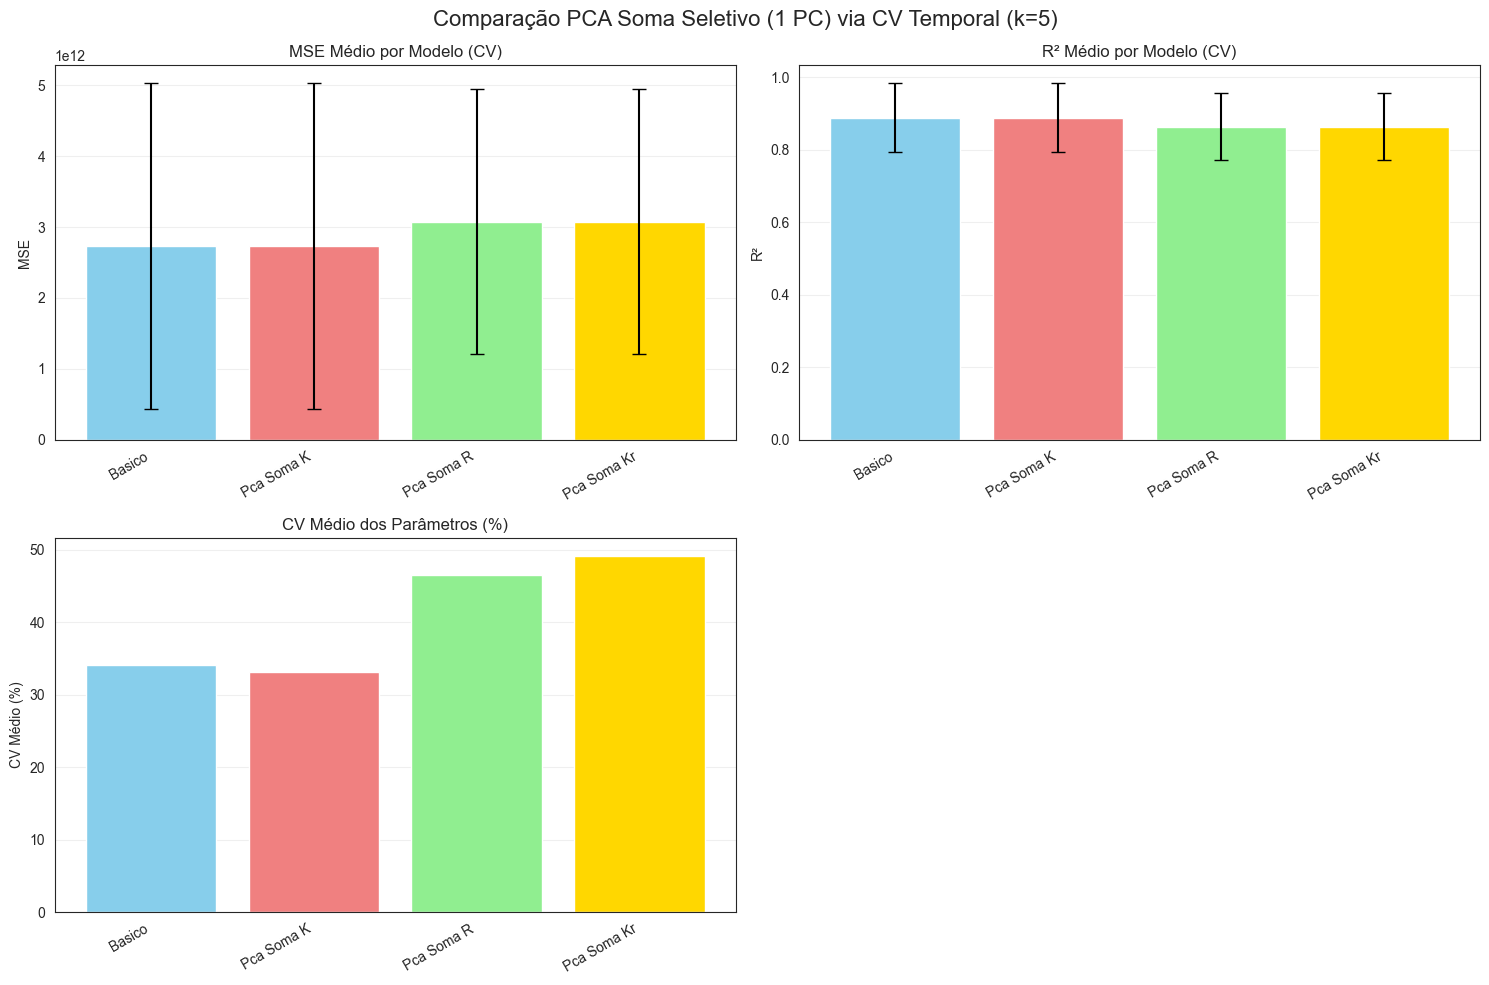

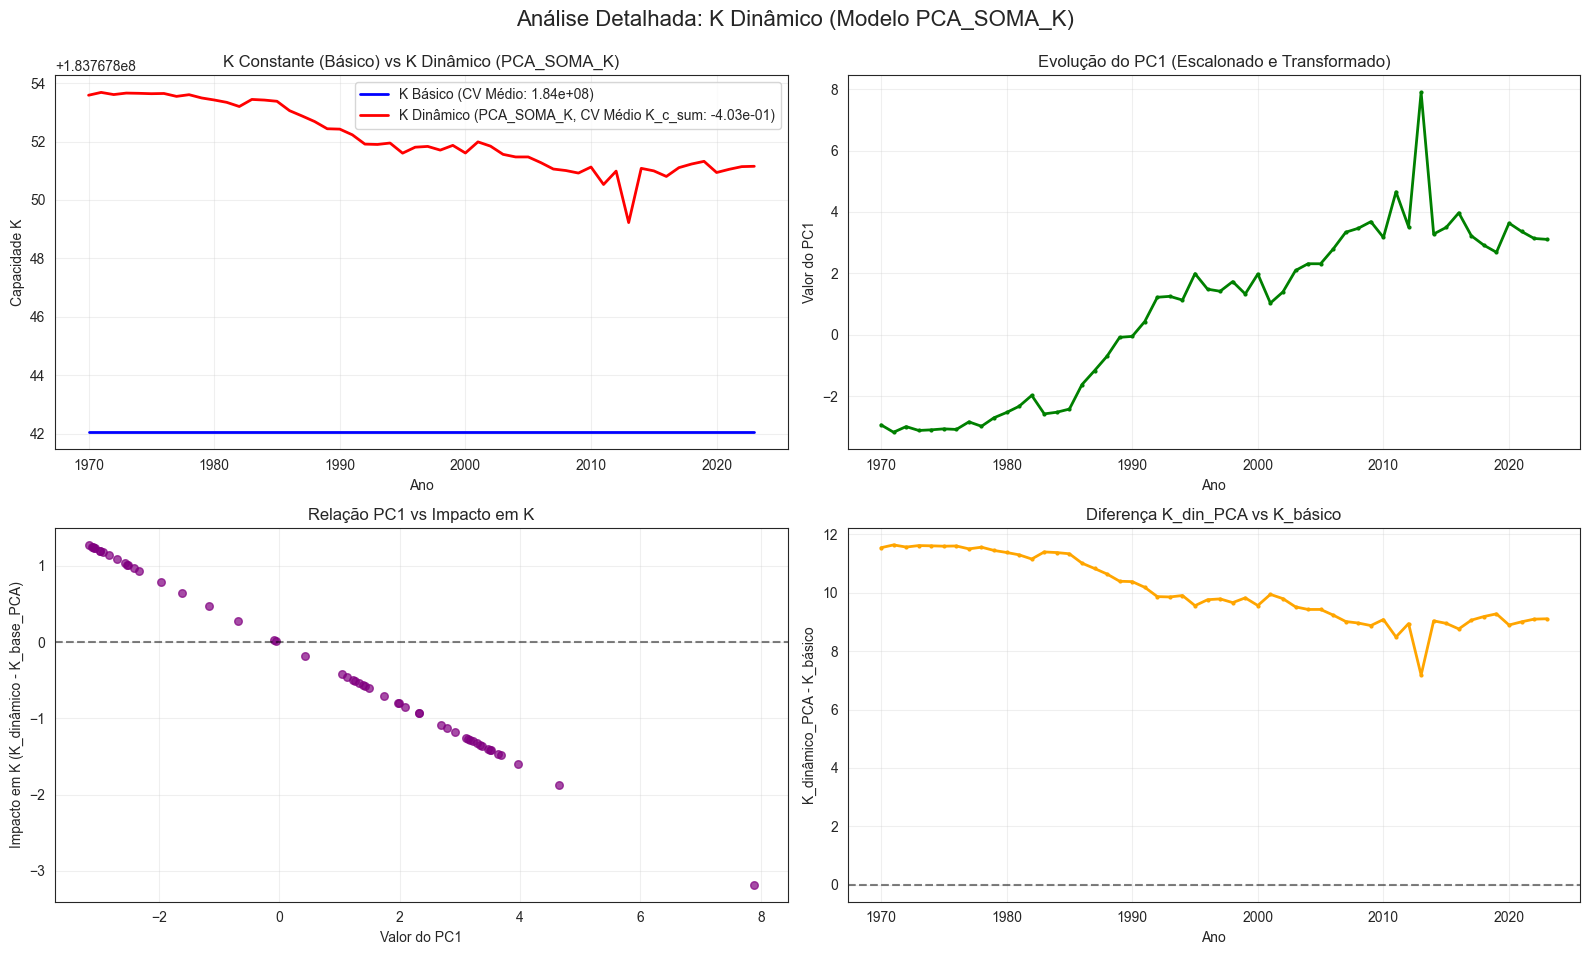

In [ ]:
resultados_exemplo = executar_modelagem_pca_soma_seletivo(new_df_brasil_wide)
if resultados_exemplo:
    analisar_pca_soma_k_detalhado(resultados_exemplo, new_df_brasil_wide)

## Regressão nos indicadores

In [87]:
# ============================
# 1. MODELO RICHARDS DINÂMICO
# ============================

def modelo_richards_logK_logR_dinamico(t_array, params_otimizacao, indicadores_K_dados, indicadores_r_dados):
    """
    Modelo Richards com K e r dinâmicos (log-lineares).
    
    Parâmetros:
    -----------
    t_array : array
        Tempos para predição
    params_otimizacao : array
        [beta_K0, beta_K1, ..., beta_r0, beta_r1, ..., v_base, t0_base]
    indicadores_K_dados : array (n_tempos, n_indicadores_K)
        Indicadores para modelar K
    indicadores_r_dados : array (n_tempos, n_indicadores_r)
        Indicadores para modelar r
    
    Retorna:
    --------
    array : Predições de população
    """
    num_ind_K = indicadores_K_dados.shape[1]
    num_ind_r = indicadores_r_dados.shape[1]
    
    # Extrair parâmetros
    betas_K = params_otimizacao[:num_ind_K + 1]  # beta_K0, beta_K1, ...
    betas_r = params_otimizacao[num_ind_K + 1:num_ind_K + 1 + num_ind_r + 1]  # beta_r0, beta_r1, ...
    v_base = params_otimizacao[-2]
    t0_base = params_otimizacao[-1]
    
    # Calcular K dinâmico: K_t = exp(beta_K0 + sum(beta_Ki * Indicador_Ki_t))
    log_K_t = betas_K[0] + np.dot(indicadores_K_dados, betas_K[1:])
    K_t = np.exp(log_K_t)
    
    # Calcular r dinâmico: r_t = exp(beta_r0 + sum(beta_ri * Indicador_ri_t))
    log_r_t = betas_r[0] + np.dot(indicadores_r_dados, betas_r[1:])
    r_t = np.clip(np.exp(log_r_t), 1e-6, 10)  # Clip para estabilidade
    
    # Fórmula de Richards: P(t) = K_t / (1 + v_base * exp(-r_t * (t - t0_base)))^(1/v_base)
    exp_term = np.exp(-r_t * (t_array - t0_base))
    denominator = (1 + v_base * exp_term) ** (1/v_base)
    
    # Evitar divisão por zero
    denominator = np.clip(denominator, 1e-10, None)
    
    return K_t / denominator

def ajustar_richards_logK_logR_dinamico(X_tempo, y_pop, indicadores_K, indicadores_r, 
                                      num_ind_K, num_ind_r, p0_inicial=None, bounds=None,
                                      regularizacao_K=0.0, regularizacao_r=0.0):
    """
    Ajusta o modelo Richards dinâmico usando otimização.
    
    Parâmetros:
    -----------
    X_tempo : array
        Tempos observados
    y_pop : array
        Populações observadas
    indicadores_K : array (n_tempos, n_indicadores_K)
        Indicadores para K
    indicadores_r : array (n_tempos, n_indicadores_r)
        Indicadores para r
    num_ind_K : int
        Número de indicadores para K
    num_ind_r : int
        Número de indicadores para r
    p0_inicial : array, opcional
        Valores iniciais dos parâmetros
    bounds : list, opcional
        Limites dos parâmetros
    regularizacao_K : float
        Força da regularização L2 para betas_K
    regularizacao_r : float
        Força da regularização L2 para betas_r
    
    Retorna:
    --------
    tuple : (params_otimos, y_pred_treino, param_errors)
    """
    n_params = (num_ind_K + 1) + (num_ind_r + 1) + 2  # betas_K + betas_r + v_base + t0_base
    
    # Valores iniciais padrão
    if p0_inicial is None:
        p0_inicial = np.zeros(n_params)
        p0_inicial[0] = np.log(np.max(y_pop))  # beta_K0 inicial
        p0_inicial[num_ind_K + 1] = np.log(0.1)  # beta_r0 inicial
        p0_inicial[-2] = 1.0  # v_base inicial
        p0_inicial[-1] = X_tempo[len(X_tempo)//2]  # t0_base inicial
    
    # Limites padrão
    if bounds is None:
        bounds = []
        # Limites para betas_K
        for i in range(num_ind_K + 1):
            bounds.append((-10, 10))
        # Limites para betas_r
        for i in range(num_ind_r + 1):
            bounds.append((-5, 5))
        # Limites para v_base e t0_base
        bounds.append((0.1, 10))  # v_base
        bounds.append((X_tempo.min(), X_tempo.max()))  # t0_base
    
    def objetivo(params):
        try:
            y_pred = modelo_richards_logK_logR_dinamico(X_tempo, params, indicadores_K, indicadores_r)
            
            # MSE
            mse = np.mean((y_pop - y_pred) ** 2)
            
            # Regularização L2 (excluindo interceptos beta_K0 e beta_r0)
            reg_K = regularizacao_K * np.sum(params[1:num_ind_K + 1] ** 2)
            reg_r = regularizacao_r * np.sum(params[num_ind_K + 2:num_ind_K + 1 + num_ind_r + 1] ** 2)
            
            return mse + reg_K + reg_r
        except:
            return 1e10
    
    # Otimização
    try:
        resultado = minimize(objetivo, p0_inicial, method='L-BFGS-B', bounds=bounds)
        
        if resultado.success:
            params_otimos = resultado.x
            y_pred_treino = modelo_richards_logK_logR_dinamico(X_tempo, params_otimos, 
                                                             indicadores_K, indicadores_r)
            param_errors = np.full(len(params_otimos), np.nan)  # Placeholder
            
            return params_otimos, y_pred_treino, param_errors
        else:
            return None, None, np.full(n_params, np.inf)
    except:
        return None, None, np.full(n_params, np.inf)

# ============================
# 2. MODELO RICHARDS BÁSICO
# ============================

def modelo_richards_basico(t_array, K, r, v, t0):
    """Modelo Richards básico com parâmetros escalares."""
    exp_term = np.exp(-r * (t_array - t0))
    denominator = (1 + v * exp_term) ** (1/v)
    return K / denominator

def ajustar_modelo_richards_basico(X_tempo, y_pop):
    """Ajusta modelo Richards básico."""
    def objetivo(params):
        K, r, v, t0 = params
        try:
            y_pred = modelo_richards_basico(X_tempo, K, r, v, t0)
            return np.mean((y_pop - y_pred) ** 2)
        except:
            return 1e10
    
    # Valores iniciais
    p0 = [np.max(y_pop), 0.1, 1.0, X_tempo[len(X_tempo)//2]]
    
    # Limites
    bounds = [
        (y_pop.max() * 0.1, y_pop.max() * 10),  # K
        (0.001, 2.0),  # r
        (0.1, 10),  # v
        (X_tempo.min(), X_tempo.max())  # t0
    ]
    
    try:
        resultado = minimize(objetivo, p0, method='L-BFGS-B', bounds=bounds)
        
        if resultado.success:
            params_otimos = resultado.x
            y_pred = modelo_richards_basico(X_tempo, *params_otimos)
            return params_otimos, y_pred, np.full(4, np.nan)
        else:
            return None, None, np.full(4, np.inf)
    except:
        return None, None, np.full(4, np.inf)

# ============================
# 3. SELEÇÃO DE INDICADORES
# ============================

def selecionar_indicadores_para_K_e_r(df_treino_fold, population_col, growth_col, 
                                     num_indicadores_K, num_indicadores_r):
    """
    Seleciona indicadores para K e r baseado em correlações.
    
    Parâmetros:
    -----------
    df_treino_fold : DataFrame
        Dados de treino do fold atual
    population_col : str
        Nome da coluna de população
    growth_col : str
        Nome da coluna de crescimento
    num_indicadores_K : int
        Número de indicadores para K
    num_indicadores_r : int
        Número de indicadores para r
    
    Retorna:
    --------
    tuple : (indicadores_K, indicadores_r)
    """
    # Colunas disponíveis (excluindo população e crescimento)
    colunas_disponiveis = [col for col in df_treino_fold.columns 
                          if col not in [population_col, growth_col]]
    
    if len(colunas_disponiveis) == 0:
        return [], []
    
    # Correlações com população (proxy para K)
    corr_pop = df_treino_fold[colunas_disponiveis].corrwith(df_treino_fold[population_col])
    corr_pop = corr_pop.abs().sort_values(ascending=False)
    
    # Correlações com crescimento (proxy para r)
    corr_growth = df_treino_fold[colunas_disponiveis].corrwith(df_treino_fold[growth_col])
    corr_growth = corr_growth.abs().sort_values(ascending=False)
    
    # Selecionar top indicadores
    indicadores_K = corr_pop.head(num_indicadores_K).index.tolist()
    indicadores_r = corr_growth.head(num_indicadores_r).index.tolist()
    
    return indicadores_K, indicadores_r

# ============================
# 4. MÉTRICAS DE AVALIAÇÃO
# ============================

def calcular_metricas(y_true, y_pred):
    """Calcula MSE, R² e MAPE."""
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE (Mean Absolute Percentage Error)
    mask = y_true != 0
    if np.any(mask):
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.inf
    
    return {'MSE': mse, 'R2': r2, 'MAPE': mape}

# ============================
# 5. PIPELINE DE VALIDAÇÃO CRUZADA
# ============================

def executar_cv_comparativa_dinamico_vs_basico(df, tempo_col, population_col, growth_col,
                                              n_splits=5, test_size=None, min_train_size=None,
                                              num_indicadores_K=2, num_indicadores_r=2,
                                              regularizacao_K=0.01, regularizacao_r=0.01,
                                              split_global=True, test_size_global=0.2):
    """
    Pipeline completa de validação cruzada comparando modelo dinâmico vs básico.
    
    Parâmetros:
    -----------
    df : DataFrame
        Dataset completo
    tempo_col : str
        Nome da coluna de tempo
    population_col : str
        Nome da coluna de população
    growth_col : str
        Nome da coluna de crescimento
    n_splits : int
        Número de splits para TimeSeriesSplit
    test_size : int/float, opcional
        Tamanho do conjunto de teste em cada fold
    min_train_size : int, opcional
        Tamanho mínimo do conjunto de treino
    num_indicadores_K : int
        Número de indicadores para K
    num_indicadores_r : int
        Número de indicadores para r
    regularizacao_K : float
        Força da regularização para K
    regularizacao_r : float
        Força da regularização para r
    split_global : bool
        Se deve fazer split treino/teste global inicial
    test_size_global : float
        Proporção do teste global
    
    Retorna:
    --------
    dict : Resultados da validação cruzada
    """
    print("=== INICIANDO VALIDAÇÃO CRUZADA COMPARATIVA ===\n")
    
    # Preparar dados
    df_trabalho = df.copy().sort_values(tempo_col).reset_index(drop=True)
    
    # Split global opcional
    if split_global:
        split_idx = int(len(df_trabalho) * (1 - test_size_global))
        df_cv = df_trabalho.iloc[:split_idx].copy()
        df_teste_global = df_trabalho.iloc[split_idx:].copy()
        print(f"Split global: {len(df_cv)} treino, {len(df_teste_global)} teste")
    else:
        df_cv = df_trabalho.copy()
        df_teste_global = None
    
    # Configurar TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, 
                          max_train_size=min_train_size)
    
    # Armazenamento de resultados
    resultados = {
        'dinamico': {'metricas': [], 'params': []},
        'basico': {'metricas': [], 'params': []},
        'fold_info': []
    }
    
    X_cv = df_cv[tempo_col].values
    y_cv = df_cv[population_col].values
    
    print(f"Executando {n_splits} folds de validação cruzada...\n")
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_cv)):
        print(f"--- FOLD {fold + 1}/{n_splits} ---")
        
        # Dados do fold
        df_treino_fold = df_cv.iloc[train_idx].copy()
        df_val_fold = df_cv.iloc[val_idx].copy()
        
        X_treino = df_treino_fold[tempo_col].values
        y_treino = df_treino_fold[population_col].values
        X_val = df_val_fold[tempo_col].values
        y_val = df_val_fold[population_col].values
        
        print(f"Treino: {len(X_treino)} amostras | Validação: {len(X_val)} amostras")
        
        # Seleção de indicadores
        indicadores_K_nomes, indicadores_r_nomes = selecionar_indicadores_para_K_e_r(
            df_treino_fold, population_col, growth_col, num_indicadores_K, num_indicadores_r
        )
        
        print(f"Indicadores K: {indicadores_K_nomes}")
        print(f"Indicadores r: {indicadores_r_nomes}")
        
        if not indicadores_K_nomes or not indicadores_r_nomes:
            print("Sem indicadores suficientes - pulando fold")
            continue
        
        # Preparar indicadores e escalar
        scaler_K = StandardScaler()
        scaler_r = StandardScaler()
        
        indicadores_K_treino = scaler_K.fit_transform(df_treino_fold[indicadores_K_nomes].values)
        indicadores_K_val = scaler_K.transform(df_val_fold[indicadores_K_nomes].values)
        
        indicadores_r_treino = scaler_r.fit_transform(df_treino_fold[indicadores_r_nomes].values)
        indicadores_r_val = scaler_r.transform(df_val_fold[indicadores_r_nomes].values)
        
        # MODELO DINÂMICO
        print("Ajustando modelo dinâmico...")
        params_din, y_pred_treino_din, errors_din = ajustar_richards_logK_logR_dinamico(
            X_treino, y_treino, indicadores_K_treino, indicadores_r_treino,
            len(indicadores_K_nomes), len(indicadores_r_nomes),
            regularizacao_K=regularizacao_K, regularizacao_r=regularizacao_r
        )
        
        if params_din is not None:
            y_pred_val_din = modelo_richards_logK_logR_dinamico(
                X_val, params_din, indicadores_K_val, indicadores_r_val
            )
            metricas_din = calcular_metricas(y_val, y_pred_val_din)
            print(f"Dinâmico - MSE: {metricas_din['MSE']:.4f}, R²: {metricas_din['R2']:.4f}")
        else:
            metricas_din = {'MSE': np.inf, 'R2': -np.inf, 'MAPE': np.inf}
            print("Modelo dinâmico falhou")
        
        # MODELO BÁSICO
        print("Ajustando modelo básico...")
        params_bas, y_pred_treino_bas, errors_bas = ajustar_modelo_richards_basico(X_treino, y_treino)
        
        if params_bas is not None:
            y_pred_val_bas = modelo_richards_basico(X_val, *params_bas)
            metricas_bas = calcular_metricas(y_val, y_pred_val_bas)
            print(f"Básico - MSE: {metricas_bas['MSE']:.4f}, R²: {metricas_bas['R2']:.4f}")
        else:
            metricas_bas = {'MSE': np.inf, 'R2': -np.inf, 'MAPE': np.inf}
            print("Modelo básico falhou")
        
        # Armazenar resultados
        resultados['dinamico']['metricas'].append(metricas_din)
        resultados['dinamico']['params'].append(params_din if params_din is not None else [])
        
        resultados['basico']['metricas'].append(metricas_bas)
        resultados['basico']['params'].append(params_bas if params_bas is not None else [])
        
        resultados['fold_info'].append({
            'fold': fold + 1,
            'train_size': len(X_treino),
            'val_size': len(X_val),
            'indicadores_K': indicadores_K_nomes,
            'indicadores_r': indicadores_r_nomes
        })
        
        print()
    
    # Calcular estatísticas finais
    print("=== RESULTADOS FINAIS ===\n")
    
    # Estatísticas por modelo
    for modelo_nome in ['dinamico', 'basico']:
        metricas = resultados[modelo_nome]['metricas']
        metricas_validas = [m for m in metricas if not np.isinf(m['MSE'])]
        
        if metricas_validas:
            mse_scores = [m['MSE'] for m in metricas_validas]
            r2_scores = [m['R2'] for m in metricas_validas]
            mape_scores = [m['MAPE'] for m in metricas_validas if not np.isinf(m['MAPE'])]
            
            print(f"MODELO {modelo_nome.upper()}:")
            print(f"  MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
            print(f"  R²:  {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
            if mape_scores:
                print(f"  MAPE: {np.mean(mape_scores):.2f}% ± {np.std(mape_scores):.2f}%")
            print()
        else:
            print(f"MODELO {modelo_nome.upper()}: Falhou em todos os folds\n")
    
    return resultados

# ============================
# 6. INTERPRETAÇÃO DE RESULTADOS
# ============================

def interpretar_resultados_dinamicos(params_dinamicos, indicadores_K_nomes, indicadores_r_nomes):
    """
    Interpreta os parâmetros do modelo dinâmico.
    
    Parâmetros:
    -----------
    params_dinamicos : array
        Parâmetros ajustados do modelo dinâmico
    indicadores_K_nomes : list
        Nomes dos indicadores para K
    indicadores_r_nomes : list
        Nomes dos indicadores para r
    """
    if params_dinamicos is None or len(params_dinamicos) == 0:
        print("Parâmetros dinâmicos não disponíveis")
        return
    
    num_ind_K = len(indicadores_K_nomes)
    num_ind_r = len(indicadores_r_nomes)
    
    # Extrair parâmetros
    betas_K = params_dinamicos[:num_ind_K + 1]
    betas_r = params_dinamicos[num_ind_K + 1:num_ind_K + 1 + num_ind_r + 1]
    v_base = params_dinamicos[-2]
    t0_base = params_dinamicos[-1]
    
    print("=== INTERPRETAÇÃO DO MODELO DINÂMICO ===\n")
    
    print("PARÂMETROS DE CAPACIDADE DE SUPORTE (K):")
    print(f"  β_K0 (intercepto): {betas_K[0]:.4f}")
    for i, nome in enumerate(indicadores_K_nomes):
        beta_val = betas_K[i + 1]
        impacto_pct = (np.exp(beta_val) - 1) * 100
        print(f"  β_K_{i+1} ({nome}): {beta_val:.4f} (impacto: {impacto_pct:+.1f}%)")
    
    print("\nPARÂMETROS DE TAXA DE CRESCIMENTO (r):")
    print(f"  β_r0 (intercepto): {betas_r[0]:.4f}")
    for i, nome in enumerate(indicadores_r_nomes):
        beta_val = betas_r[i + 1]
        impacto_pct = (np.exp(beta_val) - 1) * 100
        print(f"  β_r_{i+1} ({nome}): {beta_val:.4f} (impacto: {impacto_pct:+.1f}%)")
    
    print(f"\nPARÂMETROS ESCALARES:")
    print(f"  v_base: {v_base:.4f}")
    print(f"  t0_base: {t0_base:.4f}")

# ============================
# 7. VISUALIZAÇÃO
# ============================

def plotar_resultados_cv(resultados):
    """Plota os resultados da validação cruzada."""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Preparar dados
    metricas_din = [m for m in resultados['dinamico']['metricas'] if not np.isinf(m['MSE'])]
    metricas_bas = [m for m in resultados['basico']['metricas'] if not np.isinf(m['MSE'])]
    
    if not metricas_din or not metricas_bas:
        print("Dados insuficientes para plotar")
        return
    
    # 1. MSE Comparison
    mse_din = [m['MSE'] for m in metricas_din]
    mse_bas = [m['MSE'] for m in metricas_bas]
    
    axes[0,0].boxplot([mse_din, mse_bas], labels=['Dinâmico', 'Básico'])
    axes[0,0].set_title('Comparação MSE')
    axes[0,0].set_ylabel('MSE')
    
    # 2. R² Comparison
    r2_din = [m['R2'] for m in metricas_din]
    r2_bas = [m['R2'] for m in metricas_bas]
    
    axes[0,1].boxplot([r2_din, r2_bas], labels=['Dinâmico', 'Básico'])
    axes[0,1].set_title('Comparação R²')
    axes[0,1].set_ylabel('R²')
    
    # 3. MAPE Comparison
    mape_din = [m['MAPE'] for m in metricas_din if not np.isinf(m['MAPE'])]
    mape_bas = [m['MAPE'] for m in metricas_bas if not np.isinf(m['MAPE'])]
    
    if mape_din and mape_bas:
        axes[1,0].boxplot([mape_din, mape_bas], labels=['Dinâmico', 'Básico'])
        axes[1,0].set_title('Comparação MAPE (%)')
        axes[1,0].set_ylabel('MAPE (%)')
    
    # 4. Métricas por Fold
    folds = range(1, len(mse_din) + 1)
    axes[1,1].plot(folds, mse_din, 'o-', label='Dinâmico', alpha=0.7)
    axes[1,1].plot(folds, mse_bas, 's-', label='Básico', alpha=0.7)
    axes[1,1].set_title('MSE por Fold')
    axes[1,1].set_xlabel('Fold')
    axes[1,1].set_ylabel('MSE')
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.show()


# ============================
# 9. ANÁLISE DE ESTABILIDADE
# ============================

def analisar_estabilidade_parametros(resultados):
    """
    Analisa a estabilidade dos parâmetros através dos folds.
    
    Parâmetros:
    -----------
    resultados : dict
        Resultados da validação cruzada
    
    Retorna:
    --------
    dict : Estatísticas de estabilidade
    """
    print("=== ANÁLISE DE ESTABILIDADE DOS PARÂMETROS ===\n")
    
    estabilidade = {
        'dinamico': {'cvs': [], 'means': [], 'stds': []},
        'basico': {'cvs': [], 'means': [], 'stds': []}
    }
    
    # Análise modelo dinâmico
    params_dinamicos_validos = [p for p in resultados['dinamico']['params'] 
                               if p is not None and len(p) > 0]
    
    if params_dinamicos_validos:
        params_dinamicos_array = np.array(params_dinamicos_validos)
        n_params_din = params_dinamicos_array.shape[1]
        
        print("MODELO DINÂMICO:")
        print("Parâmetro | Média ± Desvio | CV (%)")
        print("-" * 40)
        
        for i in range(n_params_din):
            valores = params_dinamicos_array[:, i]
            media = np.mean(valores)
            desvio = np.std(valores)
            cv = (desvio / abs(media)) * 100 if media != 0 else np.inf
            
            estabilidade['dinamico']['means'].append(media)
            estabilidade['dinamico']['stds'].append(desvio)
            estabilidade['dinamico']['cvs'].append(cv)
            
            print(f"Param_{i+1:2d} | {media:8.4f} ± {desvio:6.4f} | {cv:6.1f}")
        
        cv_medio_din = np.mean([cv for cv in estabilidade['dinamico']['cvs'] if not np.isinf(cv)])
        print(f"\nCV médio: {cv_medio_din:.1f}%")
    else:
        print("MODELO DINÂMICO: Sem parâmetros válidos")
    
    print()
    
    # Análise modelo básico
    params_basicos_validos = [p for p in resultados['basico']['params'] 
                             if p is not None and len(p) > 0]
    
    if params_basicos_validos:
        params_basicos_array = np.array(params_basicos_validos)
        param_names = ['K', 'r', 'v', 't0']
        
        print("MODELO BÁSICO:")
        print("Parâmetro | Média ± Desvio | CV (%)")
        print("-" * 40)
        
        for i in range(4):
            valores = params_basicos_array[:, i]
            media = np.mean(valores)
            desvio = np.std(valores)
            cv = (desvio / abs(media)) * 100 if media != 0 else np.inf
            
            estabilidade['basico']['means'].append(media)
            estabilidade['basico']['stds'].append(desvio)
            estabilidade['basico']['cvs'].append(cv)
            
            print(f"{param_names[i]:>8s} | {media:8.4f} ± {desvio:6.4f} | {cv:6.1f}")
        
        cv_medio_bas = np.mean([cv for cv in estabilidade['basico']['cvs'] if not np.isinf(cv)])
        print(f"\nCV médio: {cv_medio_bas:.1f}%")
    else:
        print("MODELO BÁSICO: Sem parâmetros válidos")
    
    return estabilidade

# ============================
# 10. RELATÓRIO COMPLETO
# ============================

def gerar_relatorio_completo(resultados):
    """
    Gera um relatório completo dos resultados da validação cruzada.
    
    Parâmetros:
    -----------
    resultados : dict
        Resultados da validação cruzada
    """
    print("=" * 60)
    print("           RELATÓRIO COMPLETO DE VALIDAÇÃO CRUZADA")
    print("=" * 60)
    print()
    
    # Informações gerais
    n_folds = len(resultados['fold_info'])
    print(f"CONFIGURAÇÃO:")
    print(f"- Número de folds: {n_folds}")
    print(f"- Modelos comparados: Richards Dinâmico vs Richards Básico")
    print()
    
    # Detalhes dos folds
    print("DETALHES DOS FOLDS:")
    for info in resultados['fold_info']:
        print(f"  Fold {info['fold']}: {info['train_size']} treino, {info['val_size']} validação")
        print(f"    Indicadores K: {info['indicadores_K']}")
        print(f"    Indicadores r: {info['indicadores_r']}")
    print()
    
    # Métricas de performance
    print("PERFORMANCE DOS MODELOS:")
    
    for modelo_nome in ['dinamico', 'basico']:
        metricas = resultados[modelo_nome]['metricas']
        metricas_validas = [m for m in metricas if not np.isinf(m['MSE'])]
        
        print(f"\n{modelo_nome.upper()}:")
        
        if metricas_validas:
            mse_scores = [m['MSE'] for m in metricas_validas]
            r2_scores = [m['R2'] for m in metricas_validas]
            mape_scores = [m['MAPE'] for m in metricas_validas if not np.isinf(m['MAPE'])]
            
            print(f"  Folds válidos: {len(metricas_validas)}/{len(metricas)}")
            print(f"  MSE: {np.mean(mse_scores):.6f} ± {np.std(mse_scores):.6f}")
            print(f"  R²:  {np.mean(r2_scores):.6f} ± {np.std(r2_scores):.6f}")
            
            if mape_scores:
                print(f"  MAPE: {np.mean(mape_scores):.2f}% ± {np.std(mape_scores):.2f}%")
            
            # Melhor e pior fold
            melhor_fold = np.argmin(mse_scores)
            pior_fold = np.argmax(mse_scores)
            print(f"  Melhor fold: {melhor_fold + 1} (MSE: {mse_scores[melhor_fold]:.6f})")
            print(f"  Pior fold: {pior_fold + 1} (MSE: {mse_scores[pior_fold]:.6f})")
        else:
            print("  FALHOU EM TODOS OS FOLDS")
    
    print()
    
    # Comparação direta
    metricas_din_validas = [m for m in resultados['dinamico']['metricas'] if not np.isinf(m['MSE'])]
    metricas_bas_validas = [m for m in resultados['basico']['metricas'] if not np.isinf(m['MSE'])]
    
    if metricas_din_validas and metricas_bas_validas:
        mse_din = np.mean([m['MSE'] for m in metricas_din_validas])
        mse_bas = np.mean([m['MSE'] for m in metricas_bas_validas])
        r2_din = np.mean([m['R2'] for m in metricas_din_validas])
        r2_bas = np.mean([m['R2'] for m in metricas_bas_validas])
        
        print("COMPARAÇÃO DIRETA:")
        print(f"  Melhoria MSE: {((mse_bas - mse_din) / mse_bas * 100):+.2f}%")
        print(f"  Melhoria R²: {((r2_din - r2_bas) / abs(r2_bas) * 100):+.2f}%")
        
        if mse_din < mse_bas:
            print("  → MODELO DINÂMICO É SUPERIOR")
        else:
            print("  → MODELO BÁSICO É SUPERIOR")
    
    print()
    
    # Análise de estabilidade
    estabilidade = analisar_estabilidade_parametros(resultados)
    
    print()
    print("=" * 60)

# ============================
# 11. FUNÇÃO PRINCIPAL INTEGRADA
# ============================

def executar_analise_completa(df, tempo_col, population_col, growth_col, **kwargs):
    """
    Executa análise completa: CV + Análise + Relatório + Visualização.
    
    Parâmetros:
    -----------
    df : DataFrame
        Dataset para análise
    tempo_col : str
        Nome da coluna de tempo
    population_col : str
        Nome da coluna de população
    growth_col : str
        Nome da coluna de crescimento
    **kwargs : argumentos adicionais para executar_cv_comparativa_dinamico_vs_basico
    
    Retorna:
    --------
    dict : Resultados completos
    """
    # Executar validação cruzada
    resultados = executar_cv_comparativa_dinamico_vs_basico(
        df, tempo_col, population_col, growth_col, **kwargs
    )
    
    print("\n" + "="*60)
    
    # Gerar relatório completo
    gerar_relatorio_completo(resultados)
    
    # Plotar resultados
    print("\nGerando visualizações...")
    plotar_resultados_cv(resultados)
    
    return resultados



In [85]:
# Exemplo básico
resultados = executar_cv_comparativa_dinamico_vs_basico(
    df=new_df_brasil_wide,
    tempo_col='tempo',
    population_col='populacao', 
    growth_col='crescimento',
    n_splits=5,
    num_indicadores_K=2,
    num_indicadores_r=2,
    regularizacao_K=0.01,
    regularizacao_r=0.01
)



=== INICIANDO VALIDAÇÃO CRUZADA COMPARATIVA ===



KeyError: 'tempo'